# 04 - Model Analysis

Notebook này dùng cho **Modeling, Evaluation, Calibration, Credit Scoring và Decision Analysis** của project Credit Risk Scoring & Loan Decisioning System.

Nguyên tắc:
- Dùng 80% Development Set và 20% Locked Test Set.
- Dùng 5-fold Stratified CV trên Development Set.
- Locked Test chỉ được mở sau khi đã chốt model, calibration, threshold, score/grade và decision policy.
- Feature decisions lấy từ `src/features/build_features.py`.
- Feature Engineering phải nằm trước Preprocessing và nằm trong pipeline.
- Calibration phải chạy trước Threshold Analysis.
- Core models: Dummy, Logistic Regression, LightGBM, CatBoost. RandomForest/HistGradientBoosting chỉ là optional.
- Metrics chính: ROC-AUC, PR-AUC, KS, Gini, Brier Score.

## Section 0 - Setup, Load Data và Feature Decisions

**Mục tiêu:** chuẩn bị môi trường modeling, load raw dataset và lấy feature decisions từ source chung.

**Output mong muốn:**
- `df_model`, `X_raw`, `y`.
- `primary_feature_cols`, `extended_feature_cols`, `extended_only_cols`, `audit_only_cols`, `redundant_excluded_cols`.
- `feature_decision_note`.

In [1]:
# 0.1 - Thiết lập môi trường notebook

import importlib
import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ============================================================
# 1. Optional model imports
# ============================================================

try:
    from lightgbm import LGBMClassifier

    LIGHTGBM_AVAILABLE = True
except ImportError:
    LGBMClassifier = None
    LIGHTGBM_AVAILABLE = False

try:
    from catboost import CatBoostClassifier

    CATBOOST_AVAILABLE = True
except ImportError:
    CatBoostClassifier = None
    CATBOOST_AVAILABLE = False

# ============================================================
# 2. Cấu hình hiển thị
# ============================================================

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 1200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="LightGBM binary classifier with TreeExplainer shap values output has changed.*")
warnings.filterwarnings("ignore", message="The NumPy global RNG was seeded.*")

# ============================================================
# 3. Hằng số chính theo project plan
# ============================================================

TARGET_COL = "loan_status"
ID_COL = "client_ID"
DATA_SHEET_NAME = "Credit Risk Data"
DICTIONARY_SHEET_NAME = "Data Dictionary"

RANDOM_STATE = 42
TEST_SIZE = 0.20
DEVELOPMENT_SIZE = 1 - TEST_SIZE
N_SPLITS = 5

# Metrics chính của project:
# - ROC-AUC: ranking quality.
# - PR-AUC: useful under class imbalance.
# - KS: credit-risk separation metric.
# - Gini: 2 * ROC_AUC - 1.
# - Brier: probability/calibration quality.
CV_SCORING = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "brier": "neg_brier_score",
}

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ============================================================
# 4. Helper functions dùng lại ở các section modeling
# ============================================================


def ks_statistic(y_true, y_score) -> float:
    """Compute KS = max(TPR - FPR), a common credit-risk separation metric."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(tpr - fpr))


def gini_from_auc(roc_auc: float) -> float:
    """Compute Gini from ROC-AUC."""
    return float(2 * roc_auc - 1)


def positive_class_proba(estimator, X):
    """Return P(default=1) from classifiers that expose predict_proba."""
    if not hasattr(estimator, "predict_proba"):
        raise AttributeError("Estimator does not expose predict_proba().")
    proba = estimator.predict_proba(X)
    return proba[:, 1]


def make_one_hot_encoder():
    """Create OneHotEncoder compatible with newer and older sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_metric_row(model_name, feature_set, y_true, y_score):
    """Build a standard metric row for model comparison."""
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    brier = brier_score_loss(y_true, y_score)
    return {
        "model_name": model_name,
        "feature_set": feature_set,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "ks": ks_statistic(y_true, y_score),
        "gini": gini_from_auc(roc_auc),
        "brier": brier,
    }


print("Environment ready for Model Analysis")
print(f"TARGET_COL       : {TARGET_COL}")
print(f"ID_COL           : {ID_COL}")
print(f"RANDOM_STATE     : {RANDOM_STATE}")
print(f"DEVELOPMENT_SIZE : {DEVELOPMENT_SIZE:.0%}")
print(f"LOCKED_TEST_SIZE : {TEST_SIZE:.0%}")
print(f"N_SPLITS         : {N_SPLITS}")
print(f"LightGBM         : {'available' if LIGHTGBM_AVAILABLE else 'not installed'}")
print(f"CatBoost         : {'available' if CATBOOST_AVAILABLE else 'not installed'}")

Environment ready for Model Analysis
TARGET_COL       : loan_status
ID_COL           : client_ID
RANDOM_STATE     : 42
DEVELOPMENT_SIZE : 80%
LOCKED_TEST_SIZE : 20%
N_SPLITS         : 5
LightGBM         : available
CatBoost         : available


In [2]:
# 0.2 - Load data và feature decisions

# ============================================================
# 1. Xác định PROJECT_ROOT
# ============================================================

CURRENT_CWD = Path.cwd().resolve()


def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc project từ CWD hiện tại hoặc các thư mục cha."""
    for candidate in (start, *start.parents):
        required_folders = ("data", "notebooks", "src")
        if all((candidate / folder).exists() for folder in required_folders):
            return candidate

    raise FileNotFoundError(
        "Không xác định được PROJECT_ROOT. "
        "Hãy chạy notebook từ trong repo CREDIT_RISK_PROJECT hoặc một thư mục con của repo."
    )


PROJECT_ROOT = find_project_root(CURRENT_CWD)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Credit Risk Dataset.xlsx"
REPORT_PATH = PROJECT_ROOT / "reports"
MODEL_PATH = PROJECT_ROOT / "models"
FIGURE_PATH = PROJECT_ROOT / "notebooks" / "figures"

REPORT_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

print(f"CWD           : {CURRENT_CWD}")
print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"RAW_DATA_PATH : {RAW_DATA_PATH}")
print(f"File tồn tại  : {RAW_DATA_PATH.exists()}")

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy dataset tại: {RAW_DATA_PATH}")

# ============================================================
# 2. Import feature source of truth
# ============================================================

import src.features.build_features as feature_builder_module

feature_builder_module = importlib.reload(feature_builder_module)

from src.features.build_features import (
    add_credit_risk_features,
    add_credit_risk_flag_features,
    add_credit_risk_interactions,
    add_credit_risk_ratio_features,
    build_feature_decisions,
)

# ============================================================
# 3. Load raw dataset
# ============================================================

excel_file = pd.ExcelFile(RAW_DATA_PATH, engine="openpyxl")

if DATA_SHEET_NAME not in excel_file.sheet_names:
    raise ValueError(
        f"Không tìm thấy sheet '{DATA_SHEET_NAME}'. "
        f"Các sheet hiện có: {excel_file.sheet_names}"
    )

df_model = pd.read_excel(
    RAW_DATA_PATH,
    sheet_name=DATA_SHEET_NAME,
    engine="openpyxl",
)

if DICTIONARY_SHEET_NAME in excel_file.sheet_names:
    data_dictionary_model = pd.read_excel(
        RAW_DATA_PATH,
        sheet_name=DICTIONARY_SHEET_NAME,
        engine="openpyxl",
    )
else:
    data_dictionary_model = pd.DataFrame()

# ============================================================
# 4. Basic modeling guards
# ============================================================

required_cols = [TARGET_COL, ID_COL]
missing_required_cols = [
    col for col in required_cols
    if col not in df_model.columns
]

if missing_required_cols:
    raise KeyError("Dataset thiếu cột bắt buộc: " + ", ".join(missing_required_cols))

duplicate_column_count = int(df_model.columns.duplicated().sum())
if duplicate_column_count > 0:
    raise ValueError(f"Dataset có {duplicate_column_count} duplicate column names.")

target_missing_count = int(df_model[TARGET_COL].isna().sum())
if target_missing_count > 0:
    raise ValueError(
        f"Target {TARGET_COL} có {target_missing_count:,} missing rows. "
        "Cần xử lý trước modeling."
    )

observed_target_values = set(df_model[TARGET_COL].dropna().unique().tolist())
unexpected_target_values = sorted(observed_target_values - {0, 1})
if unexpected_target_values:
    raise ValueError(f"Target có giá trị ngoài 0/1: {unexpected_target_values}")

id_duplicate_count = int(df_model[ID_COL].duplicated().sum())
id_missing_count = int(df_model[ID_COL].isna().sum())

# ============================================================
# 5. Load feature decisions từ src/features/build_features.py
# ============================================================

feature_decisions = build_feature_decisions(
    columns=df_model.columns,
    target_col=TARGET_COL,
    id_col=ID_COL,
)

primary_feature_cols = feature_decisions.primary_feature_cols
extended_feature_cols = feature_decisions.extended_feature_cols
extended_only_cols = feature_decisions.extended_only_cols
audit_only_cols = feature_decisions.audit_only_cols
redundant_excluded_cols = feature_decisions.redundant_excluded_cols
primary_excluded_cols = feature_decisions.primary_excluded_cols
feature_decision_note = feature_decisions.feature_decision_note

feature_set_name = "primary"
X_raw = df_model[primary_feature_cols].copy()
X_primary_raw = X_raw
X_extended_raw = df_model[extended_feature_cols].copy()
y = df_model[TARGET_COL].astype(int).copy()

# ============================================================
# 6. Feature-set guard rails
# ============================================================

for forbidden_col in [TARGET_COL, ID_COL]:
    if forbidden_col in X_raw.columns:
        raise AssertionError(f"{forbidden_col} không được nằm trong X_raw.")

primary_forbidden_overlap = sorted(
    set(primary_feature_cols)
    & (
        set(extended_only_cols)
        | set(audit_only_cols)
        | set(redundant_excluded_cols)
    )
)

if primary_forbidden_overlap:
    raise AssertionError(
        "Primary feature set chứa cột không được phép: "
        + ", ".join(primary_forbidden_overlap)
    )

extended_expected_cols = primary_feature_cols + [
    col for col in extended_only_cols
    if col not in primary_feature_cols
]

if extended_feature_cols != extended_expected_cols:
    raise AssertionError(
        "Extended feature set phải bằng Primary + leakage candidates theo đúng thứ tự."
    )

extended_audit_overlap = sorted(set(extended_feature_cols) & set(audit_only_cols))
if extended_audit_overlap:
    raise AssertionError(
        "Extended không được chứa audit-only variables: "
        + ", ".join(extended_audit_overlap)
    )

if set(primary_feature_cols) - set(extended_feature_cols):
    raise AssertionError("Primary phải là subset của Extended.")

# ============================================================
# 7. Summaries cho các section sau
# ============================================================

numeric_raw_cols = (
    X_raw
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_raw_cols = [
    col for col in X_raw.columns
    if col not in numeric_raw_cols
]

missing_modeling_overview = (
    df_model[primary_feature_cols + extended_only_cols]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_modeling_overview["missing_rate"] = (
    missing_modeling_overview["missing_count"]
    / len(df_model)
)

missing_modeling_overview = (
    missing_modeling_overview
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
)

modeling_input_summary = pd.DataFrame([
    {"item": "rows", "value": len(df_model)},
    {"item": "raw_columns", "value": df_model.shape[1]},
    {"item": "feature_set_name", "value": feature_set_name},
    {"item": "primary_features", "value": len(primary_feature_cols)},
    {"item": "extended_features", "value": len(extended_feature_cols)},
    {"item": "extended_only_features", "value": len(extended_only_cols)},
    {"item": "audit_only_features", "value": len(audit_only_cols)},
    {"item": "redundant_excluded_features", "value": len(redundant_excluded_cols)},
    {"item": "numeric_primary_features", "value": len(numeric_raw_cols)},
    {"item": "categorical_primary_features", "value": len(categorical_raw_cols)},
    {"item": "target_default_rate", "value": float(y.mean())},
    {"item": "target_missing_count", "value": target_missing_count},
    {"item": "id_missing_count", "value": id_missing_count},
    {"item": "id_duplicate_count", "value": id_duplicate_count},
])

# ============================================================
# 8. Display
# ============================================================

print("\n" + "=" * 90)
print("MODELING DATA LOADED")
print("=" * 90)
print(f"df_model shape      : {df_model.shape}")
print(f"X_primary_raw shape : {X_primary_raw.shape}")
print(f"X_extended_raw shape: {X_extended_raw.shape}")
print(f"Default rate        : {y.mean():.2%}")

print("\n--- Modeling input summary ---")
display(modeling_input_summary)

print("\n--- Primary feature columns ---")
print(primary_feature_cols)

print("\n--- Extended-only leakage ablation columns ---")
print(extended_only_cols)

print("\n--- Audit-only columns ---")
print(audit_only_cols)

print("\n--- Redundant excluded columns ---")
print(redundant_excluded_cols)

print("\n--- Primary excluded columns ---")
display(primary_excluded_cols)

print("\n--- Missing overview for modeling feature candidates ---")
if missing_modeling_overview.empty:
    print("Không có missing values trong primary/extended modeling candidates.")
else:
    display(missing_modeling_overview.style.format({"missing_rate": "{:.2%}"}))

print("\nFeature decision note:")
print(feature_decision_note)


CWD           : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT
PROJECT_ROOT  : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT
RAW_DATA_PATH : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\data\raw\Credit Risk Dataset.xlsx
File tồn tại  : True



MODELING DATA LOADED
df_model shape      : (32581, 29)
X_primary_raw shape : (32581, 18)
X_extended_raw shape: (32581, 20)
Default rate        : 21.82%

--- Modeling input summary ---


,item,value
0,rows,32581
1,raw_columns,29
2,feature_set_name,primary
3,primary_features,18
4,extended_features,20
5,extended_only_features,2
6,audit_only_features,6
7,redundant_excluded_features,1
8,numeric_primary_features,12
9,categorical_primary_features,6



--- Primary feature columns ---
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_amnt', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'marital_status', 'education_level', 'employment_type', 'loan_term_months', 'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio', 'past_delinquencies']

--- Extended-only leakage ablation columns ---
['loan_grade', 'loan_int_rate']

--- Audit-only columns ---
['gender', 'country', 'state', 'city', 'city_latitude', 'city_longitude']

--- Redundant excluded columns ---
['loan_percent_income']

--- Primary excluded columns ---


,column,exclude_reason
0,loan_status,"Target label, never used as input."
1,client_ID,"Identifier, excluded to avoid memorization."
2,loan_grade,Potential post-underwriting leakage candidate;...
3,loan_int_rate,Potential post-underwriting leakage candidate;...
4,gender,Sensitive/geographic proxy; reserved for fairn...
5,country,Sensitive/geographic proxy; reserved for fairn...
6,state,Sensitive/geographic proxy; reserved for fairn...
7,city,Sensitive/geographic proxy; reserved for fairn...
8,city_latitude,Sensitive/geographic proxy; reserved for fairn...
9,city_longitude,Sensitive/geographic proxy; reserved for fairn...



--- Missing overview for modeling feature candidates ---


,missing_count,missing_rate
loan_int_rate,3116,9.56%
person_emp_length,895,2.75%



Feature decision note:
Feature decisions come from src/features/build_features.py. Primary excludes target, ID, potential leakage candidates, sensitive/geographic proxy variables, and redundant LTI aliases. Extended equals Primary plus leakage candidates only for ablation. Audit-only variables are kept outside modeling feature sets.


## Section 1 - Data Split

Plan chính: tạo **80% Development Set** và **20% Locked Test Set** bằng stratified split. Development Set dùng cho feature thử nghiệm, preprocessing, CV, tuning, calibration và threshold. Locked Test chỉ dùng sau khi policy đã freeze.

In [3]:
# 1.1 - 80/20 Development / Locked Test split

# ============================================================
# 1. Kiểm tra input trước khi split
# ============================================================

if len(X_raw) != len(y):
    raise ValueError("X_raw và y không cùng số dòng.")

if not X_raw.index.equals(y.index):
    raise ValueError("Index của X_raw và y không khớp.")

if y.isna().any():
    raise ValueError("Target y còn missing trước khi split.")

if set(y.unique()) - {0, 1}:
    raise ValueError("Target y phải chỉ gồm 0 và 1.")

# ============================================================
# 2. Stratified split: 80% Development / 20% Locked Test
# ============================================================

X_dev_raw, X_test_raw, y_dev, y_test = train_test_split(
    X_raw,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
    shuffle=True,
)

# Giữ index gốc để nối đúng Extended Set / Audit-only variables về sau
development_index = X_dev_raw.index.copy()
locked_test_index = X_test_raw.index.copy()

# Alias để nhấn mạnh đây là Locked Test
X_locked_test_raw = X_test_raw
y_locked_test = y_test

# ============================================================
# 3. Tạo cùng split cho Extended Set và Audit-only variables
# ============================================================

X_dev_extended_raw = X_extended_raw.loc[development_index].copy()
X_test_extended_raw = X_extended_raw.loc[locked_test_index].copy()

if audit_only_cols:
    audit_dev_raw = df_model.loc[
        development_index,
        audit_only_cols
    ].copy()

    audit_test_raw = df_model.loc[
        locked_test_index,
        audit_only_cols
    ].copy()
else:
    audit_dev_raw = pd.DataFrame(
        index=development_index
    )

    audit_test_raw = pd.DataFrame(
        index=locked_test_index
    )

# ============================================================
# 4. Tạo 5-fold Stratified Cross Validation trên Development
# ============================================================

cv_strategy = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# ============================================================
# 5. Guard rails - kiểm tra split không bị lỗi / overlap
# ============================================================

if not X_dev_raw.index.equals(y_dev.index):
    raise AssertionError(
        "Index X_dev_raw và y_dev không khớp."
    )

if not X_test_raw.index.equals(y_test.index):
    raise AssertionError(
        "Index X_test_raw và y_test không khớp."
    )

index_overlap = development_index.intersection(
    locked_test_index
)

if len(index_overlap) > 0:
    raise AssertionError(
        f"Development và Locked Test bị overlap "
        f"{len(index_overlap)} dòng."
    )

if (
    len(development_index)
    + len(locked_test_index)
    != len(df_model)
):
    raise AssertionError(
        "Tổng số dòng sau split không bằng dataset ban đầu."
    )

if set(y_dev.unique()) != {0, 1}:
    raise AssertionError(
        "Development Set không còn đủ hai lớp target 0/1."
    )

if set(y_test.unique()) != {0, 1}:
    raise AssertionError(
        "Locked Test Set không còn đủ hai lớp target 0/1."
    )

# ============================================================
# 6. Split summary
# ============================================================

def build_split_row(split_name, y_split):
    rows = len(y_split)
    default_count = int(y_split.sum())
    non_default_count = int(
        rows - default_count
    )

    return {
        "split": split_name,
        "rows": rows,
        "row_share": rows / len(y),
        "non_default_count": non_default_count,
        "default_count": default_count,
        "default_rate": float(
            y_split.mean()
        ),
    }


split_summary = pd.DataFrame([
    build_split_row(
        "Full Dataset",
        y
    ),
    build_split_row(
        "Development Set",
        y_dev
    ),
    build_split_row(
        "Locked Test Set",
        y_test
    ),
])

# ============================================================
# 7. Preview distribution của 5 CV folds
# ============================================================

cv_fold_records = []

for fold, (train_idx, valid_idx) in enumerate(
    cv_strategy.split(
        X_dev_raw,
        y_dev
    ),
    start=1,
):
    y_fold_train = y_dev.iloc[
        train_idx
    ]

    y_fold_valid = y_dev.iloc[
        valid_idx
    ]

    cv_fold_records.append({
        "fold": fold,
        "train_rows": len(
            train_idx
        ),
        "validation_rows": len(
            valid_idx
        ),
        "train_default_rate": float(
            y_fold_train.mean()
        ),
        "validation_default_rate": float(
            y_fold_valid.mean()
        ),
    })

cv_fold_summary = pd.DataFrame(
    cv_fold_records
)

# ============================================================
# 8. Notes
# ============================================================

split_note = (
    "Dataset được chia bằng Stratified Split "
    "(chia có giữ tỷ lệ lớp): "
    f"{DEVELOPMENT_SIZE:.0%} Development Set và "
    f"{TEST_SIZE:.0%} Locked Test Set. "
    f"Development Set dùng {N_SPLITS}-fold "
    "Stratified Cross Validation "
    "(kiểm định chéo giữ tỷ lệ Default/Non-default). "
    "Chưa fit Imputer, Encoder, Scaler hoặc "
    "Feature Transformer trước split. "
    "Locked Test chỉ được dùng sau khi model, "
    "calibration, threshold và decision policy đã freeze."
)

# ============================================================
# 9. Display
# ============================================================

print("=" * 90)
print(
    "DATA SPLIT - DEVELOPMENT / LOCKED TEST"
)
print("=" * 90)

display(
    split_summary.style.format({
        "row_share": "{:.2%}",
        "default_rate": "{:.2%}",
    })
)

print(
    "\n--- 5-fold Stratified CV preview ---"
)

display(
    cv_fold_summary.style.format({
        "train_default_rate": "{:.2%}",
        "validation_default_rate": "{:.2%}",
    })
)

print(
    "\nDevelopment shape :",
    X_dev_raw.shape
)

print(
    "Locked Test shape :",
    X_test_raw.shape
)

print(
    "Index overlap     :",
    len(index_overlap)
)

print(
    "\nSplit note:"
)

print(split_note)

DATA SPLIT - DEVELOPMENT / LOCKED TEST


,split,rows,row_share,non_default_count,default_count,default_rate
0,Full Dataset,32581,100.00%,25473,7108,21.82%
1,Development Set,26064,80.00%,20378,5686,21.82%
2,Locked Test Set,6517,20.00%,5095,1422,21.82%



--- 5-fold Stratified CV preview ---


,fold,train_rows,validation_rows,train_default_rate,validation_default_rate
0,1,20851,5213,21.82%,21.81%
1,2,20851,5213,21.82%,21.81%
2,3,20851,5213,21.82%,21.81%
3,4,20851,5213,21.81%,21.83%
4,5,20852,5212,21.82%,21.82%



Development shape : (26064, 18)
Locked Test shape : (6517, 18)
Index overlap     : 0

Split note:
Dataset được chia bằng Stratified Split (chia có giữ tỷ lệ lớp): 80% Development Set và 20% Locked Test Set. Development Set dùng 5-fold Stratified Cross Validation (kiểm định chéo giữ tỷ lệ Default/Non-default). Chưa fit Imputer, Encoder, Scaler hoặc Feature Transformer trước split. Locked Test chỉ được dùng sau khi model, calibration, threshold và decision policy đã freeze.


## Section 2 - Feature Engineering và Preprocessing Pipelines

Luồng đúng: **Raw Primary Features → Feature Builder → Preprocessing → Model**. Feature engineering phải nằm trong pipeline để tránh lệch logic giữa train, CV, test và production.

In [4]:
# 2.1 - Feature Builder


# ============================================================
# 1. Business Rule Cleaner
# ============================================================

class BusinessRuleCleaner(BaseEstimator, TransformerMixin):
    """
    Stateless business-rule cleaner used inside every modeling pipeline.

    It does not learn statistics. Impossible/implausible values are set to NaN,
    then fold-specific imputers handle them inside the downstream preprocessor.
    """

    def __init__(
        self,
        min_age=20,
        max_age=100,
        minimum_working_age=14,
    ):
        self.min_age = min_age
        self.max_age = max_age
        self.minimum_working_age = minimum_working_age

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("BusinessRuleCleaner yêu cầu input là pandas DataFrame.")
        self.input_features_ = X.columns.tolist()
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("BusinessRuleCleaner yêu cầu input là pandas DataFrame.")

        if not hasattr(self, "input_features_"):
            raise RuntimeError("BusinessRuleCleaner chưa được fit.")

        missing_cols = [
            col
            for col in self.input_features_
            if col not in X.columns
        ]

        if missing_cols:
            raise KeyError(
                "BusinessRuleCleaner thiếu input columns: "
                + ", ".join(missing_cols)
            )

        X_out = X[self.input_features_].copy()

        if "person_age" in X_out.columns:
            age = pd.to_numeric(
                X_out["person_age"],
                errors="coerce",
            )
            invalid_age_mask = ~age.between(
                self.min_age,
                self.max_age,
            )
            X_out.loc[
                invalid_age_mask,
                "person_age",
            ] = np.nan

        if "person_emp_length" in X_out.columns:
            emp_length = pd.to_numeric(
                X_out["person_emp_length"],
                errors="coerce",
            )

            invalid_emp_mask = emp_length < 0

            if "person_age" in X_out.columns:
                cleaned_age = pd.to_numeric(
                    X_out["person_age"],
                    errors="coerce",
                )
                invalid_emp_mask = invalid_emp_mask | (
                    cleaned_age.notna()
                    & emp_length.notna()
                    & (
                        emp_length
                        > cleaned_age - self.minimum_working_age
                    )
                )

            X_out.loc[
                invalid_emp_mask,
                "person_emp_length",
            ] = np.nan

        return X_out

    def get_feature_names_out(self, input_features=None):
        if not hasattr(self, "input_features_"):
            raise RuntimeError("BusinessRuleCleaner chưa được fit.")
        return np.asarray(self.input_features_, dtype=object)


business_rule_cleaner = BusinessRuleCleaner()

# ============================================================
# 2. sklearn-compatible Feature Builder
# ============================================================

class CreditRiskFeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Feature Builder (bộ tạo đặc trưng) dùng trong sklearn Pipeline.

    Tác dụng:
    - Gọi add_credit_risk_features() từ src/features/build_features.py.
    - Không sử dụng target.
    - Không học statistic từ dữ liệu.
    - Giữ nguyên số dòng và index.
    - Có thể được fit/transform riêng trong từng CV fold.
    """

    def __init__(self, feature_function=add_credit_risk_features):
        self.feature_function = feature_function

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "CreditRiskFeatureBuilder yêu cầu input là pandas DataFrame."
            )

        forbidden_cols = [
            col for col in [TARGET_COL, ID_COL]
            if col in X.columns
        ]

        if forbidden_cols:
            raise ValueError(
                "Feature Builder không được nhận target/ID: "
                + ", ".join(forbidden_cols)
            )

        if X.columns.duplicated().any():
            raise ValueError(
                "Input Feature Builder có duplicate column names."
            )

        # Chỉ lưu schema, không học median/mean/target statistics.
        self.input_features_ = X.columns.tolist()

        preview = self._apply_feature_function(X)
        self.output_features_ = preview.columns.tolist()

        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "CreditRiskFeatureBuilder yêu cầu input là pandas DataFrame."
            )

        if not hasattr(self, "input_features_"):
            raise RuntimeError("Feature Builder chưa được fit.")

        missing_input_cols = [
            col for col in self.input_features_
            if col not in X.columns
        ]

        if missing_input_cols:
            raise KeyError(
                "Input thiếu các feature cần thiết: "
                + ", ".join(missing_input_cols)
            )

        X_input = X[self.input_features_].copy()
        transformed = self._apply_feature_function(X_input)

        missing_output_cols = [
            col for col in self.output_features_
            if col not in transformed.columns
        ]

        if missing_output_cols:
            raise ValueError(
                "Output schema của Feature Builder thay đổi. Thiếu: "
                + ", ".join(missing_output_cols)
            )

        return transformed[self.output_features_].copy()

    def _apply_feature_function(self, X):
        original_index = X.index.copy()
        transformed = self.feature_function(X.copy())

        if not isinstance(transformed, pd.DataFrame):
            raise TypeError(
                "add_credit_risk_features() phải trả về pandas DataFrame."
            )

        if len(transformed) != len(X):
            raise ValueError("Feature Engineering làm thay đổi số dòng.")

        if not transformed.index.equals(original_index):
            raise ValueError("Feature Engineering làm thay đổi index.")

        forbidden_output_cols = [
            col for col in [TARGET_COL, ID_COL]
            if col in transformed.columns
        ]

        if forbidden_output_cols:
            raise ValueError(
                "Feature Engineering tạo ra target/ID không hợp lệ: "
                + ", ".join(forbidden_output_cols)
            )

        if transformed.columns.duplicated().any():
            raise ValueError(
                "Feature Engineering tạo duplicate column names."
            )

        numeric_output = transformed.select_dtypes(include=[np.number])

        if np.isinf(numeric_output.to_numpy(dtype=float, copy=True)).any():
            raise ValueError(
                "Feature Engineering tạo giá trị +/-inf. "
                "Kiểm tra division-by-zero guard trong add_credit_risk_features()."
            )

        return transformed

    def get_feature_names_out(self, input_features=None):
        if not hasattr(self, "output_features_"):
            raise RuntimeError("Feature Builder chưa được fit.")

        return np.asarray(self.output_features_, dtype=object)


# ============================================================
# 2. Tạo Feature Builder
# ============================================================

feature_builder = CreditRiskFeatureBuilder(
    feature_function=add_credit_risk_features
)

# ============================================================
# 3. Preview schema trên Development Set
# ============================================================
# Feature Builder là stateless
# (không học statistic từ dữ liệu / không dùng target),
# nên có thể preview trên Development để xác định schema.
#
# Khi modeling thật, transformer này vẫn phải nằm bên trong
# sklearn Pipeline và được fit lại trong từng CV fold.

if "X_dev_raw" in globals():
    feature_preview_input = X_dev_raw
    feature_preview_input_name = "X_dev_raw"
elif "X_primary_raw" in globals():
    feature_preview_input = X_primary_raw
    feature_preview_input_name = "X_primary_raw"
elif "X_raw" in globals():
    feature_preview_input = X_raw
    feature_preview_input_name = "X_raw"
else:
    raise NameError(
        "Chưa có X_dev_raw/X_primary_raw/X_raw. "
        "Hãy chạy cell 0.2 và cell 1.1 trước."
    )

X_dev_clean_preview = business_rule_cleaner.fit_transform(feature_preview_input)
X_dev_feature_preview = feature_builder.fit_transform(X_dev_clean_preview)

# ============================================================
# 4. Xác định feature mới
# ============================================================

engineered_feature_cols = [
    col for col in X_dev_feature_preview.columns
    if col not in feature_preview_input.columns
]

retained_raw_feature_cols = [
    col for col in X_dev_feature_preview.columns
    if col in feature_preview_input.columns
]


redundant_feature_decisions = pd.DataFrame([
    {
        "feature": "loan_percent_income",
        "duplicate_of": "loan_to_income_ratio",
        "action": "excluded_from_primary",
        "reason": (
            "Data Audit / EDA showed this is a rounded near-duplicate of "
            "loan_amnt / person_income; canonical LTI is loan_to_income_ratio."
        ),
    },
    {
        "feature": "loan_to_income_ratio_fe",
        "duplicate_of": "loan_to_income_ratio",
        "action": "not_created_when_canonical_exists",
        "reason": (
            "src.features.build_features now creates loan_to_income_ratio_fe only "
            "when canonical loan_to_income_ratio is absent."
        ),
    },
    {
        "feature": "total_debt_to_income_ratio",
        "duplicate_of": "debt_to_income_ratio",
        "action": "not_created_when_canonical_exists",
        "reason": (
            "Dataset debt_to_income_ratio equals (other_debt + loan_amnt) / "
            "person_income; a duplicate total DTI feature is not created when the "
            "canonical column exists."
        ),
    },
])

final_engineered_feature_cols = [
    col
    for col in engineered_feature_cols
    if col not in redundant_feature_decisions["feature"].tolist()
]

# ============================================================
# 5. Giải thích ý nghĩa các feature mới
# ============================================================

engineered_feature_catalog = {
    "loan_to_income_ratio_fe": {
        "feature_group": "ratio",
        "formula_or_rule": "loan_amnt / person_income",
        "source_columns": ["loan_amnt", "person_income"],
        "business_meaning": (
            "Tỷ lệ khoản vay xin mới trên thu nhập. Chỉ số này đo mức gánh nặng "
            "của khoản vay so với khả năng thu nhập của khách hàng."
        ),
        "expected_risk_direction": (
            "Giá trị càng cao thường hàm ý rủi ro default càng cao."
        ),
        "modeling_note": (
            "Feature này là bản tính lại có hậu tố _fe. Trong Primary hiện đã giữ "
            "loan_to_income_ratio và loại loan_percent_income để tránh trùng lặp."
        ),
    },
    "existing_debt_to_income_ratio": {
        "feature_group": "ratio",
        "formula_or_rule": "other_debt / person_income",
        "source_columns": ["other_debt", "person_income"],
        "business_meaning": (
            "Tỷ lệ nợ hiện hữu trên thu nhập trước khi cộng thêm khoản vay mới. "
            "Tên feature cố ý dùng existing_debt để không nhầm với DTI tổng của project."
        ),
        "expected_risk_direction": (
            "Giá trị càng cao thường hàm ý khách hàng đã có gánh nặng nợ lớn hơn."
        ),
        "modeling_note": (
            "Không định nghĩa lại debt_to_income_ratio bằng công thức này; đây là "
            "feature riêng để giữ naming nhất quán."
        ),
    },
    "total_debt_to_income_ratio": {
        "feature_group": "ratio",
        "formula_or_rule": "(other_debt + loan_amnt) / person_income",
        "source_columns": ["other_debt", "loan_amnt", "person_income"],
        "business_meaning": (
            "Tỷ lệ tổng gánh nặng nợ sau khi tính cả khoản vay mới trên thu nhập."
        ),
        "expected_risk_direction": (
            "Giá trị càng cao thường hàm ý dư địa trả nợ càng mỏng."
        ),
        "modeling_note": (
            "Nên so sánh với debt_to_income_ratio hiện có để tránh giữ hai biến "
            "diễn giải cùng một ý nghĩa."
        ),
    },
    "loan_amount_per_month": {
        "feature_group": "ratio",
        "formula_or_rule": "loan_amnt / loan_term_months",
        "source_columns": ["loan_amnt", "loan_term_months"],
        "business_meaning": (
            "Proxy đơn giản cho gốc vay bình quân mỗi tháng, giúp nhìn khoản vay "
            "theo chiều thời hạn."
        ),
        "expected_risk_direction": (
            "Giá trị càng cao có thể tạo áp lực trả nợ hàng tháng lớn hơn."
        ),
        "modeling_note": (
            "Đây chưa phải khoản trả góp thật vì chưa tính lãi suất; dùng như proxy."
        ),
    },
    "high_loan_to_income_flag": {
        "feature_group": "risk_flag",
        "formula_or_rule": "loan_to_income_ratio >= 0.35",
        "source_columns": ["loan_to_income_ratio"],
        "business_meaning": (
            "Cờ đánh dấu khoản vay tương đối lớn so với thu nhập."
        ),
        "expected_risk_direction": (
            "Flag = 1 thường kỳ vọng rủi ro cao hơn Flag = 0."
        ),
        "modeling_note": (
            "Ngưỡng 0.35 là heuristic, cần validate bằng CV trước khi chốt."
        ),
    },
    "high_debt_to_income_flag": {
        "feature_group": "risk_flag",
        "formula_or_rule": "debt_to_income_ratio >= 0.40",
        "source_columns": ["debt_to_income_ratio"],
        "business_meaning": (
            "Cờ đánh dấu DTI tổng ở mức cao theo định nghĩa project."
        ),
        "expected_risk_direction": (
            "Flag = 1 thường kỳ vọng xác suất default cao hơn."
        ),
        "modeling_note": (
            "Dựa trên debt_to_income_ratio hiện có; không dùng other_debt / income."
        ),
    },
    "high_existing_debt_to_income_flag": {
        "feature_group": "risk_flag",
        "formula_or_rule": "existing_debt_to_income_ratio >= 0.30",
        "source_columns": ["existing_debt_to_income_ratio"],
        "business_meaning": (
            "Cờ đánh dấu khách hàng đã có nợ hiện hữu cao trước khoản vay mới."
        ),
        "expected_risk_direction": (
            "Flag = 1 thường hàm ý khách hàng có ít dư địa nhận thêm nợ."
        ),
        "modeling_note": (
            "Ngưỡng 0.30 là heuristic và cần kiểm chứng trong Development/CV."
        ),
    },
    "previous_default_flag": {
        "feature_group": "risk_flag",
        "formula_or_rule": "cb_person_default_on_file == 'Y'",
        "source_columns": ["cb_person_default_on_file"],
        "business_meaning": (
            "Cờ cho biết khách hàng từng có default trong lịch sử tín dụng."
        ),
        "expected_risk_direction": (
            "Flag = 1 thường là tín hiệu rủi ro mạnh."
        ),
        "modeling_note": (
            "Cần xác nhận biến này có sẵn tại thời điểm application."
        ),
    },
    "past_delinquency_flag": {
        "feature_group": "risk_flag",
        "formula_or_rule": "past_delinquencies > 0",
        "source_columns": ["past_delinquencies"],
        "business_meaning": (
            "Cờ cho biết khách hàng từng chậm trả ít nhất một lần."
        ),
        "expected_risk_direction": (
            "Flag = 1 thường hàm ý rủi ro cao hơn."
        ),
        "modeling_note": (
            "Feature này đơn giản hóa count thành tín hiệu yes/no để dễ giải thích."
        ),
    },
    "thin_credit_history_flag": {
        "feature_group": "risk_flag",
        "formula_or_rule": "cb_person_cred_hist_length <= 2",
        "source_columns": ["cb_person_cred_hist_length"],
        "business_meaning": (
            "Cờ đánh dấu lịch sử tín dụng ngắn, thường làm tăng bất định khi chấm điểm."
        ),
        "expected_risk_direction": (
            "Flag = 1 có thể rủi ro hơn, nhưng cần kiểm chứng vì thin file không luôn là xấu."
        ),
        "modeling_note": (
            "Ngưỡng 2 năm là heuristic phục vụ thử nghiệm."
        ),
    },
    "high_credit_utilization_flag": {
        "feature_group": "risk_flag",
        "formula_or_rule": "credit_utilization_ratio >= 0.80",
        "source_columns": ["credit_utilization_ratio"],
        "business_meaning": (
            "Cờ đánh dấu mức sử dụng hạn mức tín dụng cao."
        ),
        "expected_risk_direction": (
            "Flag = 1 thường cho thấy áp lực tín dụng cao hơn."
        ),
        "modeling_note": (
            "Ngưỡng 80% là heuristic phổ biến, cần validate trên Development/CV."
        ),
    },
    "loan_to_income_x_previous_default": {
        "feature_group": "interaction",
        "formula_or_rule": "loan_to_income_ratio * previous_default_flag",
        "source_columns": ["loan_to_income_ratio", "previous_default_flag"],
        "business_meaning": (
            "Tương tác giữa gánh nặng khoản vay và lịch sử default."
        ),
        "expected_risk_direction": (
            "Giá trị cao cho thấy khoản vay lớn trên khách hàng từng default."
        ),
        "modeling_note": (
            "Chỉ giữ nếu validation cho thấy cải thiện ngoài baseline."
        ),
    },
    "debt_to_income_x_past_delinquency": {
        "feature_group": "interaction",
        "formula_or_rule": "debt_to_income_ratio * past_delinquency_flag",
        "source_columns": ["debt_to_income_ratio", "past_delinquency_flag"],
        "business_meaning": (
            "Tương tác giữa tổng gánh nặng nợ và lịch sử chậm trả."
        ),
        "expected_risk_direction": (
            "Giá trị cao thể hiện rủi ro kép: DTI cao và từng chậm trả."
        ),
        "modeling_note": (
            "Feature tương tác giúp mô hình tuyến tính bắt một phần hiệu ứng phi tuyến."
        ),
    },
    "credit_history_x_credit_utilization": {
        "feature_group": "interaction",
        "formula_or_rule": "cb_person_cred_hist_length * credit_utilization_ratio",
        "source_columns": ["cb_person_cred_hist_length", "credit_utilization_ratio"],
        "business_meaning": (
            "Tương tác giữa độ dài lịch sử tín dụng và mức sử dụng tín dụng."
        ),
        "expected_risk_direction": (
            "Cần đọc cùng hai biến gốc; dấu tác động có thể phụ thuộc dữ liệu."
        ),
        "modeling_note": (
            "Không diễn giải như quan hệ nhân quả; kiểm chứng bằng CV và explainability."
        ),
    },
}

engineered_feature_explanation = pd.DataFrame([
    {
        "feature_name": feature,
        **engineered_feature_catalog.get(
            feature,
            {
                "feature_group": "undocumented",
                "formula_or_rule": "Review src/features/build_features.py",
                "source_columns": [],
                "business_meaning": "Feature mới chưa có mô tả trong catalog.",
                "expected_risk_direction": "Unknown",
                "modeling_note": "Cần bổ sung mô tả trước khi dùng trong modeling.",
            },
        ),
    }
    for feature in engineered_feature_cols
])

if not engineered_feature_explanation.empty:
    engineered_feature_explanation["source_columns_available"] = (
        engineered_feature_explanation["source_columns"]
        .apply(lambda cols: all(col in X_dev_feature_preview.columns for col in cols))
    )

undocumented_engineered_features = (
    engineered_feature_explanation
    .loc[
        engineered_feature_explanation["feature_group"].eq("undocumented"),
        "feature_name",
    ]
    .tolist()
)

if undocumented_engineered_features:
    raise ValueError(
        "Có engineered features chưa được giải thích: "
        + ", ".join(undocumented_engineered_features)
    )

# ============================================================
# 6. Phân loại numeric / categorical sau Feature Engineering
# ============================================================

numeric_feature_cols = (
    X_dev_feature_preview
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_feature_cols = [
    col for col in X_dev_feature_preview.columns
    if col not in numeric_feature_cols
]

# ============================================================
# 7. Guard rails
# ============================================================

all_feature_cols = numeric_feature_cols + categorical_feature_cols

if len(all_feature_cols) != len(X_dev_feature_preview.columns):
    raise AssertionError(
        "Numeric + categorical feature count không bằng tổng số feature."
    )

if set(all_feature_cols) != set(X_dev_feature_preview.columns):
    raise AssertionError(
        "Có feature chưa được phân loại numeric/categorical."
    )

if set(numeric_feature_cols) & set(categorical_feature_cols):
    raise AssertionError(
        "Numeric và categorical columns bị overlap."
    )

for forbidden_col in [TARGET_COL, ID_COL]:
    if forbidden_col in X_dev_feature_preview.columns:
        raise AssertionError(
            f"{forbidden_col} không được xuất hiện sau Feature Builder."
        )

# ============================================================
# 8. Summary
# ============================================================

feature_builder_summary = pd.DataFrame([
    {
        "item": "preview_input",
        "value": feature_preview_input_name,
    },
    {
        "item": "raw_primary_features",
        "value": feature_preview_input.shape[1],
    },
    {
        "item": "features_after_engineering",
        "value": X_dev_feature_preview.shape[1],
    },
    {
        "item": "new_engineered_features",
        "value": len(engineered_feature_cols),
    },
    {
        "item": "final_engineered_features",
        "value": len(final_engineered_feature_cols),
    },
    {
        "item": "retained_raw_features",
        "value": len(retained_raw_feature_cols),
    },
    {
        "item": "numeric_features",
        "value": len(numeric_feature_cols),
    },
    {
        "item": "categorical_features",
        "value": len(categorical_feature_cols),
    },
])

feature_builder_note = (
    "Feature Builder tạo các ratio, risk flag và interaction features có ý nghĩa tín dụng rõ ràng. "
    "Các feature này không dùng target, không học statistic từ dữ liệu, và phải nằm trong sklearn Pipeline "
    "để chạy nhất quán trong từng CV fold và trên Locked Test."
)

# ============================================================
# 9. Display
# ============================================================

print("=" * 90)
print("FEATURE BUILDER")
print("=" * 90)

display(feature_builder_summary)

print("\n--- New engineered features ---")
print(engineered_feature_cols)

print("\n--- Engineered feature explanations ---")
if engineered_feature_explanation.empty:
    print("Feature Builder chưa tạo thêm feature mới nào từ input hiện tại.")
else:
    display(engineered_feature_explanation)

print("\n--- Numeric features ---")
print(numeric_feature_cols)

print("\n--- Categorical features ---")
print(categorical_feature_cols)

print("\nRedundant feature decisions:")
display(redundant_feature_decisions)

print("\nFeature Builder note:")
print(feature_builder_note)


FEATURE BUILDER


,item,value
0,preview_input,X_dev_raw
1,raw_primary_features,18
2,features_after_engineering,30
3,new_engineered_features,12
4,final_engineered_features,12
5,retained_raw_features,18
6,numeric_features,24
7,categorical_features,6



--- New engineered features ---
['existing_debt_to_income_ratio', 'loan_amount_per_month', 'high_loan_to_income_flag', 'high_debt_to_income_flag', 'high_existing_debt_to_income_flag', 'previous_default_flag', 'past_delinquency_flag', 'thin_credit_history_flag', 'high_credit_utilization_flag', 'loan_to_income_x_previous_default', 'debt_to_income_x_past_delinquency', 'credit_history_x_credit_utilization']

--- Engineered feature explanations ---


,feature_name,feature_group,formula_or_rule,source_columns,business_meaning,expected_risk_direction,modeling_note,source_columns_available
0,existing_debt_to_income_ratio,ratio,other_debt / person_income,"[other_debt, person_income]",Tỷ lệ nợ hiện hữu trên thu nhập trước khi cộng...,Giá trị càng cao thường hàm ý khách hàng đã có...,Không định nghĩa lại debt_to_income_ratio bằng...,True
1,loan_amount_per_month,ratio,loan_amnt / loan_term_months,"[loan_amnt, loan_term_months]",Proxy đơn giản cho gốc vay bình quân mỗi tháng...,Giá trị càng cao có thể tạo áp lực trả nợ hàng...,Đây chưa phải khoản trả góp thật vì chưa tính ...,True
2,high_loan_to_income_flag,risk_flag,loan_to_income_ratio >= 0.35,[loan_to_income_ratio],Cờ đánh dấu khoản vay tương đối lớn so với thu...,Flag = 1 thường kỳ vọng rủi ro cao hơn Flag = 0.,"Ngưỡng 0.35 là heuristic, cần validate bằng CV...",True
3,high_debt_to_income_flag,risk_flag,debt_to_income_ratio >= 0.40,[debt_to_income_ratio],Cờ đánh dấu DTI tổng ở mức cao theo định nghĩa...,Flag = 1 thường kỳ vọng xác suất default cao hơn.,Dựa trên debt_to_income_ratio hiện có; không d...,True
4,high_existing_debt_to_income_flag,risk_flag,existing_debt_to_income_ratio >= 0.30,[existing_debt_to_income_ratio],Cờ đánh dấu khách hàng đã có nợ hiện hữu cao t...,Flag = 1 thường hàm ý khách hàng có ít dư địa ...,Ngưỡng 0.30 là heuristic và cần kiểm chứng tro...,True
5,previous_default_flag,risk_flag,cb_person_default_on_file == 'Y',[cb_person_default_on_file],Cờ cho biết khách hàng từng có default trong l...,Flag = 1 thường là tín hiệu rủi ro mạnh.,Cần xác nhận biến này có sẵn tại thời điểm app...,True
6,past_delinquency_flag,risk_flag,past_delinquencies > 0,[past_delinquencies],Cờ cho biết khách hàng từng chậm trả ít nhất m...,Flag = 1 thường hàm ý rủi ro cao hơn.,Feature này đơn giản hóa count thành tín hiệu ...,True
7,thin_credit_history_flag,risk_flag,cb_person_cred_hist_length <= 2,[cb_person_cred_hist_length],"Cờ đánh dấu lịch sử tín dụng ngắn, thường làm ...","Flag = 1 có thể rủi ro hơn, nhưng cần kiểm chứ...",Ngưỡng 2 năm là heuristic phục vụ thử nghiệm.,True
8,high_credit_utilization_flag,risk_flag,credit_utilization_ratio >= 0.80,[credit_utilization_ratio],Cờ đánh dấu mức sử dụng hạn mức tín dụng cao.,Flag = 1 thường cho thấy áp lực tín dụng cao hơn.,"Ngưỡng 80% là heuristic phổ biến, cần validate...",True
9,loan_to_income_x_previous_default,interaction,loan_to_income_ratio * previous_default_flag,"[loan_to_income_ratio, previous_default_flag]",Tương tác giữa gánh nặng khoản vay và lịch sử ...,Giá trị cao cho thấy khoản vay lớn trên khách ...,Chỉ giữ nếu validation cho thấy cải thiện ngoà...,True



--- Numeric features ---
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'cb_person_cred_hist_length', 'loan_term_months', 'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio', 'past_delinquencies', 'existing_debt_to_income_ratio', 'loan_amount_per_month', 'high_loan_to_income_flag', 'high_debt_to_income_flag', 'high_existing_debt_to_income_flag', 'previous_default_flag', 'past_delinquency_flag', 'thin_credit_history_flag', 'high_credit_utilization_flag', 'loan_to_income_x_previous_default', 'debt_to_income_x_past_delinquency', 'credit_history_x_credit_utilization']

--- Categorical features ---
['person_home_ownership', 'loan_intent', 'cb_person_default_on_file', 'marital_status', 'education_level', 'employment_type']

Redundant feature decisions:


,feature,duplicate_of,action,reason
0,loan_percent_income,loan_to_income_ratio,excluded_from_primary,Data Audit / EDA showed this is a rounded near...
1,loan_to_income_ratio_fe,loan_to_income_ratio,not_created_when_canonical_exists,src.features.build_features now creates loan_t...
2,total_debt_to_income_ratio,debt_to_income_ratio,not_created_when_canonical_exists,Dataset debt_to_income_ratio equals (other_deb...



Feature Builder note:
Feature Builder tạo các ratio, risk flag và interaction features có ý nghĩa tín dụng rõ ràng. Các feature này không dùng target, không học statistic từ dữ liệu, và phải nằm trong sklearn Pipeline để chạy nhất quán trong từng CV fold và trên Locked Test.


In [5]:
# 2.2 - Preprocessing pipelines theo model type

# ============================================================
# 1. Guard: cần output từ cell 2.1
# ============================================================

required_objects = [
    "numeric_feature_cols",
    "categorical_feature_cols",
    "feature_builder",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy cell 2.1 trước. Thiếu: "
        + ", ".join(missing_objects)
    )

if not numeric_feature_cols:
    raise ValueError(
        "Không tìm thấy numeric features."
    )

# ============================================================
# 2. Logistic Regression preprocessing
# ============================================================
#
# Numeric:
# Missing
#   ↓
# Median Imputation
#   ↓
# StandardScaler
#
# Categorical:
# Missing
#   ↓
# Most-frequent Imputation
#   ↓
# OneHotEncoder

numeric_pipeline_logistic = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline_logistic = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            make_one_hot_encoder(),
        ),
    ]
)

logistic_transformers = [
    (
        "numeric",
        numeric_pipeline_logistic,
        numeric_feature_cols,
    )
]

if categorical_feature_cols:
    logistic_transformers.append(
        (
            "categorical",
            categorical_pipeline_logistic,
            categorical_feature_cols,
        )
    )

preprocessor_logistic = ColumnTransformer(
    transformers=logistic_transformers,
    remainder="drop",
    verbose_feature_names_out=False,
)

# ============================================================
# 3. LightGBM preprocessing
# ============================================================
#
# Tree-based model:
# - Numeric vẫn cần xử lý missing cho pipeline ổn định.
# - Không cần StandardScaler.
# - Categorical dùng OneHot ở baseline implementation
#   để pipeline đơn giản và tái lập.

numeric_pipeline_lightgbm = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
    ]
)

categorical_pipeline_lightgbm = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            make_one_hot_encoder(),
        ),
    ]
)

lightgbm_transformers = [
    (
        "numeric",
        numeric_pipeline_lightgbm,
        numeric_feature_cols,
    )
]

if categorical_feature_cols:
    lightgbm_transformers.append(
        (
            "categorical",
            categorical_pipeline_lightgbm,
            categorical_feature_cols,
        )
    )

preprocessor_lightgbm = ColumnTransformer(
    transformers=lightgbm_transformers,
    remainder="drop",
    verbose_feature_names_out=False,
)

# ============================================================
# 4. CatBoost DataFrame Preprocessor
# ============================================================
#
# CatBoost có khả năng xử lý categorical variables trực tiếp.
# Vì vậy không One-Hot Encode categorical features.
#
# Numeric:
# → Median Imputation
#
# Categorical:
# → Missing thành "__MISSING__"
# → giữ dạng string
#
# Output vẫn là pandas DataFrame để CatBoost
# nhận được tên categorical columns.

class CatBoostDataFramePreprocessor(
    BaseEstimator,
    TransformerMixin
):
    def __init__(
        self,
        numeric_cols,
        categorical_cols,
        missing_token="__MISSING__",
    ):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.missing_token = missing_token

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "CatBoost preprocessor yêu cầu "
                "pandas DataFrame."
            )

        required_cols = (
            list(self.numeric_cols)
            + list(self.categorical_cols)
        )

        missing_cols = [
            col
            for col in required_cols
            if col not in X.columns
        ]

        if missing_cols:
            raise KeyError(
                "Thiếu feature cho CatBoost: "
                + ", ".join(missing_cols)
            )

        # Median được học chỉ từ training fold
        self.numeric_medians_ = (
            X[list(self.numeric_cols)]
            .median(numeric_only=True)
            .to_dict()
        )

        self.output_features_ = required_cols

        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "CatBoost preprocessor yêu cầu "
                "pandas DataFrame."
            )

        if not hasattr(
            self,
            "numeric_medians_"
        ):
            raise RuntimeError(
                "CatBoost preprocessor chưa được fit."
            )

        X_out = X[
            self.output_features_
        ].copy()

        # ----------------------------
        # Numeric missing
        # ----------------------------

        for col in self.numeric_cols:
            X_out[col] = pd.to_numeric(
                X_out[col],
                errors="coerce",
            )

            X_out[col] = X_out[col].fillna(
                self.numeric_medians_[col]
            )

        # ----------------------------
        # Categorical missing
        # ----------------------------

        for col in self.categorical_cols:
            X_out[col] = (
                X_out[col]
                .astype("object")
                .where(
                    X_out[col].notna(),
                    self.missing_token,
                )
                .astype(str)
            )

        # ----------------------------
        # Guards
        # ----------------------------

        if X_out.isna().any().any():
            remaining_missing = (
                X_out
                .isna()
                .sum()
            )

            remaining_missing = (
                remaining_missing[
                    remaining_missing > 0
                ]
            )

            raise ValueError(
                "CatBoost preprocessing còn missing: "
                + str(
                    remaining_missing.to_dict()
                )
            )

        numeric_array = (
            X_out[
                list(self.numeric_cols)
            ]
            .to_numpy(
                dtype=float,
                copy=True,
            )
        )

        if np.isinf(
            numeric_array
        ).any():
            raise ValueError(
                "CatBoost preprocessing còn +/-inf."
            )

        return X_out

    def get_feature_names_out(
        self,
        input_features=None,
    ):
        if not hasattr(
            self,
            "output_features_"
        ):
            raise RuntimeError(
                "CatBoost preprocessor chưa được fit."
            )

        return np.asarray(
            self.output_features_,
            dtype=object,
        )


preprocessor_catboost = (
    CatBoostDataFramePreprocessor(
        numeric_cols=numeric_feature_cols,
        categorical_cols=categorical_feature_cols,
    )
)

# ============================================================
# 5. Mapping preprocessing theo model
# ============================================================

preprocessor_by_model = {
    "logistic": preprocessor_logistic,
    "lightgbm": preprocessor_lightgbm,
    "catboost": preprocessor_catboost,
}

# ============================================================
# 6. Pipeline flow summary
# ============================================================

preprocessing_summary = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "numeric_missing": "Median",
        "scaling": "StandardScaler",
        "categorical_missing": "Most frequent",
        "categorical_encoding": "OneHotEncoder",
    },
    {
        "model": "LightGBM",
        "numeric_missing": "Median",
        "scaling": "None",
        "categorical_missing": "Most frequent",
        "categorical_encoding": "OneHotEncoder",
    },
    {
        "model": "CatBoost",
        "numeric_missing": "Median",
        "scaling": "None",
        "categorical_missing": "__MISSING__ category",
        "categorical_encoding": "Native categorical",
    },
])

# ============================================================
# 7. Guard rails
# ============================================================

feature_overlap = set(
    numeric_feature_cols
) & set(
    categorical_feature_cols
)

if feature_overlap:
    raise AssertionError(
        "Numeric và categorical columns overlap: "
        + ", ".join(sorted(feature_overlap))
    )

expected_feature_set = set(
    X_dev_feature_preview.columns
)

classified_feature_set = (
    set(numeric_feature_cols)
    | set(categorical_feature_cols)
)

if expected_feature_set != classified_feature_set:
    missing_classification = sorted(
        expected_feature_set
        - classified_feature_set
    )

    extra_classification = sorted(
        classified_feature_set
        - expected_feature_set
    )

    raise AssertionError(
        "Feature classification không khớp. "
        f"Missing={missing_classification}, "
        f"Extra={extra_classification}"
    )

# ============================================================
# 8. Important note
# ============================================================

preprocessing_note = (
    "Các preprocessor mới chỉ được DEFINE "
    "(khai báo), chưa fit trên Development Set. "
    "Khi modeling, Feature Builder + Preprocessor + Model "
    "phải nằm trong cùng sklearn Pipeline để mỗi CV fold "
    "tự fit median, scaler và encoder chỉ từ training fold. "
    "Locked Test không được dùng để fit preprocessing."
)

# ============================================================
# 9. Display
# ============================================================

print("=" * 90)
print("PREPROCESSING PIPELINES")
print("=" * 90)

display(preprocessing_summary)

print("\nNumeric feature count:")
print(len(numeric_feature_cols))

print("\nCategorical feature count:")
print(len(categorical_feature_cols))

print("\nAvailable preprocessors:")
print(list(preprocessor_by_model.keys()))

print("\nPreprocessing note:")
print(preprocessing_note)

PREPROCESSING PIPELINES


,model,numeric_missing,scaling,categorical_missing,categorical_encoding
0,Logistic Regression,Median,StandardScaler,Most frequent,OneHotEncoder
1,LightGBM,Median,None,Most frequent,OneHotEncoder
2,CatBoost,Median,None,__MISSING__ category,Native categorical



Numeric feature count:
24

Categorical feature count:
6

Available preprocessors:
['logistic', 'lightgbm', 'catboost']

Preprocessing note:
Các preprocessor mới chỉ được DEFINE (khai báo), chưa fit trên Development Set. Khi modeling, Feature Builder + Preprocessor + Model phải nằm trong cùng sklearn Pipeline để mỗi CV fold tự fit median, scaler và encoder chỉ từ training fold. Locked Test không được dùng để fit preprocessing.


In [6]:
# 2.3 - Feature Engineering Ablation

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "X_dev_raw",
    "y_dev",
    "cv_strategy",
    "BusinessRuleCleaner",
    "CreditRiskFeatureBuilder",
    "build_metric_row",
    "add_credit_risk_ratio_features",
    "add_credit_risk_flag_features",
    "add_credit_risk_interactions",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy cell 2.1 và 2.2 trước Feature Engineering Ablation. Thiếu: "
        + ", ".join(missing_objects)
    )


def identity_feature_function(df):
    return df.copy()


def ratio_feature_function(df):
    return add_credit_risk_ratio_features(df)


def ratio_flag_feature_function(df):
    return add_credit_risk_flag_features(
        add_credit_risk_ratio_features(df)
    )


def full_feature_function(df):
    return add_credit_risk_interactions(
        add_credit_risk_flag_features(
            add_credit_risk_ratio_features(df)
        )
    )


def infer_feature_types_for_function(feature_function):
    preview_clean = BusinessRuleCleaner().fit_transform(
        X_dev_raw.head(
            min(1000, len(X_dev_raw))
        )
    )
    preview_features = CreditRiskFeatureBuilder(
        feature_function=feature_function
    ).fit_transform(preview_clean)

    numeric_cols = preview_features.select_dtypes(
        include=[
            np.number,
            "bool",
        ]
    ).columns.tolist()

    categorical_cols = [
        col
        for col in preview_features.columns
        if col not in numeric_cols
    ]

    return preview_features, numeric_cols, categorical_cols


def make_logistic_preprocessor_for_feature_function(feature_function):
    _, numeric_cols, categorical_cols = infer_feature_types_for_function(
        feature_function
    )

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "onehot",
                make_one_hot_encoder(),
            ),
        ]
    )

    transformers = [
        (
            "numeric",
            numeric_pipeline,
            numeric_cols,
        )
    ]

    if categorical_cols:
        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_cols,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


feature_ablation_scenarios = [
    ("M0_primary_raw", "Primary raw features", identity_feature_function),
    ("M1_primary_plus_ratios", "Primary + ratio features", ratio_feature_function),
    ("M2_primary_plus_ratios_flags", "Primary + ratio + risk flags", ratio_flag_feature_function),
    ("M3_primary_plus_ratios_flags_interactions", "Primary + ratio + risk flags + interactions", full_feature_function),
]

feature_engineering_ablation_records = []

for scenario, description, feature_function in feature_ablation_scenarios:
    scenario_preprocessor = make_logistic_preprocessor_for_feature_function(
        feature_function
    )

    scenario_pipeline = Pipeline(
        steps=[
            (
                "business_cleaner",
                BusinessRuleCleaner(),
            ),
            (
                "feature_builder",
                CreditRiskFeatureBuilder(
                    feature_function=feature_function
                ),
            ),
            (
                "preprocess",
                scenario_preprocessor,
            ),
            (
                "model",
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    scenario_oof_proba = cross_val_predict(
        scenario_pipeline,
        X_dev_raw,
        y_dev,
        cv=cv_strategy,
        method="predict_proba",
    )[:, 1]

    metric_row = build_metric_row(
        model_name="LogisticRegression_feature_ablation",
        feature_set=scenario,
        y_true=y_dev,
        y_score=scenario_oof_proba,
    )

    preview_features, _, _ = infer_feature_types_for_function(
        feature_function
    )

    metric_row.update({
        "scenario": scenario,
        "description": description,
        "feature_count": preview_features.shape[1],
    })

    feature_engineering_ablation_records.append(metric_row)

feature_engineering_ablation_results = pd.DataFrame(
    feature_engineering_ablation_records
)

raw_roc_auc = feature_engineering_ablation_results.loc[
    feature_engineering_ablation_results["scenario"].eq("M0_primary_raw"),
    "roc_auc",
].iloc[0]

feature_engineering_ablation_results["lift_vs_raw"] = (
    feature_engineering_ablation_results["roc_auc"] - raw_roc_auc
)

feature_engineering_ablation_note = (
    "Feature engineering ablation uses Logistic Regression with the same CV and "
    "business cleaning flow. Each scenario gets preprocessing matched to its own "
    "feature schema, so the experiment changes only feature engineering."
)

print("=" * 90)
print("2.3 - FEATURE ENGINEERING ABLATION")
print("=" * 90)

display(
    feature_engineering_ablation_results.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
        "lift_vs_raw": "{:+.4f}",
    })
)

print("\nNote:")
print(feature_engineering_ablation_note)


2.3 - FEATURE ENGINEERING ABLATION


,model_name,feature_set,roc_auc,pr_auc,ks,gini,brier,scenario,description,feature_count,lift_vs_raw
0,LogisticRegression_feature_ablation,M0_primary_raw,0.8091,0.6216,0.4620,0.6183,0.1730,M0_primary_raw,Primary raw features,18,+0.0000
1,LogisticRegression_feature_ablation,M1_primary_plus_ratios,0.8092,0.6217,0.4619,0.6183,0.1730,M1_primary_plus_ratios,Primary + ratio features,20,+0.0000
2,LogisticRegression_feature_ablation,M2_primary_plus_ratios_flags,0.8099,0.6263,0.4629,0.6197,0.1716,M2_primary_plus_ratios_flags,Primary + ratio + risk flags,27,+0.0007
3,LogisticRegression_feature_ablation,M3_primary_plus_ratios_flags_interactions,0.8106,0.6294,0.4656,0.6212,0.1717,M3_primary_plus_ratios_flags_interactions,Primary + ratio + risk flags + interactions,30,+0.0015



Note:
Feature engineering ablation uses Logistic Regression with the same CV and business cleaning flow. Each scenario gets preprocessing matched to its own feature schema, so the experiment changes only feature engineering.


## Section 3 - Baseline Models

Bắt buộc có baseline trước model mạnh: **Dummy Classifier → Logistic Regression**.

In [7]:
# 3.1 - Dummy baseline

# ============================================================
# 1. Guard: cần output từ các cell trước
# ============================================================

required_objects = [
    "X_dev_raw",
    "y_dev",
    "cv_strategy",
    "RANDOM_STATE",
    "build_metric_row",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy các cell 0.1, 0.2 và 1.1 trước. Thiếu: "
        + ", ".join(missing_objects)
    )

# DummyClassifier không cần feature thật. Dùng 1 cột hằng để tránh
# phụ thuộc vào kiểu dữ liệu/missing value của raw input.
X_dev_dummy = pd.DataFrame(
    {
        "constant_feature": np.ones(
            len(X_dev_raw),
            dtype=float,
        )
    },
    index=X_dev_raw.index,
)

# ============================================================
# 2. Out-of-fold CV prediction
# ============================================================

dummy_baseline_model = DummyClassifier(
    strategy="prior",
    random_state=RANDOM_STATE,
)

dummy_oof_proba = cross_val_predict(
    dummy_baseline_model,
    X_dev_dummy,
    y_dev,
    cv=cv_strategy,
    method="predict_proba",
)[:, 1]

dummy_metric_row = build_metric_row(
    model_name="DummyClassifier_prior",
    feature_set="no_features_prior_rate",
    y_true=y_dev,
    y_score=dummy_oof_proba,
)

dummy_metric_row.update({
    "stage": "baseline",
    "evaluation_data": "development_oof_cv",
    "calibration": "uncalibrated_prior",
    "notes": (
        "Baseline xác suất mặc định theo tỷ lệ default trong training fold; "
        "dùng làm mốc tối thiểu trước khi so sánh model thật."
    ),
})

# Fit lại trên toàn bộ Development Set để dùng làm artifact tham chiếu.
dummy_baseline_model.fit(
    X_dev_dummy,
    y_dev,
)

# ============================================================
# 3. Lưu kết quả dùng lại cho các section sau
# ============================================================

if "cv_results_records" not in globals():
    cv_results_records = []

cv_results_records = [
    row
    for row in cv_results_records
    if row.get("model_name") != "DummyClassifier_prior"
]
cv_results_records.append(dummy_metric_row)

if "baseline_predictions" not in globals():
    baseline_predictions = pd.DataFrame(
        index=X_dev_raw.index
    )

baseline_predictions["y_true"] = y_dev
baseline_predictions["dummy_prior_pd"] = dummy_oof_proba

if "model_artifacts" not in globals():
    model_artifacts = {}

model_artifacts["dummy_prior"] = {
    "model": dummy_baseline_model,
    "feature_set": "no_features_prior_rate",
    "train_X": X_dev_dummy,
}

cv_results = pd.DataFrame(cv_results_records)
dummy_baseline_metrics = cv_results[
    cv_results["model_name"].eq("DummyClassifier_prior")
].copy()

# ============================================================
# 4. Display
# ============================================================

print("=" * 90)
print("3.1 - DUMMY BASELINE")
print("=" * 90)
print(
    "Default rate trên Development Set:",
    f"{y_dev.mean():.2%}",
)
print(
    "Dummy predicted PD range:",
    f"{dummy_oof_proba.min():.4f} - {dummy_oof_proba.max():.4f}",
)

display(
    dummy_baseline_metrics.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
    })
)

print("\nNote:")
print(dummy_metric_row["notes"])


3.1 - DUMMY BASELINE
Default rate trên Development Set: 21.82%
Dummy predicted PD range: 0.2181 - 0.2182


,model_name,feature_set,roc_auc,pr_auc,ks,gini,brier,stage,evaluation_data,calibration,notes
0,DummyClassifier_prior,no_features_prior_rate,0.4999,0.2181,0.0000,-0.0002,0.1706,baseline,development_oof_cv,uncalibrated_prior,Baseline xác suất mặc định theo tỷ lệ default trong training fold; dùng làm mốc tối thiểu trước khi so sánh model thật.



Note:
Baseline xác suất mặc định theo tỷ lệ default trong training fold; dùng làm mốc tối thiểu trước khi so sánh model thật.


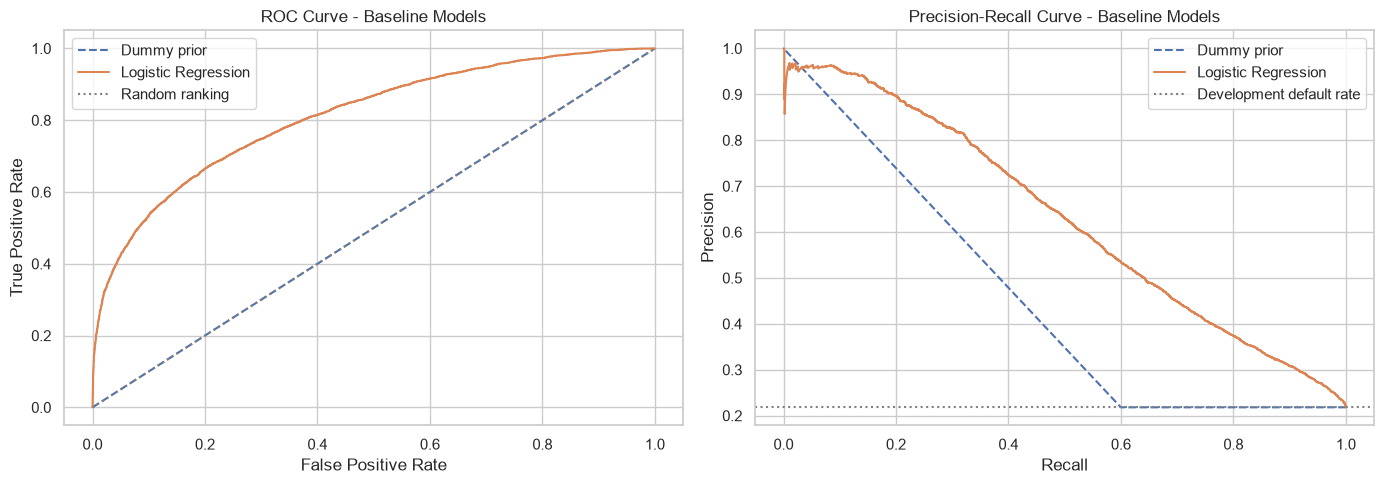

3.2 - LOGISTIC REGRESSION BASELINE


,model_name,feature_set,roc_auc,pr_auc,ks,gini,brier,stage,evaluation_data,calibration,notes
0,LogisticRegression_balanced,primary_engineered_features,0.8106,0.6294,0.4656,0.6212,0.1717,baseline,development_oof_cv,uncalibrated_raw_probability,"Baseline tuyến tính có class_weight='balanced', dùng engineered features, median/mode imputation, StandardScaler cho numeric và OneHotEncoder cho categorical."
1,DummyClassifier_prior,no_features_prior_rate,0.4999,0.2181,0.0000,-0.0002,0.1706,baseline,development_oof_cv,uncalibrated_prior,Baseline xác suất mặc định theo tỷ lệ default trong training fold; dùng làm mốc tối thiểu trước khi so sánh model thật.



Logistic Regression note:
Baseline tuyến tính có class_weight='balanced', dùng engineered features, median/mode imputation, StandardScaler cho numeric và OneHotEncoder cho categorical.


In [8]:
# 3.2 - Logistic Regression baseline

# ============================================================
# 1. Guard: cần output từ Feature Builder và Preprocessing
# ============================================================

required_objects = [
    "X_dev_raw",
    "y_dev",
    "cv_strategy",
    "BusinessRuleCleaner",
    "CreditRiskFeatureBuilder",
    "add_credit_risk_features",
    "preprocessor_logistic",
    "RANDOM_STATE",
    "build_metric_row",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy các cell 0.1, 0.2, 1.1, 2.1 và 2.2 trước. Thiếu: "
        + ", ".join(missing_objects)
    )

# ============================================================
# 2. Pipeline Logistic Regression baseline
# ============================================================

logistic_baseline_pipeline = Pipeline(
    steps=[
        (
            "business_cleaner",
            BusinessRuleCleaner(),
        ),
        (
            "feature_builder",
            CreditRiskFeatureBuilder(
                feature_function=add_credit_risk_features
            ),
        ),
        (
            "preprocess",
            preprocessor_logistic,
        ),
        (
            "model",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# ============================================================
# 3. Out-of-fold CV prediction
# ============================================================

logistic_oof_proba = cross_val_predict(
    logistic_baseline_pipeline,
    X_dev_raw,
    y_dev,
    cv=cv_strategy,
    method="predict_proba",
)[:, 1]

logistic_metric_row = build_metric_row(
    model_name="LogisticRegression_balanced",
    feature_set="primary_engineered_features",
    y_true=y_dev,
    y_score=logistic_oof_proba,
)

logistic_metric_row.update({
    "stage": "baseline",
    "evaluation_data": "development_oof_cv",
    "calibration": "uncalibrated_raw_probability",
    "notes": (
        "Baseline tuyến tính có class_weight='balanced', dùng engineered features, "
        "median/mode imputation, StandardScaler cho numeric và OneHotEncoder cho categorical."
    ),
})

# Fit lại trên toàn bộ Development Set để dùng cho calibration/model comparison.
logistic_baseline_pipeline.fit(
    X_dev_raw,
    y_dev,
)

# ============================================================
# 4. Lưu kết quả dùng lại cho các section sau
# ============================================================

if "cv_results_records" not in globals():
    cv_results_records = []

cv_results_records = [
    row
    for row in cv_results_records
    if row.get("model_name") != "LogisticRegression_balanced"
]
cv_results_records.append(logistic_metric_row)

if "baseline_predictions" not in globals():
    baseline_predictions = pd.DataFrame(
        index=X_dev_raw.index
    )

baseline_predictions["y_true"] = y_dev
baseline_predictions["logistic_regression_pd"] = logistic_oof_proba

if "model_artifacts" not in globals():
    model_artifacts = {}

model_artifacts["logistic_regression"] = {
    "model": logistic_baseline_pipeline,
    "feature_set": "primary_engineered_features",
}

cv_results = pd.DataFrame(cv_results_records)
baseline_model_metrics = cv_results[
    cv_results["model_name"].isin([
        "DummyClassifier_prior",
        "LogisticRegression_balanced",
    ])
].sort_values(
    by=["roc_auc", "pr_auc"],
    ascending=False,
).reset_index(drop=True)

# ============================================================
# 5. Đồ thị ROC và Precision-Recall baseline
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

if "dummy_prior_pd" in baseline_predictions.columns:
    dummy_fpr, dummy_tpr, _ = roc_curve(
        y_dev,
        baseline_predictions["dummy_prior_pd"],
    )
    axes[0].plot(
        dummy_fpr,
        dummy_tpr,
        linestyle="--",
        label="Dummy prior",
    )

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_dev,
    logistic_oof_proba,
)
axes[0].plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression",
)
axes[0].plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle=":",
    label="Random ranking",
)
axes[0].set_title("ROC Curve - Baseline Models")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

if "dummy_prior_pd" in baseline_predictions.columns:
    dummy_precision, dummy_recall, _ = precision_recall_curve(
        y_dev,
        baseline_predictions["dummy_prior_pd"],
    )
    axes[1].plot(
        dummy_recall,
        dummy_precision,
        linestyle="--",
        label="Dummy prior",
    )

logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_dev,
    logistic_oof_proba,
)
axes[1].plot(
    logistic_recall,
    logistic_precision,
    label="Logistic Regression",
)
axes[1].axhline(
    y_dev.mean(),
    color="gray",
    linestyle=":",
    label="Development default rate",
)
axes[1].set_title("Precision-Recall Curve - Baseline Models")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# 6. Display
# ============================================================

print("=" * 90)
print("3.2 - LOGISTIC REGRESSION BASELINE")
print("=" * 90)

display(
    baseline_model_metrics.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
    })
)

print("\nLogistic Regression note:")
print(logistic_metric_row["notes"])


## Section 4 - LightGBM, CatBoost và Model Comparison

Core stronger models theo plan là **LightGBM** và **CatBoost**. Nếu môi trường chưa cài package, ghi trạng thái `not_installed` thay vì thay bằng model khác làm core.

In [9]:
# 4.1 - Train / CV candidate models

# ============================================================
# 1. Guard: cần output từ các section trước
# ============================================================

required_objects = [
    "X_dev_raw",
    "y_dev",
    "cv_strategy",
    "BusinessRuleCleaner",
    "CreditRiskFeatureBuilder",
    "add_credit_risk_features",
    "preprocessor_lightgbm",
    "preprocessor_catboost",
    "categorical_feature_cols",
    "build_metric_row",
    "RANDOM_STATE",
    "LIGHTGBM_AVAILABLE",
    "CATBOOST_AVAILABLE",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy các cell 0.1, 0.2, 1.1, 2.1 và 2.2 trước. Thiếu: "
        + ", ".join(missing_objects)
    )

if "cv_results_records" not in globals():
    cv_results_records = []

if "model_artifacts" not in globals():
    model_artifacts = {}

if "candidate_predictions" not in globals():
    candidate_predictions = pd.DataFrame(
        index=X_dev_raw.index
    )

candidate_predictions["y_true"] = y_dev

model_availability_records = []
candidate_metric_rows = []

negative_count = int((y_dev == 0).sum())
positive_count = int((y_dev == 1).sum())

if positive_count == 0:
    raise ValueError(
        "Development Set không có class default=1, không thể train classifier."
    )

scale_pos_weight = negative_count / positive_count


class SklearnCompatibleCatBoostClassifier(BaseEstimator):
    """
    Thin sklearn-compatible wrapper for CatBoost.

    CatBoostClassifier can fail sklearn.clone() when cat_features is passed
    directly in the constructor. This wrapper stores simple constructor params
    unchanged, creates the real CatBoost model inside fit(), and passes
    cat_features to fit().
    """

    _estimator_type = "classifier"

    def __init__(
        self,
        cat_features=None,
        iterations=400,
        learning_rate=0.05,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    ):
        self.cat_features = cat_features
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.loss_function = loss_function
        self.eval_metric = eval_metric
        self.auto_class_weights = auto_class_weights
        self.random_seed = random_seed
        self.verbose = verbose
        self.allow_writing_files = allow_writing_files

    def fit(self, X, y):
        if not CATBOOST_AVAILABLE:
            raise ImportError("catboost chưa được cài trong môi trường hiện tại.")

        self.model_ = CatBoostClassifier(
            iterations=self.iterations,
            learning_rate=self.learning_rate,
            depth=self.depth,
            loss_function=self.loss_function,
            eval_metric=self.eval_metric,
            auto_class_weights=self.auto_class_weights,
            random_seed=self.random_seed,
            verbose=self.verbose,
            allow_writing_files=self.allow_writing_files,
        )

        fit_kwargs = {}
        if self.cat_features:
            fit_kwargs["cat_features"] = list(self.cat_features)

        self.model_.fit(
            X,
            y,
            **fit_kwargs,
        )

        self.classes_ = np.asarray(self.model_.classes_)
        return self

    def predict_proba(self, X):
        if not hasattr(self, "model_"):
            raise RuntimeError("Model chưa được fit.")
        return self.model_.predict_proba(X)

    def predict(self, X):
        if not hasattr(self, "model_"):
            raise RuntimeError("Model chưa được fit.")
        return self.model_.predict(X)


def evaluate_candidate_model(
    artifact_key,
    model_name,
    pipeline,
    feature_set,
    prediction_col,
    notes,
):
    """Run OOF CV, fit full Development model, then store metrics and artifact."""
    oof_proba = cross_val_predict(
        pipeline,
        X_dev_raw,
        y_dev,
        cv=cv_strategy,
        method="predict_proba",
    )[:, 1]

    metric_row = build_metric_row(
        model_name=model_name,
        feature_set=feature_set,
        y_true=y_dev,
        y_score=oof_proba,
    )

    metric_row.update({
        "stage": "candidate_model",
        "evaluation_data": "development_oof_cv",
        "calibration": "uncalibrated_raw_probability",
        "notes": notes,
    })

    fitted_pipeline = pipeline.fit(
        X_dev_raw,
        y_dev,
    )

    candidate_predictions[prediction_col] = oof_proba
    model_artifacts[artifact_key] = {
        "model": fitted_pipeline,
        "feature_set": feature_set,
    }

    return metric_row


# ============================================================
# 2. LightGBM candidate
# ============================================================

if LIGHTGBM_AVAILABLE:
    lightgbm_pipeline = Pipeline(
        steps=[
            (
                "business_cleaner",
                BusinessRuleCleaner(),
            ),
            (
                "feature_builder",
                CreditRiskFeatureBuilder(
                    feature_function=add_credit_risk_features
                ),
            ),
            (
                "preprocess",
                preprocessor_lightgbm,
            ),
            (
                "model",
                LGBMClassifier(
                    objective="binary",
                    n_estimators=400,
                    learning_rate=0.05,
                    num_leaves=31,
                    max_depth=-1,
                    min_child_samples=40,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    reg_alpha=0.0,
                    reg_lambda=1.0,
                    scale_pos_weight=scale_pos_weight,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1,
                ),
            ),
        ]
    )

    lightgbm_metric_row = evaluate_candidate_model(
        artifact_key="lightgbm_primary",
        model_name="LightGBM_primary",
        pipeline=lightgbm_pipeline,
        feature_set="primary_engineered_features",
        prediction_col="lightgbm_primary_pd",
        notes=(
            "LightGBM candidate dùng Primary feature set, engineered features, "
            "median/mode imputation và one-hot categorical encoding."
        ),
    )

    candidate_metric_rows.append(lightgbm_metric_row)
    model_availability_records.append({
        "model": "LightGBM",
        "status": "trained",
        "reason": "lightgbm package is available",
    })
else:
    model_availability_records.append({
        "model": "LightGBM",
        "status": "not_installed",
        "reason": "Cài lightgbm để train core candidate này.",
    })

# ============================================================
# 3. CatBoost candidate
# ============================================================

if CATBOOST_AVAILABLE:
    catboost_pipeline = Pipeline(
        steps=[
            (
                "business_cleaner",
                BusinessRuleCleaner(),
            ),
            (
                "feature_builder",
                CreditRiskFeatureBuilder(
                    feature_function=add_credit_risk_features
                ),
            ),
            (
                "preprocess",
                preprocessor_catboost,
            ),
            (
                "model",
                SklearnCompatibleCatBoostClassifier(
                    cat_features=tuple(categorical_feature_cols),
                    iterations=400,
                    learning_rate=0.05,
                    depth=5,
                    loss_function="Logloss",
                    eval_metric="AUC",
                    auto_class_weights="Balanced",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                    allow_writing_files=False,
                ),
            ),
        ]
    )

    catboost_metric_row = evaluate_candidate_model(
        artifact_key="catboost_primary",
        model_name="CatBoost_primary",
        pipeline=catboost_pipeline,
        feature_set="primary_engineered_features",
        prediction_col="catboost_primary_pd",
        notes=(
            "CatBoost candidate dùng Primary feature set và native categorical handling; "
            "không one-hot categorical variables."
        ),
    )

    candidate_metric_rows.append(catboost_metric_row)
    model_availability_records.append({
        "model": "CatBoost",
        "status": "trained",
        "reason": "catboost package is available",
    })
else:
    model_availability_records.append({
        "model": "CatBoost",
        "status": "not_installed",
        "reason": "Cài catboost để train core candidate này.",
    })

# ============================================================
# 4. Cập nhật bảng CV results
# ============================================================

candidate_model_names = {
    "LightGBM_primary",
    "CatBoost_primary",
}

cv_results_records = [
    row
    for row in cv_results_records
    if row.get("model_name") not in candidate_model_names
]
cv_results_records.extend(candidate_metric_rows)

cv_results = pd.DataFrame(cv_results_records)
candidate_model_metrics = pd.DataFrame(candidate_metric_rows)
model_availability = pd.DataFrame(model_availability_records)

# ============================================================
# 5. Display
# ============================================================

print("=" * 90)
print("4.1 - TRAIN / CV CANDIDATE MODELS")
print("=" * 90)

display(model_availability)

if candidate_model_metrics.empty:
    print(
        "\nChưa có core candidate nào được train vì LightGBM/CatBoost chưa được cài."
    )
else:
    display(
        candidate_model_metrics.sort_values(
            by=["roc_auc", "pr_auc"],
            ascending=False,
        ).style.format({
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}",
            "ks": "{:.4f}",
            "gini": "{:.4f}",
            "brier": "{:.4f}",
        })
    )


4.1 - TRAIN / CV CANDIDATE MODELS


,model,status,reason
0,LightGBM,trained,lightgbm package is available
1,CatBoost,trained,catboost package is available


,model_name,feature_set,roc_auc,pr_auc,ks,gini,brier,stage,evaluation_data,calibration,notes
0,LightGBM_primary,primary_engineered_features,0.8923,0.8019,0.6131,0.7845,0.1037,candidate_model,development_oof_cv,uncalibrated_raw_probability,"LightGBM candidate dùng Primary feature set, engineered features, median/mode imputation và one-hot categorical encoding."
1,CatBoost_primary,primary_engineered_features,0.8846,0.7936,0.5966,0.7691,0.1190,candidate_model,development_oof_cv,uncalibrated_raw_probability,CatBoost candidate dùng Primary feature set và native categorical handling; không one-hot categorical variables.


In [10]:
# 4.2 - Model metrics table

# ============================================================
# 1. Guard
# ============================================================

if "cv_results_records" not in globals():
    raise RuntimeError(
        "Hãy chạy cell 3.1, 3.2 và 4.1 trước để có cv_results_records."
    )

if not cv_results_records:
    raise ValueError(
        "cv_results_records đang rỗng, chưa có model nào để so sánh."
    )

# ============================================================
# 2. Chuẩn hóa bảng metrics
# ============================================================

model_metrics = pd.DataFrame(
    cv_results_records
).copy()

required_metric_cols = [
    "model_name",
    "feature_set",
    "roc_auc",
    "pr_auc",
    "ks",
    "gini",
    "brier",
]

missing_metric_cols = [
    col
    for col in required_metric_cols
    if col not in model_metrics.columns
]

if missing_metric_cols:
    raise KeyError(
        "Thiếu metric columns: "
        + ", ".join(missing_metric_cols)
    )

model_metrics = model_metrics.drop_duplicates(
    subset=["model_name", "feature_set", "evaluation_data"],
    keep="last",
)

metric_rank_cols = [
    "roc_auc",
    "pr_auc",
    "ks",
]

for metric_col in metric_rank_cols:
    model_metrics[f"{metric_col}_rank"] = model_metrics[
        metric_col
    ].rank(
        ascending=False,
        method="min",
    )

model_metrics["brier_rank"] = model_metrics["brier"].rank(
    ascending=True,
    method="min",
)

model_metrics["mean_rank"] = model_metrics[
    [
        "roc_auc_rank",
        "pr_auc_rank",
        "ks_rank",
        "brier_rank",
    ]
].mean(axis=1)

model_metrics = model_metrics.sort_values(
    by=[
        "mean_rank",
        "roc_auc_rank",
        "pr_auc_rank",
        "brier_rank",
    ],
    ascending=True,
).reset_index(drop=True)

model_metrics["overall_rank"] = np.arange(
    1,
    len(model_metrics) + 1,
)

leaderboard_cols = [
    "overall_rank",
    "model_name",
    "feature_set",
    "stage",
    "evaluation_data",
    "calibration",
    "roc_auc",
    "pr_auc",
    "ks",
    "gini",
    "brier",
    "mean_rank",
    "notes",
]

available_leaderboard_cols = [
    col
    for col in leaderboard_cols
    if col in model_metrics.columns
]

model_leaderboard = model_metrics[
    available_leaderboard_cols
].copy()

model_comparison_note = (
    "Bảng này chỉ là leaderboard trên Development Out-of-Fold CV. "
    "Không chọn champion chỉ bằng một metric đơn lẻ: cần xem đồng thời "
    "ROC-AUC, PR-AUC, KS, Brier, calibration, leakage risk, fairness "
    "và business threshold ở các section sau. Locked Test vẫn chưa được dùng."
)

# ============================================================
# 3. Display
# ============================================================

print("=" * 90)
print("4.2 - MODEL METRICS TABLE")
print("=" * 90)

display(
    model_leaderboard.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
        "mean_rank": "{:.2f}",
    })
)

print("\nModel comparison note:")
print(model_comparison_note)


4.2 - MODEL METRICS TABLE


,overall_rank,model_name,feature_set,stage,evaluation_data,calibration,roc_auc,pr_auc,ks,gini,brier,mean_rank,notes
0,1,LightGBM_primary,primary_engineered_features,candidate_model,development_oof_cv,uncalibrated_raw_probability,0.8923,0.8019,0.6131,0.7845,0.1037,1.00,"LightGBM candidate dùng Primary feature set, engineered features, median/mode imputation và one-hot categorical encoding."
1,2,CatBoost_primary,primary_engineered_features,candidate_model,development_oof_cv,uncalibrated_raw_probability,0.8846,0.7936,0.5966,0.7691,0.1190,2.00,CatBoost candidate dùng Primary feature set và native categorical handling; không one-hot categorical variables.
2,3,LogisticRegression_balanced,primary_engineered_features,baseline,development_oof_cv,uncalibrated_raw_probability,0.8106,0.6294,0.4656,0.6212,0.1717,3.25,"Baseline tuyến tính có class_weight='balanced', dùng engineered features, median/mode imputation, StandardScaler cho numeric và OneHotEncoder cho categorical."
3,4,DummyClassifier_prior,no_features_prior_rate,baseline,development_oof_cv,uncalibrated_prior,0.4999,0.2181,0.0000,-0.0002,0.1706,3.75,Baseline xác suất mặc định theo tỷ lệ default trong training fold; dùng làm mốc tối thiểu trước khi so sánh model thật.



Model comparison note:
Bảng này chỉ là leaderboard trên Development Out-of-Fold CV. Không chọn champion chỉ bằng một metric đơn lẻ: cần xem đồng thời ROC-AUC, PR-AUC, KS, Brier, calibration, leakage risk, fairness và business threshold ở các section sau. Locked Test vẫn chưa được dùng.


In [11]:
# 4.3 - Leakage Ablation Study

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "X_dev_raw",
    "y_dev",
    "cv_strategy",
    "primary_feature_cols",
    "audit_only_cols",
    "TARGET_COL",
    "ID_COL",
    "build_metric_row",
    "BusinessRuleCleaner",
    "CreditRiskFeatureBuilder",
    "CatBoostDataFramePreprocessor",
    "add_credit_risk_features",
    "make_one_hot_encoder",
    "RANDOM_STATE",
    "LIGHTGBM_AVAILABLE",
    "CATBOOST_AVAILABLE",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy các cell 0.1, 0.2, 1.1, 2.1 và 2.2 trước. Thiếu: "
        + ", ".join(missing_objects)
    )

available_leakage_cols = [
    col
    for col in [
        "loan_int_rate",
        "loan_grade",
    ]
    if col in X_dev_extended_raw.columns
]

ablation_model_records = []
ablation_predictions = pd.DataFrame(
    {
        "y_true": y_dev
    },
    index=X_dev_raw.index,
)


class SklearnCompatibleCatBoostClassifier(BaseEstimator):
    """
    Thin sklearn-compatible wrapper for CatBoost.

    CatBoostClassifier can fail sklearn.clone() when cat_features is passed
    directly in the constructor. This wrapper stores simple constructor params
    unchanged, creates the real CatBoost model inside fit(), and passes
    cat_features to fit().
    """

    _estimator_type = "classifier"

    def __init__(
        self,
        cat_features=None,
        iterations=400,
        learning_rate=0.05,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    ):
        self.cat_features = cat_features
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.loss_function = loss_function
        self.eval_metric = eval_metric
        self.auto_class_weights = auto_class_weights
        self.random_seed = random_seed
        self.verbose = verbose
        self.allow_writing_files = allow_writing_files

    def fit(self, X, y):
        if not CATBOOST_AVAILABLE:
            raise ImportError("catboost chưa được cài trong môi trường hiện tại.")

        self.model_ = CatBoostClassifier(
            iterations=self.iterations,
            learning_rate=self.learning_rate,
            depth=self.depth,
            loss_function=self.loss_function,
            eval_metric=self.eval_metric,
            auto_class_weights=self.auto_class_weights,
            random_seed=self.random_seed,
            verbose=self.verbose,
            allow_writing_files=self.allow_writing_files,
        )

        fit_kwargs = {}
        if self.cat_features:
            fit_kwargs["cat_features"] = list(self.cat_features)

        self.model_.fit(
            X,
            y,
            **fit_kwargs,
        )

        self.classes_ = np.asarray(self.model_.classes_)
        return self

    def predict_proba(self, X):
        if not hasattr(self, "model_"):
            raise RuntimeError("Model chưa được fit.")
        return self.model_.predict_proba(X)

    def predict(self, X):
        if not hasattr(self, "model_"):
            raise RuntimeError("Model chưa được fit.")
        return self.model_.predict(X)


def classify_columns_after_feature_builder(X_input):
    """Infer numeric/categorical columns after credit-risk feature engineering."""
    preview_builder = CreditRiskFeatureBuilder(
        feature_function=add_credit_risk_features
    )
    X_preview = preview_builder.fit_transform(
        X_input.head(
            min(1000, len(X_input))
        ).copy()
    )

    numeric_cols = X_preview.select_dtypes(
        include=[
            np.number,
            "bool",
        ]
    ).columns.tolist()

    categorical_cols = [
        col
        for col in X_preview.columns
        if col not in numeric_cols
    ]

    return numeric_cols, categorical_cols


def make_lightgbm_preprocessor_for(X_input):
    numeric_cols, categorical_cols = classify_columns_after_feature_builder(
        X_input
    )

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "onehot",
                make_one_hot_encoder(),
            ),
        ]
    )

    transformers = [
        (
            "numeric",
            numeric_pipeline,
            numeric_cols,
        )
    ]

    if categorical_cols:
        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_cols,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_catboost_preprocessor_for(X_input):
    numeric_cols, categorical_cols = classify_columns_after_feature_builder(
        X_input
    )

    return (
        CatBoostDataFramePreprocessor(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
        ),
        categorical_cols,
    )


def make_logistic_preprocessor_for(X_input):
    numeric_cols, categorical_cols = classify_columns_after_feature_builder(
        X_input
    )

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "onehot",
                make_one_hot_encoder(),
            ),
        ]
    )

    transformers = [
        (
            "numeric",
            numeric_pipeline,
            numeric_cols,
        )
    ]

    if categorical_cols:
        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_cols,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def build_ablation_pipeline(X_input):
    """Use LightGBM if available, otherwise CatBoost, otherwise Logistic Regression."""
    neg_count = int((y_dev == 0).sum())
    pos_count = int((y_dev == 1).sum())
    pos_weight = neg_count / pos_count

    if LIGHTGBM_AVAILABLE:
        preprocessor = make_lightgbm_preprocessor_for(
            X_input
        )

        estimator = LGBMClassifier(
            objective="binary",
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=40,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )

        model_family = "LightGBM"

    elif CATBOOST_AVAILABLE:
        preprocessor, categorical_cols = make_catboost_preprocessor_for(
            X_input
        )

        estimator = SklearnCompatibleCatBoostClassifier(
            cat_features=tuple(categorical_cols),
            iterations=300,
            learning_rate=0.05,
            depth=5,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )

        model_family = "CatBoost"

    else:
        preprocessor = make_logistic_preprocessor_for(
            X_input
        )
        estimator = LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
        model_family = "LogisticRegression"

    pipeline = Pipeline(
        steps=[
            (
                "business_cleaner",
                BusinessRuleCleaner(),
            ),
            (
                "feature_builder",
                CreditRiskFeatureBuilder(
                    feature_function=add_credit_risk_features
                ),
            ),
            (
                "preprocess",
                preprocessor,
            ),
            (
                "model",
                estimator,
            ),
        ]
    )

    return pipeline, model_family


# ============================================================
# 2. Define ablation scenarios
# ============================================================

ablation_scenarios = [
    {
        "scenario": "M1_primary",
        "feature_set": "Primary",
        "added_leakage_cols": [],
    },
    {
        "scenario": "M2_primary_plus_loan_int_rate",
        "feature_set": "Primary + loan_int_rate",
        "added_leakage_cols": [
            "loan_int_rate",
        ],
    },
    {
        "scenario": "M3_primary_plus_loan_grade",
        "feature_set": "Primary + loan_grade",
        "added_leakage_cols": [
            "loan_grade",
        ],
    },
    {
        "scenario": "M4_primary_plus_rate_and_grade",
        "feature_set": "Primary + loan_int_rate + loan_grade",
        "added_leakage_cols": [
            "loan_int_rate",
            "loan_grade",
        ],
    },
]

ablation_scenarios = [
    scenario
    for scenario in ablation_scenarios
    if set(scenario["added_leakage_cols"]).issubset(
        set(available_leakage_cols)
    )
]

if not ablation_scenarios:
    raise ValueError(
        "Không có scenario leakage ablation nào chạy được. "
        "Cần ít nhất Primary feature set."
    )

# ============================================================
# 3. Run ablation CV
# ============================================================

for scenario in ablation_scenarios:
    selected_cols = list(
        dict.fromkeys(
            primary_feature_cols
            + scenario["added_leakage_cols"]
        )
    )

    forbidden_cols = [
        col
        for col in selected_cols
        if col in [TARGET_COL, ID_COL] or col in audit_only_cols
    ]

    if forbidden_cols:
        raise AssertionError(
            "Ablation feature set chứa cột không được phép: "
            + ", ".join(forbidden_cols)
        )

    X_dev_ablation = X_dev_extended_raw[
        selected_cols
    ].copy()

    ablation_pipeline, model_family = build_ablation_pipeline(
        X_dev_ablation
    )

    ablation_oof_proba = cross_val_predict(
        ablation_pipeline,
        X_dev_ablation,
        y_dev,
        cv=cv_strategy,
        method="predict_proba",
    )[:, 1]

    metric_row = build_metric_row(
        model_name=f"{model_family}_{scenario['scenario']}",
        feature_set=scenario["feature_set"],
        y_true=y_dev,
        y_score=ablation_oof_proba,
    )

    metric_row.update({
        "scenario": scenario["scenario"],
        "model_family": model_family,
        "added_leakage_cols": ", ".join(
            scenario["added_leakage_cols"]
        ) if scenario["added_leakage_cols"] else "None",
        "stage": "leakage_ablation",
        "evaluation_data": "development_oof_cv",
        "calibration": "uncalibrated_raw_probability",
    })

    ablation_model_records.append(metric_row)
    ablation_predictions[
        f"{scenario['scenario']}_pd"
    ] = ablation_oof_proba

ablation_results = pd.DataFrame(
    ablation_model_records
)

primary_rows = ablation_results[
    ablation_results["scenario"].eq("M1_primary")
]

if primary_rows.empty:
    raise AssertionError(
        "Thiếu M1_primary để tính lift leakage ablation."
    )

primary_metrics = primary_rows.iloc[0]

for metric_col in [
    "roc_auc",
    "pr_auc",
    "ks",
    "gini",
    "brier",
]:
    ablation_results[f"{metric_col}_lift_vs_primary"] = (
        ablation_results[metric_col]
        - primary_metrics[metric_col]
    )

ablation_results = ablation_results.sort_values(
    by=[
        "roc_auc",
        "pr_auc",
    ],
    ascending=False,
).reset_index(drop=True)

leakage_ablation_note = (
    "Nếu thêm loan_int_rate hoặc loan_grade làm metric tăng mạnh so với Primary, "
    "đó là bằng chứng cần xem xét leakage/post-approval information. "
    "Kết quả ablation chỉ dùng để đánh giá rủi ro thông tin, không tự động cho phép "
    "đưa các biến này vào production model."
)

# ============================================================
# 4. Display
# ============================================================

print("=" * 90)
print("4.3 - LEAKAGE ABLATION STUDY")
print("=" * 90)

print("Available leakage candidates:")
print(available_leakage_cols)

display(
    ablation_results.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
        "roc_auc_lift_vs_primary": "{:+.4f}",
        "pr_auc_lift_vs_primary": "{:+.4f}",
        "ks_lift_vs_primary": "{:+.4f}",
        "gini_lift_vs_primary": "{:+.4f}",
        "brier_lift_vs_primary": "{:+.4f}",
    })
)

print("\nLeakage ablation note:")
print(leakage_ablation_note)


4.3 - LEAKAGE ABLATION STUDY
Available leakage candidates:
['loan_int_rate', 'loan_grade']


,model_name,feature_set,roc_auc,pr_auc,ks,gini,brier,scenario,model_family,added_leakage_cols,stage,evaluation_data,calibration,roc_auc_lift_vs_primary,pr_auc_lift_vs_primary,ks_lift_vs_primary,gini_lift_vs_primary,brier_lift_vs_primary
0,LightGBM_M3_primary_plus_loan_grade,Primary + loan_grade,0.9399,0.8933,0.7364,0.8798,0.0673,M3_primary_plus_loan_grade,LightGBM,loan_grade,leakage_ablation,development_oof_cv,uncalibrated_raw_probability,+0.0478,+0.0921,+0.1233,+0.0956,-0.0397
1,LightGBM_M4_primary_plus_rate_and_grade,Primary + loan_int_rate + loan_grade,0.9397,0.8925,0.7328,0.8795,0.0680,M4_primary_plus_rate_and_grade,LightGBM,"loan_int_rate, loan_grade",leakage_ablation,development_oof_cv,uncalibrated_raw_probability,+0.0476,+0.0913,+0.1197,+0.0952,-0.0389
2,LightGBM_M2_primary_plus_loan_int_rate,Primary + loan_int_rate,0.9308,0.8747,0.7060,0.8617,0.0777,M2_primary_plus_loan_int_rate,LightGBM,loan_int_rate,leakage_ablation,development_oof_cv,uncalibrated_raw_probability,+0.0387,+0.0735,+0.0929,+0.0774,-0.0292
3,LightGBM_M1_primary,Primary,0.8921,0.8012,0.6131,0.7843,0.1070,M1_primary,LightGBM,None,leakage_ablation,development_oof_cv,uncalibrated_raw_probability,+0.0000,+0.0000,+0.0000,+0.0000,+0.0000



Leakage ablation note:
Nếu thêm loan_int_rate hoặc loan_grade làm metric tăng mạnh so với Primary, đó là bằng chứng cần xem xét leakage/post-approval information. Kết quả ablation chỉ dùng để đánh giá rủi ro thông tin, không tự động cho phép đưa các biến này vào production model.


## Section 5 - Hyperparameter Tuning

Tune only on Development Set / CV. Do not touch Locked Test while tuning.

In [12]:
# 5.1 - Hyperparameter tuning plan

from sklearn.model_selection import ParameterGrid

# ============================================================
# 1. Guard: tuning chỉ dùng Development Set / CV
# ============================================================

required_objects = [
    "X_dev_raw",
    "y_dev",
    "cv_strategy",
    "RANDOM_STATE",
    "N_SPLITS",
    "CreditRiskFeatureBuilder",
    "add_credit_risk_features",
    "preprocessor_logistic",
    "preprocessor_lightgbm",
    "preprocessor_catboost",
    "categorical_feature_cols",
    "build_metric_row",
    "LIGHTGBM_AVAILABLE",
    "CATBOOST_AVAILABLE",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy các cell 0.1, 0.2, 1.1, 2.1 và 2.2 trước. Thiếu: "
        + ", ".join(missing_objects)
    )

# ============================================================
# 2. Small reproducible search spaces
# ============================================================
#
# Không tune Dummy Classifier.
# Không đưa loan_int_rate / loan_grade vào tuning chính.
# Không đưa audit-only features vào tuning chính.
# X_dev_raw ở luồng notebook hiện tại chính là Primary Feature Set.

tuning_search_spaces = {
    "logistic": {
        "model__C": [
            1.0,
        ],
        "model__class_weight": [
            "balanced",
        ],
    },
    "lightgbm": {
        "model__n_estimators": [
            150,
        ],
        "model__learning_rate": [
            0.05,
        ],
        "model__num_leaves": [
            31,
        ],
        "model__max_depth": [
            -1,
        ],
        "model__min_child_samples": [
            40,
        ],
        "model__subsample": [
            0.85,
        ],
        "model__colsample_bytree": [
            0.85,
        ],
    },
    "catboost": {
        "model__iterations": [
            120,
        ],
        "model__depth": [
            5,
        ],
        "model__learning_rate": [
            0.05,
        ],
        "model__l2_leaf_reg": [
            3.0,
        ],
        "model__random_strength": [
            1.0,
        ],
    },
}

# ============================================================
# 3. Model registry
# ============================================================

tuning_model_registry = {
    "logistic": {
        "model_name": "LogisticRegression",
        "available": True,
        "preprocessor": "preprocessor_logistic",
        "feature_set": "primary_engineered_features",
        "notes": (
            "Tune C và class_weight; giữ solver lbfgs để tránh tổ hợp penalty/solver không tương thích."
        ),
    },
    "lightgbm": {
        "model_name": "LightGBM",
        "available": LIGHTGBM_AVAILABLE,
        "preprocessor": "preprocessor_lightgbm",
        "feature_set": "primary_engineered_features",
        "notes": (
            "Tune budget nhỏ cho boosting depth/learning rate/tree count; không thay bằng model khác nếu chưa cài."
        ),
    },
    "catboost": {
        "model_name": "CatBoost",
        "available": CATBOOST_AVAILABLE,
        "preprocessor": "preprocessor_catboost",
        "feature_set": "primary_engineered_features",
        "notes": (
            "Tune native categorical CatBoost; cat_features được truyền trong fit qua wrapper sklearn-compatible."
        ),
    },
}

# ============================================================
# 4. Plan summary
# ============================================================

tuning_plan_records = []

for model_key, registry_row in tuning_model_registry.items():
    estimated_candidates = len(
        list(
            ParameterGrid(
                tuning_search_spaces[model_key]
            )
        )
    )

    tuning_plan_records.append({
        "model_key": model_key,
        "model_name": registry_row["model_name"],
        "available": registry_row["available"],
        "search_method": "manual_grid_cv_small_budget",
        "estimated_candidates": estimated_candidates,
        "parameter_count": len(tuning_search_spaces[model_key]),
        "cv_folds": N_SPLITS,
        "primary_metric": "roc_auc",
        "tracked_metrics": "roc_auc, pr_auc, ks, gini, brier",
        "feature_set": registry_row["feature_set"],
        "status": "ready" if registry_row["available"] else "not_installed",
        "notes": registry_row["notes"],
    })

tuning_plan = pd.DataFrame(
    tuning_plan_records
)

tuning_plan_note = (
    "Section 5 chỉ tune trên Development Set bằng Stratified CV. "
    "Pipeline của từng candidate luôn gồm BusinessRuleCleaner, Feature Builder, preprocessing và model; "
    "không fit preprocessing trước CV. Primary metric là ROC-AUC, nhưng PR-AUC, KS, "
    "Brier và độ ổn định fold cũng được theo dõi. Gini được tính từ ROC-AUC nên "
    "không được double-weight khi chọn best params."
)

# ============================================================
# 5. Display
# ============================================================

print("=" * 90)
print("5.1 - HYPERPARAMETER TUNING PLAN")
print("=" * 90)

display(tuning_plan)

print("\nTuning search spaces:")
for model_key, search_space in tuning_search_spaces.items():
    print(f"\n{model_key}:")
    print(search_space)

print("\nTuning plan note:")
print(tuning_plan_note)


5.1 - HYPERPARAMETER TUNING PLAN


,model_key,model_name,available,search_method,estimated_candidates,parameter_count,cv_folds,primary_metric,tracked_metrics,feature_set,status,notes
0,logistic,LogisticRegression,True,manual_grid_cv_small_budget,1,2,5,roc_auc,"roc_auc, pr_auc, ks, gini, brier",primary_engineered_features,ready,Tune C và class_weight; giữ solver lbfgs để tr...
1,lightgbm,LightGBM,True,manual_grid_cv_small_budget,1,7,5,roc_auc,"roc_auc, pr_auc, ks, gini, brier",primary_engineered_features,ready,Tune budget nhỏ cho boosting depth/learning ra...
2,catboost,CatBoost,True,manual_grid_cv_small_budget,1,5,5,roc_auc,"roc_auc, pr_auc, ks, gini, brier",primary_engineered_features,ready,Tune native categorical CatBoost; cat_features...



Tuning search spaces:

logistic:
{'model__C': [1.0], 'model__class_weight': ['balanced']}

lightgbm:
{'model__n_estimators': [150], 'model__learning_rate': [0.05], 'model__num_leaves': [31], 'model__max_depth': [-1], 'model__min_child_samples': [40], 'model__subsample': [0.85], 'model__colsample_bytree': [0.85]}

catboost:
{'model__iterations': [120], 'model__depth': [5], 'model__learning_rate': [0.05], 'model__l2_leaf_reg': [3.0], 'model__random_strength': [1.0]}

Tuning plan note:
Section 5 chỉ tune trên Development Set bằng Stratified CV. Pipeline của từng candidate luôn gồm BusinessRuleCleaner, Feature Builder, preprocessing và model; không fit preprocessing trước CV. Primary metric là ROC-AUC, nhưng PR-AUC, KS, Brier và độ ổn định fold cũng được theo dõi. Gini được tính từ ROC-AUC nên không được double-weight khi chọn best params.


In [13]:
# 5.2 - Run tuning candidates

from sklearn.model_selection import ParameterGrid

# ============================================================
# 1. Guard: chỉ dùng Development Set / CV
# ============================================================

required_objects = [
    "X_dev_raw",
    "y_dev",
    "cv_strategy",
    "tuning_search_spaces",
    "tuning_model_registry",
    "BusinessRuleCleaner",
    "CreditRiskFeatureBuilder",
    "add_credit_risk_features",
    "preprocessor_logistic",
    "preprocessor_lightgbm",
    "preprocessor_catboost",
    "categorical_feature_cols",
    "build_metric_row",
    "positive_class_proba",
    "gini_from_auc",
    "RANDOM_STATE",
    "LIGHTGBM_AVAILABLE",
    "CATBOOST_AVAILABLE",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy cell 5.1 và các cell tiền xử lý trước. Thiếu: "
        + ", ".join(missing_objects)
    )

if "model_artifacts" not in globals():
    model_artifacts = {}

if "cv_results_records" not in globals():
    cv_results_records = []

negative_count = int((y_dev == 0).sum())
positive_count = int((y_dev == 1).sum())

if positive_count == 0:
    raise ValueError(
        "Development Set không có class default=1, không thể tune classifier."
    )

scale_pos_weight = negative_count / positive_count

# ============================================================
# 2. CatBoost wrapper dùng riêng cho tuning
# ============================================================

class TuningCatBoostClassifier(BaseEstimator):
    """
    Wrapper để CatBoost chạy ổn trong sklearn Pipeline và manual CV.
    cat_features được truyền vào fit(), không truyền trực tiếp vào constructor CatBoost.
    """

    _estimator_type = "classifier"

    def __init__(
        self,
        cat_features=None,
        iterations=300,
        learning_rate=0.05,
        depth=5,
        l2_leaf_reg=3.0,
        random_strength=1.0,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    ):
        self.cat_features = cat_features
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.l2_leaf_reg = l2_leaf_reg
        self.random_strength = random_strength
        self.loss_function = loss_function
        self.eval_metric = eval_metric
        self.auto_class_weights = auto_class_weights
        self.random_seed = random_seed
        self.verbose = verbose
        self.allow_writing_files = allow_writing_files

    def fit(self, X, y):
        if not CATBOOST_AVAILABLE:
            raise ImportError("catboost chưa được cài trong môi trường hiện tại.")

        self.model_ = CatBoostClassifier(
            iterations=self.iterations,
            learning_rate=self.learning_rate,
            depth=self.depth,
            l2_leaf_reg=self.l2_leaf_reg,
            random_strength=self.random_strength,
            loss_function=self.loss_function,
            eval_metric=self.eval_metric,
            auto_class_weights=self.auto_class_weights,
            random_seed=self.random_seed,
            verbose=self.verbose,
            allow_writing_files=self.allow_writing_files,
        )

        fit_kwargs = {}
        if self.cat_features:
            fit_kwargs["cat_features"] = list(self.cat_features)

        self.model_.fit(
            X,
            y,
            **fit_kwargs,
        )

        self.classes_ = np.asarray(
            self.model_.classes_
        )

        return self

    def predict_proba(self, X):
        if not hasattr(self, "model_"):
            raise RuntimeError("Model chưa được fit.")
        return self.model_.predict_proba(X)

    def predict(self, X):
        if not hasattr(self, "model_"):
            raise RuntimeError("Model chưa được fit.")
        return self.model_.predict(X)


# ============================================================
# 3. Pipeline factory
# ============================================================

def make_tuning_pipeline(model_key, params):
    if model_key == "logistic":
        estimator = LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )

        pipeline = Pipeline(
            steps=[
                (
                    "feature_builder",
                    CreditRiskFeatureBuilder(
                        feature_function=add_credit_risk_features
                    ),
                ),
                (
                    "preprocess",
                    preprocessor_logistic,
                ),
                (
                    "model",
                    estimator,
                ),
            ]
        )

    elif model_key == "lightgbm":
        if not LIGHTGBM_AVAILABLE:
            raise ImportError("lightgbm chưa được cài trong môi trường hiện tại.")

        estimator = LGBMClassifier(
            objective="binary",
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=40,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )

        pipeline = Pipeline(
            steps=[
                (
                    "feature_builder",
                    CreditRiskFeatureBuilder(
                        feature_function=add_credit_risk_features
                    ),
                ),
                (
                    "preprocess",
                    preprocessor_lightgbm,
                ),
                (
                    "model",
                    estimator,
                ),
            ]
        )

    elif model_key == "catboost":
        if not CATBOOST_AVAILABLE:
            raise ImportError("catboost chưa được cài trong môi trường hiện tại.")

        estimator = TuningCatBoostClassifier(
            cat_features=tuple(categorical_feature_cols),
            iterations=300,
            learning_rate=0.05,
            depth=5,
            l2_leaf_reg=3.0,
            random_strength=1.0,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )

        pipeline = Pipeline(
            steps=[
                (
                    "feature_builder",
                    CreditRiskFeatureBuilder(
                        feature_function=add_credit_risk_features
                    ),
                ),
                (
                    "preprocess",
                    preprocessor_catboost,
                ),
                (
                    "model",
                    estimator,
                ),
            ]
        )

    else:
        raise ValueError(f"Unknown model_key: {model_key}")

    return pipeline.set_params(**params)


# ============================================================
# 4. Manual CV evaluation for one params set
# ============================================================

def evaluate_tuning_candidate(model_key, params, candidate_id):
    fold_metric_rows = []
    oof_proba = pd.Series(
        data=np.nan,
        index=y_dev.index,
        dtype=float,
    )

    for fold_number, (train_idx, valid_idx) in enumerate(
        cv_strategy.split(
            X_dev_raw,
            y_dev,
        ),
        start=1,
    ):
        X_train_fold = X_dev_raw.iloc[
            train_idx
        ].copy()

        y_train_fold = y_dev.iloc[
            train_idx
        ].copy()

        X_valid_fold = X_dev_raw.iloc[
            valid_idx
        ].copy()

        y_valid_fold = y_dev.iloc[
            valid_idx
        ].copy()

        pipeline = make_tuning_pipeline(
            model_key=model_key,
            params=params,
        )

        pipeline.fit(
            X_train_fold,
            y_train_fold,
        )

        valid_proba = positive_class_proba(
            pipeline,
            X_valid_fold,
        )

        oof_proba.iloc[
            valid_idx
        ] = valid_proba

        fold_metric = build_metric_row(
            model_name=tuning_model_registry[model_key]["model_name"],
            feature_set=tuning_model_registry[model_key]["feature_set"],
            y_true=y_valid_fold,
            y_score=valid_proba,
        )

        fold_metric["fold"] = fold_number
        fold_metric_rows.append(
            fold_metric
        )

    if oof_proba.isna().any():
        raise ValueError(
            f"OOF predictions còn missing cho {model_key}, candidate {candidate_id}."
        )

    fold_metrics = pd.DataFrame(
        fold_metric_rows
    )

    result = {
        "model_key": model_key,
        "model_name": tuning_model_registry[model_key]["model_name"],
        "candidate_id": candidate_id,
        "params": params,
        "mean_roc_auc": float(fold_metrics["roc_auc"].mean()),
        "std_roc_auc": float(fold_metrics["roc_auc"].std(ddof=0)),
        "mean_pr_auc": float(fold_metrics["pr_auc"].mean()),
        "std_pr_auc": float(fold_metrics["pr_auc"].std(ddof=0)),
        "mean_ks": float(fold_metrics["ks"].mean()),
        "std_ks": float(fold_metrics["ks"].std(ddof=0)),
        "gini": gini_from_auc(
            float(fold_metrics["roc_auc"].mean())
        ),
        "mean_brier": float(fold_metrics["brier"].mean()),
        "std_brier": float(fold_metrics["brier"].std(ddof=0)),
        "status": "success",
        "error": "",
        "selected": False,
    }

    return result, oof_proba


# ============================================================
# 5. Run tuning candidates
# ============================================================

tuning_result_records = []
tuning_oof_prediction_store = {}

for model_key, registry_row in tuning_model_registry.items():
    if not registry_row["available"]:
        tuning_result_records.append({
            "model_key": model_key,
            "model_name": registry_row["model_name"],
            "candidate_id": f"{model_key}_not_installed",
            "params": {},
            "mean_roc_auc": np.nan,
            "std_roc_auc": np.nan,
            "mean_pr_auc": np.nan,
            "std_pr_auc": np.nan,
            "mean_ks": np.nan,
            "std_ks": np.nan,
            "gini": np.nan,
            "mean_brier": np.nan,
            "std_brier": np.nan,
            "status": "not_installed",
            "error": f"{registry_row['model_name']} package is not installed.",
            "selected": False,
        })
        continue

    candidate_params = list(
        ParameterGrid(
            tuning_search_spaces[model_key]
        )
    )

    for candidate_number, params in enumerate(
        candidate_params,
        start=1,
    ):
        candidate_id = f"{model_key}_{candidate_number:02d}"

        try:
            result, oof_proba = evaluate_tuning_candidate(
                model_key=model_key,
                params=params,
                candidate_id=candidate_id,
            )

            tuning_result_records.append(
                result
            )

            tuning_oof_prediction_store[
                (model_key, candidate_id)
            ] = oof_proba

        except Exception as exc:
            tuning_result_records.append({
                "model_key": model_key,
                "model_name": registry_row["model_name"],
                "candidate_id": candidate_id,
                "params": params,
                "mean_roc_auc": np.nan,
                "std_roc_auc": np.nan,
                "mean_pr_auc": np.nan,
                "std_pr_auc": np.nan,
                "mean_ks": np.nan,
                "std_ks": np.nan,
                "gini": np.nan,
                "mean_brier": np.nan,
                "std_brier": np.nan,
                "status": "failed",
                "error": str(exc)[:300],
                "selected": False,
            })

tuning_results = pd.DataFrame(
    tuning_result_records
)

# ============================================================
# 6. Select best params per model
# ============================================================

selected_params = {}
tuned_model_pipelines = {}
tuning_predictions = pd.DataFrame(
    {
        "y_true": y_dev
    },
    index=y_dev.index,
)

successful_results = tuning_results[
    tuning_results["status"].eq("success")
].copy()

if not successful_results.empty:
    successful_results = successful_results.sort_values(
        by=[
            "model_key",
            "mean_roc_auc",
            "mean_pr_auc",
            "mean_ks",
            "mean_brier",
            "std_roc_auc",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            True,
            True,
        ],
    )

    for model_key, model_group in successful_results.groupby(
        "model_key",
        sort=False,
    ):
        selected_row = model_group.iloc[0]
        selected_mask = tuning_results["candidate_id"].eq(
            selected_row["candidate_id"]
        )

        tuning_results.loc[
            selected_mask,
            "selected",
        ] = True

        selected_params[model_key] = selected_row["params"]

        best_pipeline = make_tuning_pipeline(
            model_key=model_key,
            params=selected_row["params"],
        )

        best_pipeline.fit(
            X_dev_raw,
            y_dev,
        )

        tuned_model_pipelines[model_key] = best_pipeline
        model_artifacts[f"{model_key}_tuned"] = {
            "model": best_pipeline,
            "feature_set": tuning_model_registry[model_key]["feature_set"],
            "params": selected_row["params"],
            "fit_data": "development_set_only",
        }

        prediction_key = (
            model_key,
            selected_row["candidate_id"],
        )

        if prediction_key in tuning_oof_prediction_store:
            tuning_predictions[
                f"{model_key}_tuned_pd"
            ] = tuning_oof_prediction_store[prediction_key]

# Rank successful configs. Failed/not_installed rows stay unranked.
tuning_results["rank"] = np.nan

if not successful_results.empty:
    ranking_table = tuning_results[
        tuning_results["status"].eq("success")
    ].sort_values(
        by=[
            "mean_roc_auc",
            "mean_pr_auc",
            "mean_ks",
            "mean_brier",
            "std_roc_auc",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True,
        ],
    )

    tuning_results.loc[
        ranking_table.index,
        "rank",
    ] = np.arange(
        1,
        len(ranking_table) + 1,
    )

tuning_results = tuning_results.sort_values(
    by=[
        "selected",
        "rank",
        "model_name",
        "candidate_id",
    ],
    ascending=[
        False,
        True,
        True,
        True,
    ],
).reset_index(drop=True)

# ============================================================
# 7. Add selected tuned configs to cv_results_records
# ============================================================

tuned_model_names = {
    f"{registry_row['model_name']}_tuned"
    for registry_row in tuning_model_registry.values()
}

cv_results_records = [
    row
    for row in cv_results_records
    if row.get("model_name") not in tuned_model_names
]

for _, row in tuning_results[
    tuning_results["selected"].eq(True)
].iterrows():
    cv_results_records.append({
        "model_name": f"{row['model_name']}_tuned",
        "feature_set": "primary_engineered_features",
        "roc_auc": row["mean_roc_auc"],
        "pr_auc": row["mean_pr_auc"],
        "ks": row["mean_ks"],
        "gini": row["gini"],
        "brier": row["mean_brier"],
        "stage": "hyperparameter_tuning",
        "evaluation_data": "development_cv_mean",
        "calibration": "uncalibrated_raw_probability",
        "notes": (
            "Selected tuned config from Section 5; refit uses Development Set only."
        ),
    })

cv_results = pd.DataFrame(
    cv_results_records
)

tuning_results_note = (
    "All tuning was performed on Development Set / CV only. "
    "Locked Test was not used. Best params are selected primarily by ROC-AUC; "
    "near ties are broken with PR-AUC, KS, lower Brier Score and lower ROC-AUC std. "
    "Gini is reported but not double-weighted because it is derived from ROC-AUC."
)

# ============================================================
# 8. Display / report
# ============================================================

print("=" * 90)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 90)

display_columns = [
    "selected",
    "rank",
    "model_name",
    "candidate_id",
    "params",
    "mean_roc_auc",
    "std_roc_auc",
    "mean_pr_auc",
    "std_pr_auc",
    "mean_ks",
    "std_ks",
    "gini",
    "mean_brier",
    "std_brier",
    "status",
    "error",
]

display(
    tuning_results[
        display_columns
    ].style.format({
        "rank": "{:.0f}",
        "mean_roc_auc": "{:.4f}",
        "std_roc_auc": "{:.4f}",
        "mean_pr_auc": "{:.4f}",
        "std_pr_auc": "{:.4f}",
        "mean_ks": "{:.4f}",
        "std_ks": "{:.4f}",
        "gini": "{:.4f}",
        "mean_brier": "{:.4f}",
        "std_brier": "{:.4f}",
    })
)

print("\nSelected params:")
for model_key, params in selected_params.items():
    print(f"{model_key}: {params}")

not_ready_rows = tuning_results[
    ~tuning_results["status"].eq("success")
]

if not not_ready_rows.empty:
    print("\nModels/configs not completed:")
    display(
        not_ready_rows[
            [
                "model_name",
                "candidate_id",
                "status",
                "error",
            ]
        ]
    )

print("\nNote:")
print(tuning_results_note)


HYPERPARAMETER TUNING RESULTS


,selected,rank,model_name,candidate_id,params,mean_roc_auc,std_roc_auc,mean_pr_auc,std_pr_auc,mean_ks,std_ks,gini,mean_brier,std_brier,status,error
0,True,1,LightGBM,lightgbm_01,"{'model__colsample_bytree': 0.85, 'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 40, 'model__n_estimators': 150, 'model__num_leaves': 31, 'model__subsample': 0.85}",0.8906,0.0046,0.7981,0.0064,0.6099,0.0112,0.7813,0.1139,0.0025,success,
1,True,2,CatBoost,catboost_01,"{'model__depth': 5, 'model__iterations': 120, 'model__l2_leaf_reg': 3.0, 'model__learning_rate': 0.05, 'model__random_strength': 1.0}",0.8629,0.0037,0.7632,0.0063,0.5590,0.0090,0.7258,0.1348,0.0020,success,
2,True,3,LogisticRegression,logistic_01,"{'model__C': 1.0, 'model__class_weight': 'balanced'}",0.8106,0.0047,0.6302,0.0155,0.4700,0.0101,0.6212,0.1717,0.0023,success,



Selected params:
catboost: {'model__depth': 5, 'model__iterations': 120, 'model__l2_leaf_reg': 3.0, 'model__learning_rate': 0.05, 'model__random_strength': 1.0}
lightgbm: {'model__colsample_bytree': 0.85, 'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 40, 'model__n_estimators': 150, 'model__num_leaves': 31, 'model__subsample': 0.85}
logistic: {'model__C': 1.0, 'model__class_weight': 'balanced'}

Note:
All tuning was performed on Development Set / CV only. Locked Test was not used. Best params are selected primarily by ROC-AUC; near ties are broken with PR-AUC, KS, lower Brier Score and lower ROC-AUC std. Gini is reported but not double-weighted because it is derived from ROC-AUC.


## Section 6 - Probability Calibration

Compare raw probabilities with **Platt Scaling** (`method="sigmoid"`) and **Isotonic Regression** (`method="isotonic"`).

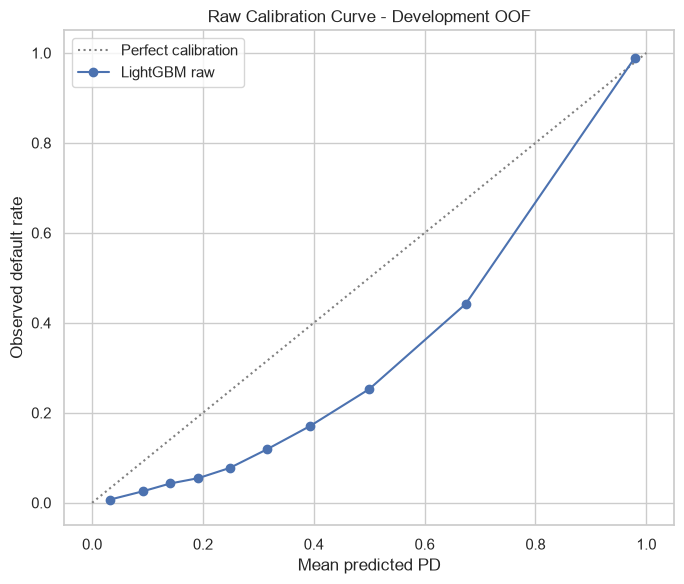

6.1 - RAW CALIBRATION CURVE AND BRIER SCORE


,item,value
0,selected_model_key,lightgbm
1,selected_model_name,LightGBM
2,selected_candidate_id,lightgbm_01
3,calibration_candidate_keys,"[lightgbm, catboost, logistic]"
4,calibration_candidate_count,3
5,raw_prediction_source,lightgbm_tuned_pd
6,development_rows,26064


,model_name,feature_set,roc_auc,pr_auc,ks,gini,brier,model_key,candidate_id,calibration_method,prediction_source
0,LightGBM_tuned_raw,primary_engineered_features,0.8905,0.7976,0.6047,0.7809,0.1139,lightgbm,lightgbm_01,raw,development_oof_cv_from_section_5


,pd_bin,row_count,min_predicted_pd,max_predicted_pd,mean_predicted_pd,observed_default_rate,calibration_error,abs_calibration_error
0,"(0.0028899999999999998, 0.0632]",2607,0.0039,0.0632,0.0318,0.0069,-0.0249,0.0249
1,"(0.0632, 0.117]",2606,0.0632,0.1171,0.0921,0.0257,-0.0664,0.0664
2,"(0.117, 0.166]",2606,0.1171,0.1661,0.1413,0.0430,-0.0983,0.0983
3,"(0.166, 0.219]",2607,0.1661,0.2186,0.1920,0.0549,-0.1371,0.1371
4,"(0.219, 0.281]",2606,0.2187,0.2808,0.2485,0.0775,-0.1710,0.1710
5,"(0.281, 0.352]",2606,0.2808,0.3518,0.3157,0.1190,-0.1967,0.1967
6,"(0.352, 0.438]",2607,0.3518,0.4384,0.3934,0.1707,-0.2227,0.2227
7,"(0.438, 0.567]",2606,0.4384,0.5671,0.5002,0.2529,-0.2473,0.2473
8,"(0.567, 0.839]",2606,0.5671,0.8390,0.6741,0.4421,-0.2321,0.2321
9,"(0.839, 0.998]",2607,0.8391,0.9983,0.9790,0.9889,+0.0098,0.0098



Note:
Cell 6.1 dùng raw out-of-fold predictions từ Section 5 để đánh giá calibration ban đầu trên Development Set. Locked Test chưa được sử dụng.


In [14]:
# 6.1 - Calibration curve và Brier score

# ============================================================
# 1. Guard: dùng output từ Section 5
# ============================================================

required_objects = [
    "X_dev_raw",
    "y_dev",
    "cv_strategy",
    "RANDOM_STATE",
    "tuning_results",
    "selected_params",
    "tuned_model_pipelines",
    "tuning_predictions",
    "build_metric_row",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy Section 5 trước khi calibration. Thiếu: "
        + ", ".join(missing_objects)
    )

selected_tuned_rows = tuning_results[
    tuning_results["selected"].eq(True)
    & tuning_results["status"].eq("success")
].copy()

if selected_tuned_rows.empty:
    raise ValueError(
        "Không có tuned model nào được selected=True trong tuning_results."
    )

selected_tuned_rows = selected_tuned_rows.sort_values(
    by=[
        "rank",
        "mean_roc_auc",
        "mean_pr_auc",
        "mean_brier",
    ],
    ascending=[
        True,
        False,
        False,
        True,
    ],
)

calibration_candidate_rows = selected_tuned_rows.copy()
calibration_candidate_rows = calibration_candidate_rows[
    calibration_candidate_rows["model_key"].isin(selected_params.keys())
].copy()

if calibration_candidate_rows.empty:
    raise ValueError(
        "Không có selected tuned candidate nào có selected_params để calibration."
    )

calibration_candidate_keys = calibration_candidate_rows[
    "model_key"
].tolist()

# Candidate đầu tiên chỉ dùng cho raw calibration preview ở cell 6.1.
# Cell 6.2 sẽ calibrate toàn bộ calibration_candidate_rows.
calibration_model_key = calibration_candidate_rows.iloc[0]["model_key"]
calibration_model_name = calibration_candidate_rows.iloc[0]["model_name"]
calibration_candidate_id = calibration_candidate_rows.iloc[0]["candidate_id"]
calibration_selected_params = selected_params[
    calibration_model_key
]

raw_prediction_col = f"{calibration_model_key}_tuned_pd"

if raw_prediction_col not in tuning_predictions.columns:
    raise KeyError(
        f"Không tìm thấy OOF prediction '{raw_prediction_col}' trong tuning_predictions."
    )

raw_calibration_proba = tuning_predictions[
    raw_prediction_col
].astype(float)

if raw_calibration_proba.isna().any():
    raise ValueError(
        f"Raw OOF predictions còn missing trong {raw_prediction_col}."
    )

if not raw_calibration_proba.index.equals(y_dev.index):
    raise AssertionError(
        "Index raw_calibration_proba và y_dev không khớp."
    )

# ============================================================
# 2. Calibration table helper
# ============================================================

def build_calibration_bin_table(
    y_true,
    y_score,
    n_bins=10,
):
    calibration_frame = pd.DataFrame(
        {
            "y_true": y_true.astype(int),
            "predicted_pd": y_score.astype(float),
        }
    )

    try:
        calibration_frame["pd_bin"] = pd.qcut(
            calibration_frame["predicted_pd"],
            q=n_bins,
            duplicates="drop",
        )
    except ValueError:
        calibration_frame["pd_bin"] = pd.cut(
            calibration_frame["predicted_pd"],
            bins=n_bins,
            include_lowest=True,
            duplicates="drop",
        )

    calibration_table = (
        calibration_frame
        .groupby(
            "pd_bin",
            observed=True,
        )
        .agg(
            row_count=("y_true", "size"),
            min_predicted_pd=("predicted_pd", "min"),
            max_predicted_pd=("predicted_pd", "max"),
            mean_predicted_pd=("predicted_pd", "mean"),
            observed_default_rate=("y_true", "mean"),
        )
        .reset_index()
    )

    calibration_table["calibration_error"] = (
        calibration_table["observed_default_rate"]
        - calibration_table["mean_predicted_pd"]
    )

    calibration_table["abs_calibration_error"] = (
        calibration_table["calibration_error"].abs()
    )

    return calibration_table


def get_calibration_curve_points(
    y_true,
    y_score,
    n_bins=10,
):
    observed_rate, mean_predicted_pd = calibration_curve(
        y_true,
        y_score,
        n_bins=n_bins,
        strategy="quantile",
    )

    return pd.DataFrame(
        {
            "mean_predicted_pd": mean_predicted_pd,
            "observed_default_rate": observed_rate,
        }
    )


# ============================================================
# 3. Raw calibration metrics
# ============================================================

raw_calibration_metrics = build_metric_row(
    model_name=f"{calibration_model_name}_tuned_raw",
    feature_set="primary_engineered_features",
    y_true=y_dev,
    y_score=raw_calibration_proba,
)

raw_calibration_metrics.update({
    "model_key": calibration_model_key,
    "candidate_id": calibration_candidate_id,
    "calibration_method": "raw",
    "prediction_source": "development_oof_cv_from_section_5",
})

calibration_table = build_calibration_bin_table(
    y_true=y_dev,
    y_score=raw_calibration_proba,
    n_bins=10,
)

raw_calibration_curve = get_calibration_curve_points(
    y_true=y_dev,
    y_score=raw_calibration_proba,
    n_bins=10,
)

calibration_candidate_summary = pd.DataFrame([
    {
        "item": "selected_model_key",
        "value": calibration_model_key,
    },
    {
        "item": "selected_model_name",
        "value": calibration_model_name,
    },
    {
        "item": "selected_candidate_id",
        "value": calibration_candidate_id,
    },
    {
        "item": "calibration_candidate_keys",
        "value": calibration_candidate_keys,
    },
    {
        "item": "calibration_candidate_count",
        "value": len(calibration_candidate_rows),
    },
    {
        "item": "raw_prediction_source",
        "value": raw_prediction_col,
    },
    {
        "item": "development_rows",
        "value": len(y_dev),
    },
])

raw_calibration_note = (
    "Cell 6.1 dùng raw out-of-fold predictions từ Section 5 để đánh giá "
    "calibration ban đầu trên Development Set. Locked Test chưa được sử dụng."
)

# ============================================================
# 4. Plot raw calibration curve
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6),
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    color="gray",
    label="Perfect calibration",
)

ax.plot(
    raw_calibration_curve["mean_predicted_pd"],
    raw_calibration_curve["observed_default_rate"],
    marker="o",
    label=f"{calibration_model_name} raw",
)

ax.set_title("Raw Calibration Curve - Development OOF")
ax.set_xlabel("Mean predicted PD")
ax.set_ylabel("Observed default rate")
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 5. Display
# ============================================================

print("=" * 90)
print("6.1 - RAW CALIBRATION CURVE AND BRIER SCORE")
print("=" * 90)

display(calibration_candidate_summary)

display(
    pd.DataFrame([raw_calibration_metrics]).style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
    })
)

display(
    calibration_table.style.format({
        "min_predicted_pd": "{:.4f}",
        "max_predicted_pd": "{:.4f}",
        "mean_predicted_pd": "{:.4f}",
        "observed_default_rate": "{:.4f}",
        "calibration_error": "{:+.4f}",
        "abs_calibration_error": "{:.4f}",
    })
)

print("\nNote:")
print(raw_calibration_note)


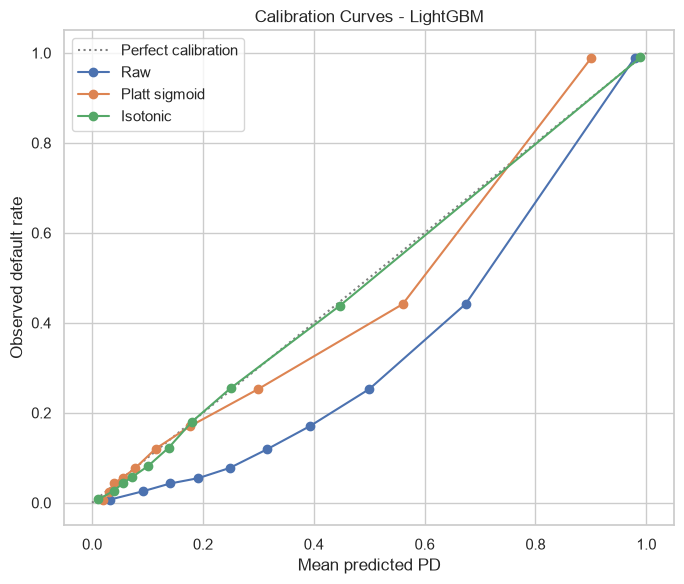

6.2 - RAW VS PLATT VS ISOTONIC CALIBRATION

Selected calibration per model:


,model_key,base_model_name,candidate_id,calibration_method,roc_auc,pr_auc,ks,gini,brier
0,lightgbm,LightGBM,lightgbm_01,isotonic,0.8900,0.7952,0.6031,0.7800,0.0869
1,catboost,CatBoost,catboost_01,isotonic,0.8615,0.7589,0.5532,0.7231,0.0946
2,logistic,LogisticRegression,logistic_01,isotonic,0.8094,0.6241,0.4622,0.6187,0.1230



Method comparison for current best calibrated model:


,model_name,feature_set,roc_auc,pr_auc,ks,gini,brier,model_key,candidate_id,base_model_name,calibration_method,prediction_source,selected,brier_rank,roc_auc_rank
0,LightGBM_tuned_isotonic,primary_engineered_features,0.8900,0.7952,0.6031,0.7800,0.0869,lightgbm,lightgbm_01,LightGBM,isotonic,manual_nested_cv_isotonic,True,1,3
1,LightGBM_tuned_platt,primary_engineered_features,0.8905,0.7977,0.6045,0.7809,0.0894,lightgbm,lightgbm_01,LightGBM,platt,manual_nested_cv_platt,False,2,2
2,LightGBM_tuned_raw,primary_engineered_features,0.8905,0.7976,0.6047,0.7809,0.1139,lightgbm,lightgbm_01,LightGBM,raw,section_5_selected_oof_prediction,False,3,1



Selected calibration method:
isotonic

Selected calibration metrics:
roc_auc: 0.8900
pr_auc: 0.7952
ks: 0.6031
gini: 0.7800
brier: 0.0869

Note:
Calibration method is selected primarily by the lowest Brier Score for each tuned model. Platt and Isotonic are evaluated with manual nested CV on the Development Set; raw probabilities use Section 5 OOF predictions. Locked Test was not used.


In [15]:
# 6.2 - Raw vs Platt vs Isotonic calibration

# ============================================================
# 1. Guard: tiếp nối trực tiếp từ 6.1 và Section 5
# ============================================================

required_objects = [
    "X_dev_raw",
    "y_dev",
    "cv_strategy",
    "RANDOM_STATE",
    "N_SPLITS",
    "calibration_candidate_rows",
    "build_metric_row",
    "positive_class_proba",
    "make_tuning_pipeline",
    "build_calibration_bin_table",
    "get_calibration_curve_points",
    "tuned_model_pipelines",
    "tuning_predictions",
    "model_artifacts",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy cell 6.1 và Section 5 trước. Thiếu: "
        + ", ".join(missing_objects)
    )

if "cv_results_records" not in globals():
    cv_results_records = []

from sklearn.isotonic import IsotonicRegression


class ProbabilityCalibratedPipeline(BaseEstimator):
    """Small fitted wrapper for a base pipeline plus a 1D probability calibrator."""

    _estimator_type = "classifier"

    def __init__(self, base_pipeline, calibration_method="raw", calibrator=None):
        self.base_pipeline = base_pipeline
        self.calibration_method = calibration_method
        self.calibrator = calibrator

    def fit(self, X, y=None):
        self.classes_ = np.asarray([0, 1])
        return self

    def _calibrate(self, raw_pd):
        raw_pd = np.asarray(raw_pd, dtype=float)

        if self.calibration_method == "raw":
            calibrated_pd = raw_pd
        elif self.calibration_method == "platt":
            calibrated_pd = self.calibrator.predict_proba(
                raw_pd.reshape(-1, 1)
            )[:, 1]
        elif self.calibration_method == "isotonic":
            calibrated_pd = self.calibrator.predict(raw_pd)
        else:
            raise ValueError(
                f"Unknown calibration_method: {self.calibration_method}"
            )

        return np.clip(calibrated_pd, 1e-6, 1 - 1e-6)

    def predict_proba(self, X):
        raw_pd = positive_class_proba(
            self.base_pipeline,
            X,
        )
        calibrated_pd = self._calibrate(raw_pd)
        return np.column_stack(
            [
                1 - calibrated_pd,
                calibrated_pd,
            ]
        )

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def fit_probability_calibrator(method_key, raw_pd, y_true):
    raw_values = np.asarray(raw_pd, dtype=float).reshape(-1, 1)
    y_values = np.asarray(y_true, dtype=int)

    if method_key == "platt":
        calibrator = LogisticRegression(
            solver="lbfgs",
            random_state=RANDOM_STATE,
        )
        calibrator.fit(
            raw_values,
            y_values,
        )
        return calibrator

    if method_key == "isotonic":
        calibrator = IsotonicRegression(
            y_min=0.0,
            y_max=1.0,
            out_of_bounds="clip",
        )
        calibrator.fit(
            raw_values.ravel(),
            y_values,
        )
        return calibrator

    if method_key == "raw":
        return None

    raise ValueError(f"Unknown calibration method: {method_key}")


def apply_probability_calibrator(method_key, calibrator, raw_pd):
    raw_values = np.asarray(raw_pd, dtype=float)

    if method_key == "raw":
        calibrated = raw_values
    elif method_key == "platt":
        calibrated = calibrator.predict_proba(
            raw_values.reshape(-1, 1)
        )[:, 1]
    elif method_key == "isotonic":
        calibrated = calibrator.predict(raw_values)
    else:
        raise ValueError(f"Unknown calibration method: {method_key}")

    return np.clip(calibrated, 1e-6, 1 - 1e-6)


def build_inner_oof_raw_predictions(model_key, params, X_train, y_train, inner_cv):
    inner_oof = pd.Series(
        data=np.nan,
        index=y_train.index,
        dtype=float,
    )

    for inner_train_idx, inner_valid_idx in inner_cv.split(
        X_train,
        y_train,
    ):
        inner_pipeline = make_tuning_pipeline(
            model_key=model_key,
            params=params,
        )
        inner_pipeline.fit(
            X_train.iloc[inner_train_idx].copy(),
            y_train.iloc[inner_train_idx].copy(),
        )
        inner_oof.iloc[inner_valid_idx] = positive_class_proba(
            inner_pipeline,
            X_train.iloc[inner_valid_idx].copy(),
        )

    if inner_oof.isna().any():
        raise ValueError(
            f"Inner calibration OOF predictions còn missing cho {model_key}."
        )

    return inner_oof


inner_cv_splits = max(
    2,
    min(
        2,
        N_SPLITS,
    ),
)

calibration_predictions_by_model = {}
calibration_tables_by_model_method = {}
calibration_curves_by_model_method = {}
calibrated_model_artifacts_by_key = {}
selected_calibration_by_model = {}
selected_calibrated_models = {}
calibration_result_records = []

for _, candidate_row in calibration_candidate_rows.iterrows():
    candidate_model_key = candidate_row["model_key"]
    candidate_model_name = candidate_row["model_name"]
    candidate_id = candidate_row["candidate_id"]
    candidate_params = selected_params[candidate_model_key]
    candidate_prediction_col = f"{candidate_model_key}_tuned_pd"

    if candidate_prediction_col not in tuning_predictions.columns:
        raise KeyError(
            f"Không tìm thấy OOF prediction '{candidate_prediction_col}' "
            f"cho calibration candidate {candidate_model_name}."
        )

    candidate_raw_proba = tuning_predictions[
        candidate_prediction_col
    ].astype(float)

    candidate_predictions = pd.DataFrame(
        {
            "y_true": y_dev.astype(int),
            "raw_pd": candidate_raw_proba,
            "platt_pd": np.nan,
            "isotonic_pd": np.nan,
        },
        index=y_dev.index,
    )

    if candidate_predictions["raw_pd"].isna().any():
        raise ValueError(
            f"Raw OOF predictions còn missing trong {candidate_prediction_col}."
        )

    for fold_number, (train_idx, valid_idx) in enumerate(
        cv_strategy.split(
            X_dev_raw,
            y_dev,
        ),
        start=1,
    ):
        X_train_fold = X_dev_raw.iloc[train_idx].copy()
        y_train_fold = y_dev.iloc[train_idx].copy()
        X_valid_fold = X_dev_raw.iloc[valid_idx].copy()

        inner_cv = StratifiedKFold(
            n_splits=inner_cv_splits,
            shuffle=True,
            random_state=RANDOM_STATE + fold_number,
        )

        inner_oof_raw = build_inner_oof_raw_predictions(
            model_key=candidate_model_key,
            params=candidate_params,
            X_train=X_train_fold,
            y_train=y_train_fold,
            inner_cv=inner_cv,
        )

        fold_pipeline = make_tuning_pipeline(
            model_key=candidate_model_key,
            params=candidate_params,
        )
        fold_pipeline.fit(
            X_train_fold,
            y_train_fold,
        )
        raw_valid_pd = positive_class_proba(
            fold_pipeline,
            X_valid_fold,
        )

        for method_key in [
            "platt",
            "isotonic",
        ]:
            fold_calibrator = fit_probability_calibrator(
                method_key=method_key,
                raw_pd=inner_oof_raw,
                y_true=y_train_fold,
            )
            candidate_predictions.iloc[
                valid_idx,
                candidate_predictions.columns.get_loc(f"{method_key}_pd"),
            ] = apply_probability_calibrator(
                method_key=method_key,
                calibrator=fold_calibrator,
                raw_pd=raw_valid_pd,
            )

    missing_prediction_counts = candidate_predictions[
        ["raw_pd", "platt_pd", "isotonic_pd"]
    ].isna().sum()

    if (missing_prediction_counts > 0).any():
        raise ValueError(
            f"Calibration predictions còn missing cho {candidate_model_name}: "
            + str(missing_prediction_counts.to_dict())
        )

    candidate_records = []

    for method_key, prediction_source in [
        ("raw", "section_5_selected_oof_prediction"),
        ("platt", "manual_nested_cv_platt"),
        ("isotonic", "manual_nested_cv_isotonic"),
    ]:
        metric_row = build_metric_row(
            model_name=f"{candidate_model_name}_tuned_{method_key}",
            feature_set="primary_engineered_features",
            y_true=y_dev,
            y_score=candidate_predictions[f"{method_key}_pd"],
        )

        metric_row.update({
            "model_key": candidate_model_key,
            "candidate_id": candidate_id,
            "base_model_name": candidate_model_name,
            "calibration_method": method_key,
            "prediction_source": prediction_source,
            "selected": False,
        })

        candidate_records.append(metric_row)

    candidate_comparison = pd.DataFrame(candidate_records)
    candidate_comparison["brier_rank"] = candidate_comparison["brier"].rank(
        ascending=True,
        method="min",
    )
    candidate_comparison["roc_auc_rank"] = candidate_comparison["roc_auc"].rank(
        ascending=False,
        method="min",
    )
    candidate_comparison = candidate_comparison.sort_values(
        by=["brier", "roc_auc", "pr_auc", "ks"],
        ascending=[True, False, False, False],
    ).reset_index(drop=True)

    candidate_selected_method = candidate_comparison.iloc[0][
        "calibration_method"
    ]
    candidate_comparison["selected"] = candidate_comparison[
        "calibration_method"
    ].eq(candidate_selected_method)

    selected_calibration_by_model[candidate_model_key] = (
        candidate_comparison[candidate_comparison["selected"].eq(True)]
        .iloc[0]
        .to_dict()
    )
    calibration_result_records.extend(
        candidate_comparison.to_dict(orient="records")
    )
    calibration_predictions_by_model[candidate_model_key] = candidate_predictions

    for method_key in ["raw", "platt", "isotonic"]:
        calibration_tables_by_model_method[(candidate_model_key, method_key)] = (
            build_calibration_bin_table(
                y_true=y_dev,
                y_score=candidate_predictions[f"{method_key}_pd"],
                n_bins=10,
            )
        )
        calibration_curves_by_model_method[(candidate_model_key, method_key)] = (
            get_calibration_curve_points(
                y_true=y_dev,
                y_score=candidate_predictions[f"{method_key}_pd"],
                n_bins=10,
            )
        )

    raw_model_full = tuned_model_pipelines.get(candidate_model_key)
    if raw_model_full is None:
        raw_model_full = make_tuning_pipeline(
            model_key=candidate_model_key,
            params=candidate_params,
        )
        raw_model_full.fit(
            X_dev_raw,
            y_dev,
        )

    calibrated_model_artifacts_by_key[candidate_model_key] = {
        "raw": raw_model_full,
    }

    for method_key in ["platt", "isotonic"]:
        full_calibrator = fit_probability_calibrator(
            method_key=method_key,
            raw_pd=candidate_raw_proba,
            y_true=y_dev,
        )
        calibrated_model_artifacts_by_key[candidate_model_key][method_key] = (
            ProbabilityCalibratedPipeline(
                base_pipeline=raw_model_full,
                calibration_method=method_key,
                calibrator=full_calibrator,
            ).fit(None, None)
        )

    selected_calibrated_models[candidate_model_key] = (
        calibrated_model_artifacts_by_key[candidate_model_key][
            candidate_selected_method
        ]
    )

calibration_results = pd.DataFrame(calibration_result_records)

if calibration_results.empty:
    raise ValueError("Không tạo được calibration_results cho candidate nào.")

selected_calibration_results = calibration_results[
    calibration_results["selected"].eq(True)
].copy()
selected_calibration_results = selected_calibration_results.sort_values(
    by=["brier", "roc_auc", "pr_auc", "ks"],
    ascending=[True, False, False, False],
).reset_index(drop=True)

best_calibrated_row = selected_calibration_results.iloc[0].to_dict()

# Backward-compatible aliases. Section 7 may overwrite these aliases after it
# chooses the final champion from all calibrated candidates.
calibration_model_key = best_calibrated_row["model_key"]
calibration_model_name = best_calibrated_row["base_model_name"]
calibration_candidate_id = best_calibrated_row["candidate_id"]
calibration_selected_params = selected_params[calibration_model_key]
selected_calibration_method = best_calibrated_row["calibration_method"]
selected_calibration_metrics = best_calibrated_row
selected_calibrated_model = selected_calibrated_models[calibration_model_key]
final_calibrated_model = selected_calibrated_model

calibration_predictions = calibration_predictions_by_model[
    calibration_model_key
].copy()
selected_calibrated_proba = calibration_predictions[
    f"{selected_calibration_method}_pd"
].copy()
calibration_comparison = calibration_results[
    calibration_results["model_key"].eq(calibration_model_key)
].copy().reset_index(drop=True)

calibration_tables_by_method = {
    method_key: calibration_tables_by_model_method[
        (calibration_model_key, method_key)
    ]
    for method_key in ["raw", "platt", "isotonic"]
}
calibration_curves = {
    method_key: calibration_curves_by_model_method[
        (calibration_model_key, method_key)
    ]
    for method_key in ["raw", "platt", "isotonic"]
}
calibrated_model_artifacts = calibrated_model_artifacts_by_key[
    calibration_model_key
]

model_artifacts["calibration"] = {
    "base_model_key": calibration_model_key,
    "base_model_name": calibration_model_name,
    "selected_calibration_method": selected_calibration_method,
    "models": calibrated_model_artifacts,
    "models_by_candidate": calibrated_model_artifacts_by_key,
    "selected_models_by_candidate": selected_calibrated_models,
    "fit_data": "development_set_only",
}

selected_calibrated_names = {
    f"{row['base_model_name']}_calibrated_selected"
    for _, row in selected_calibration_results.iterrows()
}
cv_results_records = [
    row
    for row in cv_results_records
    if row.get("model_name") not in selected_calibrated_names
]

for _, row in selected_calibration_results.iterrows():
    cv_results_records.append({
        "model_name": f"{row['base_model_name']}_calibrated_selected",
        "feature_set": "primary_engineered_features",
        "roc_auc": row["roc_auc"],
        "pr_auc": row["pr_auc"],
        "ks": row["ks"],
        "gini": row["gini"],
        "brier": row["brier"],
        "stage": "probability_calibration",
        "evaluation_data": "development_outer_cv",
        "calibration": row["calibration_method"],
        "notes": (
            "Selected calibration method for this model from Section 6; "
            "fit uses Development Set only."
        ),
    })

cv_results = pd.DataFrame(cv_results_records)

calibration_candidate_table = selected_calibration_results[
    [
        "model_key",
        "base_model_name",
        "candidate_id",
        "calibration_method",
        "roc_auc",
        "pr_auc",
        "ks",
        "gini",
        "brier",
    ]
].copy()

calibration_selection_note = (
    "Calibration method is selected primarily by the lowest Brier Score for each "
    "tuned model. Platt and Isotonic are evaluated with manual nested CV on the "
    "Development Set; raw probabilities use Section 5 OOF predictions. Locked "
    "Test was not used."
)

# ============================================================
# 6. Plot Raw vs Platt vs Isotonic for current best calibrated model
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6),
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    color="gray",
    label="Perfect calibration",
)

for method_key, label in [
    ("raw", "Raw"),
    ("platt", "Platt sigmoid"),
    ("isotonic", "Isotonic"),
]:
    curve_data = calibration_curves[method_key]
    ax.plot(
        curve_data["mean_predicted_pd"],
        curve_data["observed_default_rate"],
        marker="o",
        label=label,
    )

ax.set_title(f"Calibration Curves - {calibration_model_name}")
ax.set_xlabel("Mean predicted PD")
ax.set_ylabel("Observed default rate")
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 7. Display
# ============================================================

print("=" * 90)
print("6.2 - RAW VS PLATT VS ISOTONIC CALIBRATION")
print("=" * 90)

print("\nSelected calibration per model:")
display(
    calibration_candidate_table.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
    })
)

print("\nMethod comparison for current best calibrated model:")
display(
    calibration_comparison.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
        "brier_rank": "{:.0f}",
        "roc_auc_rank": "{:.0f}",
    })
)

print("\nSelected calibration method:")
print(selected_calibration_method)

print("\nSelected calibration metrics:")
for metric_name in [
    "roc_auc",
    "pr_auc",
    "ks",
    "gini",
    "brier",
]:
    print(f"{metric_name}: {selected_calibration_metrics[metric_name]:.4f}")

print("\nNote:")
print(calibration_selection_note)


## Section 7 - Champion Candidate Selection

Select champion after model comparison, tuning, leakage ablation review, and calibration.

In [16]:
# 7.1 - Chọn champion candidate

# ============================================================
# 1. Guard: dùng output từ Section 0-6
# ============================================================

required_objects = [
    "primary_feature_cols",
    "extended_only_cols",
    "audit_only_cols",
    "tuning_results",
    "selected_params",
    "tuned_model_pipelines",
    "calibration_model_key",
    "calibration_model_name",
    "calibration_selected_params",
    "selected_calibration_method",
    "selected_calibration_metrics",
    "selected_calibrated_model",
    "calibration_comparison",
    "model_artifacts",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy đầy đủ Section 0 đến Section 6 trước khi chọn champion. Thiếu: "
        + ", ".join(missing_objects)
    )

if not hasattr(selected_calibrated_model, "predict_proba"):
    raise TypeError(
        "selected_calibrated_model phải là probability model có predict_proba()."
    )

selected_calibration_rows = calibration_comparison[
    calibration_comparison["selected"].eq(True)
]

if selected_calibration_rows.empty:
    raise ValueError(
        "calibration_comparison không có dòng selected=True."
    )

if (
    selected_calibration_rows.iloc[0]["calibration_method"]
    != selected_calibration_method
):
    raise AssertionError(
        "selected_calibration_method không khớp với calibration_comparison."
    )

if selected_params.get(calibration_model_key) != calibration_selected_params:
    raise AssertionError(
        "calibration_selected_params không khớp selected_params từ Section 5."
    )

known_leakage_candidates = [
    col
    for col in [
        "loan_grade",
        "loan_int_rate",
    ]
    if col in extended_only_cols or col in primary_feature_cols
]

primary_leakage_overlap = sorted(
    set(primary_feature_cols)
    & set(known_leakage_candidates)
)

if primary_leakage_overlap:
    raise AssertionError(
        "Primary Feature Set đang chứa leakage candidates: "
        + ", ".join(primary_leakage_overlap)
    )

primary_audit_overlap = sorted(
    set(primary_feature_cols)
    & set(audit_only_cols)
)

if primary_audit_overlap:
    raise AssertionError(
        "Primary Feature Set đang chứa audit-only variables: "
        + ", ".join(primary_audit_overlap)
    )

# ============================================================
# 2. Helper đánh giá qualitative constraints
# ============================================================

core_model_order = [
    "logistic",
    "lightgbm",
    "catboost",
]

model_key_to_family = {
    "logistic": "Logistic Regression",
    "lightgbm": "LightGBM",
    "catboost": "CatBoost",
}

model_key_to_display_name = {
    "logistic": "LogisticRegression",
    "lightgbm": "LightGBM",
    "catboost": "CatBoost",
}

explainability_map = {
    "logistic": "excellent",
    "lightgbm": "good_with_shap",
    "catboost": "good_with_shap",
}

deployment_simplicity_map = {
    "logistic": "high",
    "lightgbm": "medium_high",
    "catboost": "medium",
}

quality_score_map = {
    "excellent": 1,
    "good_with_shap": 2,
    "high": 1,
    "medium_high": 2,
    "medium": 3,
    "low": 4,
    "unknown": 5,
}


def get_best_tuning_row(model_key):
    model_rows = tuning_results[
        tuning_results["model_key"].eq(model_key)
    ].copy()

    if model_rows.empty:
        return None

    selected_rows = model_rows[
        model_rows["selected"].eq(True)
    ].copy()

    if not selected_rows.empty:
        return selected_rows.iloc[0]

    success_rows = model_rows[
        model_rows["status"].eq("success")
    ].copy()

    if success_rows.empty:
        return model_rows.iloc[0]

    success_rows = success_rows.sort_values(
        by=[
            "rank",
            "mean_roc_auc",
            "mean_pr_auc",
            "mean_brier",
        ],
        ascending=[
            True,
            False,
            False,
            True,
        ],
    )

    return success_rows.iloc[0]


def format_exclusion_reasons(reasons):
    clean_reasons = [
        reason
        for reason in reasons
        if reason
    ]

    if not clean_reasons:
        return ""

    return "; ".join(clean_reasons)


def calibration_quality_from_brier(brier_value):
    if pd.isna(brier_value):
        return "unknown"
    if brier_value <= 0.10:
        return "strong"
    if brier_value <= 0.15:
        return "acceptable"
    return "needs_review"


# ============================================================
# 3. Build champion candidate table
# ============================================================

candidate_records = []

for model_key in core_model_order:
    tuning_row = get_best_tuning_row(
        model_key
    )

    model_name = model_key_to_display_name[
        model_key
    ]

    if tuning_row is None:
        candidate_records.append({
            "model_key": model_key,
            "model_name": model_name,
            "model_family": model_key_to_family[model_key],
            "feature_set": "primary_engineered_features",
            "tuning_status": "missing",
            "selected_params": {},
            "calibration_method": "not_available",
            "roc_auc": np.nan,
            "pr_auc": np.nan,
            "ks": np.nan,
            "gini": np.nan,
            "brier": np.nan,
            "roc_auc_std": np.nan,
            "pr_auc_std": np.nan,
            "stability_note": "No tuning result found.",
            "leakage_risk": "low",
            "explainability": explainability_map[model_key],
            "deployment_simplicity": deployment_simplicity_map[model_key],
            "calibration_quality": "unknown",
            "status": "excluded",
            "eligible_for_champion": False,
            "exclusion_reason": "No tuning result found.",
        })
        continue

    tuning_status = tuning_row.get(
        "status",
        "unknown",
    )

    params = selected_params.get(
        model_key,
        tuning_row.get(
            "params",
            {},
        ),
    )

    model_calibration_metrics = (
        selected_calibration_by_model.get(model_key)
        if "selected_calibration_by_model" in globals()
        else None
    )

    if model_calibration_metrics is not None:
        metrics_source = model_calibration_metrics
        calibration_method = metrics_source.get(
            "calibration_method",
            "unknown",
        )
        calibration_quality = calibration_quality_from_brier(
            metrics_source.get(
                "brier",
                np.nan,
            )
        )
        status = "success"
        stability_note = (
            "Uses Section 5 tuned CV std and Section 6 selected calibration metrics "
            "for this specific model."
        )
    else:
        metrics_source = tuning_row
        calibration_method = "not_calibrated_in_section_6"
        calibration_quality = "missing_calibration_result"
        status = "excluded"
        stability_note = (
            "Tuned metric exists, but Section 6 calibration artifact was not created for this model."
        )

    candidate_record = {
        "model_key": model_key,
        "model_name": model_name,
        "model_family": model_key_to_family[model_key],
        "feature_set": "primary_engineered_features",
        "tuning_status": tuning_status,
        "selected_params": params,
        "calibration_method": calibration_method,
        "roc_auc": metrics_source.get(
            "roc_auc",
            metrics_source.get(
                "mean_roc_auc",
                np.nan,
            ),
        ),
        "pr_auc": metrics_source.get(
            "pr_auc",
            metrics_source.get(
                "mean_pr_auc",
                np.nan,
            ),
        ),
        "ks": metrics_source.get(
            "ks",
            metrics_source.get(
                "mean_ks",
                np.nan,
            ),
        ),
        "gini": metrics_source.get(
            "gini",
            np.nan,
        ),
        "brier": metrics_source.get(
            "brier",
            metrics_source.get(
                "mean_brier",
                np.nan,
            ),
        ),
        "roc_auc_std": tuning_row.get(
            "std_roc_auc",
            np.nan,
        ),
        "pr_auc_std": tuning_row.get(
            "std_pr_auc",
            np.nan,
        ),
        "stability_note": stability_note,
        "leakage_risk": "low",
        "explainability": explainability_map[model_key],
        "deployment_simplicity": deployment_simplicity_map[model_key],
        "calibration_quality": calibration_quality,
        "status": status,
    }

    exclusion_reasons = []

    if tuning_status != "success":
        exclusion_reasons.append(
            f"tuning_status={tuning_status}"
        )

    if candidate_record["feature_set"] != "primary_engineered_features":
        exclusion_reasons.append(
            "not_primary_feature_set"
        )

    if candidate_record["leakage_risk"] != "low":
        exclusion_reasons.append(
            f"leakage_risk={candidate_record['leakage_risk']}"
        )

    if calibration_method == "not_calibrated_in_section_6":
        exclusion_reasons.append(
            "missing_selected_calibration_result"
        )

    metric_cols = [
        "roc_auc",
        "pr_auc",
        "ks",
        "gini",
        "brier",
    ]

    missing_metric_cols = [
        col
        for col in metric_cols
        if pd.isna(
            candidate_record[col]
        )
    ]

    if missing_metric_cols:
        exclusion_reasons.append(
            "missing_metrics="
            + ",".join(missing_metric_cols)
        )

    candidate_record["eligible_for_champion"] = (
        len(exclusion_reasons) == 0
    )

    candidate_record["exclusion_reason"] = format_exclusion_reasons(
        exclusion_reasons
    )

    candidate_records.append(
        candidate_record
    )

champion_candidate_table = pd.DataFrame(
    candidate_records
)

# ============================================================
# 4. Champion ranking
# ============================================================

rank_metric_cols = [
    "roc_auc",
    "pr_auc",
    "ks",
    "brier",
    "roc_auc_std",
]

eligible_mask = champion_candidate_table[
    "eligible_for_champion"
].eq(True)

for rank_col in [
    "roc_auc_rank",
    "pr_auc_rank",
    "ks_rank",
    "brier_rank",
    "stability_rank",
]:
    champion_candidate_table[rank_col] = np.nan

if eligible_mask.any():
    eligible_candidates = champion_candidate_table.loc[
        eligible_mask
    ].copy()

    eligible_candidates["roc_auc_rank"] = eligible_candidates[
        "roc_auc"
    ].rank(
        ascending=False,
        method="min",
    )

    eligible_candidates["pr_auc_rank"] = eligible_candidates[
        "pr_auc"
    ].rank(
        ascending=False,
        method="min",
    )

    eligible_candidates["ks_rank"] = eligible_candidates[
        "ks"
    ].rank(
        ascending=False,
        method="min",
    )

    eligible_candidates["brier_rank"] = eligible_candidates[
        "brier"
    ].rank(
        ascending=True,
        method="min",
    )

    if eligible_candidates["roc_auc_std"].notna().any():
        eligible_candidates["stability_rank"] = eligible_candidates[
            "roc_auc_std"
        ].rank(
            ascending=True,
            method="min",
        )
    else:
        eligible_candidates["stability_rank"] = 1.0

    eligible_candidates["mean_rank"] = eligible_candidates[
        [
            "roc_auc_rank",
            "pr_auc_rank",
            "ks_rank",
            "brier_rank",
            "stability_rank",
        ]
    ].mean(axis=1)

    eligible_candidates["explainability_rank"] = eligible_candidates[
        "explainability"
    ].map(
        quality_score_map
    ).fillna(
        quality_score_map["unknown"]
    )

    eligible_candidates["deployment_rank"] = eligible_candidates[
        "deployment_simplicity"
    ].map(
        quality_score_map
    ).fillna(
        quality_score_map["unknown"]
    )

    eligible_candidates = eligible_candidates.sort_values(
        by=[
            "mean_rank",
            "brier",
            "roc_auc",
            "pr_auc",
            "ks",
            "roc_auc_std",
            "explainability_rank",
            "deployment_rank",
        ],
        ascending=[
            True,
            True,
            False,
            False,
            False,
            True,
            True,
            True,
        ],
    )

    champion_candidate_table.loc[
        eligible_candidates.index,
        [
            "roc_auc_rank",
            "pr_auc_rank",
            "ks_rank",
            "brier_rank",
            "stability_rank",
            "mean_rank",
        ],
    ] = eligible_candidates[
        [
            "roc_auc_rank",
            "pr_auc_rank",
            "ks_rank",
            "brier_rank",
            "stability_rank",
            "mean_rank",
        ]
    ]

else:
    raise ValueError(
        "Không có candidate nào đủ điều kiện champion sau Section 6."
    )

champion_candidate_table["selection_rank"] = np.nan
ranked_eligible_index = eligible_candidates.index.tolist()

champion_candidate_table.loc[
    ranked_eligible_index,
    "selection_rank",
] = np.arange(
    1,
    len(ranked_eligible_index) + 1,
)

champion_candidate_table = champion_candidate_table.sort_values(
    by=[
        "eligible_for_champion",
        "selection_rank",
        "model_name",
    ],
    ascending=[
        False,
        True,
        True,
    ],
).reset_index(drop=True)

# ============================================================
# 5. Select champion candidate
# ============================================================

champion_row = champion_candidate_table[
    champion_candidate_table["eligible_for_champion"].eq(True)
].iloc[0]

champion_candidate_name = champion_row["model_name"]
champion_candidate_model_key = champion_row["model_key"]

if champion_candidate_model_key not in selected_calibrated_models:
    raise AssertionError(
        "Champion model_key không có calibrated model artifact từ Section 6."
    )

champion_candidate_pipeline = selected_calibrated_models[
    champion_candidate_model_key
]

# Backward-compatible aliases for Sections 8-11 now point to the actual
# champion, not merely the first calibrated candidate.
calibration_model_key = champion_candidate_model_key
calibration_model_name = champion_candidate_name
selected_calibration_method = champion_row["calibration_method"]
selected_calibration_metrics = selected_calibration_by_model[
    champion_candidate_model_key
]
selected_calibrated_model = champion_candidate_pipeline
final_calibrated_model = champion_candidate_pipeline
calibration_predictions = calibration_predictions_by_model[
    champion_candidate_model_key
].copy()
selected_calibrated_proba = calibration_predictions[
    f"{selected_calibration_method}_pd"
].copy()
calibration_comparison = calibration_results[
    calibration_results["model_key"].eq(champion_candidate_model_key)
].copy().reset_index(drop=True)

if "dummy" in champion_candidate_name.lower():
    raise AssertionError(
        "Dummy Classifier không được chọn làm Champion Candidate."
    )

if champion_row["feature_set"] != "primary_engineered_features":
    raise AssertionError(
        "Champion Candidate phải dùng Primary Feature Set."
    )

if champion_row["leakage_risk"] != "low":
    raise AssertionError(
        "Champion Candidate có leakage risk không thấp."
    )

if pd.isna(
    champion_row[
        [
            "roc_auc",
            "pr_auc",
            "ks",
            "gini",
            "brier",
        ]
    ]
).any():
    raise AssertionError(
        "Champion Candidate còn metric NaN."
    )

if not hasattr(champion_candidate_pipeline, "predict_proba"):
    raise TypeError(
        "champion_candidate_pipeline phải hỗ trợ predict_proba()."
    )

if champion_candidate_model_key not in selected_params:
    raise AssertionError(
        "Champion selected params không tồn tại trong selected_params."
    )

not_selected_candidates = champion_candidate_table[
    ~champion_candidate_table["model_key"].eq(
        champion_candidate_model_key
    )
].copy()

not_selected_reason_parts = []

for _, row in not_selected_candidates.iterrows():
    if row["exclusion_reason"]:
        reason = row["exclusion_reason"]
    else:
        reason = (
            f"rank thấp hơn champion "
            f"(mean_rank={row.get('mean_rank', np.nan)})"
        )

    not_selected_reason_parts.append(
        f"{row['model_name']}: {reason}"
    )

champion_selection_reason = (
    f"{champion_candidate_name} được chọn vì là candidate đủ điều kiện có "
    f"mean_rank tốt nhất trên Development/CV sau tuning và calibration. "
    f"Metrics: ROC-AUC={champion_row['roc_auc']:.4f}, "
    f"PR-AUC={champion_row['pr_auc']:.4f}, "
    f"KS={champion_row['ks']:.4f}, "
    f"Gini={champion_row['gini']:.4f}, "
    f"Brier={champion_row['brier']:.4f}. "
    f"Calibration method={selected_calibration_method}; "
    "feature set=Primary application-time features; "
    f"leakage risk={champion_row['leakage_risk']}; "
    f"explainability={champion_row['explainability']}; "
    f"deployment simplicity={champion_row['deployment_simplicity']}."
)

if not_selected_reason_parts:
    champion_selection_reason += (
        " Candidate khác không được chọn: "
        + " | ".join(not_selected_reason_parts)
        + "."
    )

champion_selection_note = champion_selection_reason

champion_selection_summary = pd.DataFrame([
    {
        "selected_model": champion_candidate_name,
        "model_key": champion_candidate_model_key,
        "feature_set": "Primary",
        "selected_params": selected_params[
            champion_candidate_model_key
        ],
        "calibration_method": selected_calibration_method,
        "roc_auc": champion_row["roc_auc"],
        "pr_auc": champion_row["pr_auc"],
        "ks": champion_row["ks"],
        "gini": champion_row["gini"],
        "brier": champion_row["brier"],
        "leakage_risk": champion_row["leakage_risk"],
        "explainability": champion_row["explainability"],
        "deployment_simplicity": champion_row["deployment_simplicity"],
        "selection_reason": champion_selection_reason,
    }
])

model_artifacts["champion_candidate"] = {
    "model": champion_candidate_pipeline,
    "model_key": champion_candidate_model_key,
    "model_name": champion_candidate_name,
    "feature_set": "primary_engineered_features",
    "selected_params": selected_params[
        champion_candidate_model_key
    ],
    "calibration_method": selected_calibration_method,
    "source": "Section 7 champion selection",
    "fit_data": "development_set_only",
}

# ============================================================
# 6. Display
# ============================================================

print("=" * 90)
print("CHAMPION CANDIDATE SELECTION")
print("=" * 90)

display_columns = [
    "selection_rank",
    "eligible_for_champion",
    "model_name",
    "model_family",
    "feature_set",
    "tuning_status",
    "selected_params",
    "calibration_method",
    "roc_auc",
    "pr_auc",
    "ks",
    "gini",
    "brier",
    "roc_auc_std",
    "pr_auc_std",
    "roc_auc_rank",
    "pr_auc_rank",
    "ks_rank",
    "brier_rank",
    "stability_rank",
    "mean_rank",
    "leakage_risk",
    "explainability",
    "deployment_simplicity",
    "calibration_quality",
    "status",
    "exclusion_reason",
    "stability_note",
]

display(
    champion_candidate_table[
        display_columns
    ].style.format({
        "selection_rank": "{:.0f}",
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
        "roc_auc_std": "{:.4f}",
        "pr_auc_std": "{:.4f}",
        "roc_auc_rank": "{:.0f}",
        "pr_auc_rank": "{:.0f}",
        "ks_rank": "{:.0f}",
        "brier_rank": "{:.0f}",
        "stability_rank": "{:.0f}",
        "mean_rank": "{:.2f}",
    })
)

display(
    champion_selection_summary.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
    })
)

print("\nChampion Candidate:")
print(champion_candidate_name)

print("\nCalibration:")
print(selected_calibration_method)

print("\nFeature Set:")
print("Primary")

print("\nSelection Note:")
print(champion_selection_note)

print(
    "\nChampion Candidate was selected using Development Set / CV results only. "
    "Locked Test has NOT been used."
)


CHAMPION CANDIDATE SELECTION


,selection_rank,eligible_for_champion,model_name,model_family,feature_set,tuning_status,selected_params,calibration_method,roc_auc,pr_auc,ks,gini,brier,roc_auc_std,pr_auc_std,roc_auc_rank,pr_auc_rank,ks_rank,brier_rank,stability_rank,mean_rank,leakage_risk,explainability,deployment_simplicity,calibration_quality,status,exclusion_reason,stability_note
0,1,True,LightGBM,LightGBM,primary_engineered_features,success,"{'model__colsample_bytree': 0.85, 'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 40, 'model__n_estimators': 150, 'model__num_leaves': 31, 'model__subsample': 0.85}",isotonic,0.8900,0.7952,0.6031,0.7800,0.0869,0.0046,0.0064,1,1,1,1,2,1.20,low,good_with_shap,medium_high,strong,success,,Uses Section 5 tuned CV std and Section 6 selected calibration metrics for this specific model.
1,2,True,CatBoost,CatBoost,primary_engineered_features,success,"{'model__depth': 5, 'model__iterations': 120, 'model__l2_leaf_reg': 3.0, 'model__learning_rate': 0.05, 'model__random_strength': 1.0}",isotonic,0.8615,0.7589,0.5532,0.7231,0.0946,0.0037,0.0063,2,2,2,2,1,1.80,low,good_with_shap,medium,strong,success,,Uses Section 5 tuned CV std and Section 6 selected calibration metrics for this specific model.
2,3,True,LogisticRegression,Logistic Regression,primary_engineered_features,success,"{'model__C': 1.0, 'model__class_weight': 'balanced'}",isotonic,0.8094,0.6241,0.4622,0.6187,0.1230,0.0047,0.0155,3,3,3,3,3,3.00,low,excellent,high,acceptable,success,,Uses Section 5 tuned CV std and Section 6 selected calibration metrics for this specific model.


,selected_model,model_key,feature_set,selected_params,calibration_method,roc_auc,pr_auc,ks,gini,brier,leakage_risk,explainability,deployment_simplicity,selection_reason
0,LightGBM,lightgbm,Primary,"{'model__colsample_bytree': 0.85, 'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 40, 'model__n_estimators': 150, 'model__num_leaves': 31, 'model__subsample': 0.85}",isotonic,0.8900,0.7952,0.6031,0.7800,0.0869,low,good_with_shap,medium_high,"LightGBM được chọn vì là candidate đủ điều kiện có mean_rank tốt nhất trên Development/CV sau tuning và calibration. Metrics: ROC-AUC=0.8900, PR-AUC=0.7952, KS=0.6031, Gini=0.7800, Brier=0.0869. Calibration method=isotonic; feature set=Primary application-time features; leakage risk=low; explainability=good_with_shap; deployment simplicity=medium_high. Candidate khác không được chọn: CatBoost: rank thấp hơn champion (mean_rank=1.8) | LogisticRegression: rank thấp hơn champion (mean_rank=3.0)."



Champion Candidate:
LightGBM

Calibration:
isotonic

Feature Set:
Primary

Selection Note:
LightGBM được chọn vì là candidate đủ điều kiện có mean_rank tốt nhất trên Development/CV sau tuning và calibration. Metrics: ROC-AUC=0.8900, PR-AUC=0.7952, KS=0.6031, Gini=0.7800, Brier=0.0869. Calibration method=isotonic; feature set=Primary application-time features; leakage risk=low; explainability=good_with_shap; deployment simplicity=medium_high. Candidate khác không được chọn: CatBoost: rank thấp hơn champion (mean_rank=1.8) | LogisticRegression: rank thấp hơn champion (mean_rank=3.0).

Champion Candidate was selected using Development Set / CV results only. Locked Test has NOT been used.


## Section 8 - Threshold, Credit Score, Risk Grade và Decision Policy

Use calibrated Development PD only. Freeze policy before opening Locked Test.

In [17]:
# 8.1 - Threshold analysis trên calibrated development PD

# ============================================================
# 1. Guard: dùng calibrated OOF PD từ Section 6
# ============================================================

required_objects = [
    "y_dev",
    "calibration_predictions",
    "selected_calibration_method",
    "champion_candidate_name",
    "champion_candidate_pipeline",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy Section 6 và Section 7 trước khi phân tích threshold. Thiếu: "
        + ", ".join(missing_objects)
    )

selected_pd_col = f"{selected_calibration_method}_pd"

if selected_pd_col not in calibration_predictions.columns:
    raise KeyError(
        f"Không tìm thấy calibrated PD column '{selected_pd_col}' trong calibration_predictions."
    )

development_policy_frame = pd.DataFrame(
    {
        "y_true": y_dev.astype(int),
        "calibrated_pd": calibration_predictions[
            selected_pd_col
        ].astype(float),
    },
    index=y_dev.index,
)

if development_policy_frame["calibrated_pd"].isna().any():
    raise ValueError(
        "calibrated_pd có missing value trên Development Set."
    )

if not development_policy_frame["calibrated_pd"].between(0, 1).all():
    raise ValueError(
        "calibrated_pd phải nằm trong [0, 1]."
    )

total_applicants = len(
    development_policy_frame
)
total_defaults = int(
    development_policy_frame["y_true"].sum()
)
total_non_defaults = total_applicants - total_defaults

if total_defaults == 0 or total_non_defaults == 0:
    raise ValueError(
        "Development Set cần có đủ cả good và bad cases để phân tích threshold."
    )

# ============================================================
# 2. Binary high-risk threshold sweep
# ============================================================

fixed_thresholds = np.linspace(
    0.02,
    0.98,
    49,
)

quantile_thresholds = development_policy_frame[
    "calibrated_pd"
].quantile(
    np.linspace(
        0.05,
        0.95,
        19,
    )
).to_numpy()

threshold_grid = np.unique(
    np.clip(
        np.concatenate(
            [
                fixed_thresholds,
                quantile_thresholds,
            ]
        ),
        0,
        1,
    )
)


def safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan
    return numerator / denominator


threshold_records = []

for threshold in threshold_grid:
    predicted_high_risk = (
        development_policy_frame["calibrated_pd"]
        >= threshold
    )

    predicted_approved = ~predicted_high_risk

    tp = int(
        (
            predicted_high_risk
            & development_policy_frame["y_true"].eq(1)
        ).sum()
    )
    fp = int(
        (
            predicted_high_risk
            & development_policy_frame["y_true"].eq(0)
        ).sum()
    )
    fn = int(
        (
            predicted_approved
            & development_policy_frame["y_true"].eq(1)
        ).sum()
    )
    tn = int(
        (
            predicted_approved
            & development_policy_frame["y_true"].eq(0)
        ).sum()
    )

    predicted_high_risk_count = int(
        predicted_high_risk.sum()
    )
    approved_count = int(
        predicted_approved.sum()
    )

    precision = safe_divide(
        tp,
        tp + fp,
    )
    recall = safe_divide(
        tp,
        tp + fn,
    )
    specificity = safe_divide(
        tn,
        tn + fp,
    )

    threshold_records.append({
        "threshold": float(threshold),
        "predicted_high_risk_count": predicted_high_risk_count,
        "predicted_high_risk_rate": predicted_high_risk_count / total_applicants,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": safe_divide(
            2 * precision * recall,
            precision + recall,
        ) if not pd.isna(precision) and not pd.isna(recall) else np.nan,
        "captured_default_rate": safe_divide(
            tp,
            total_defaults,
        ),
        "false_positive_rate": safe_divide(
            fp,
            total_non_defaults,
        ),
        "approved_count": approved_count,
        "approval_rate": approved_count / total_applicants,
        "bad_rate_among_approved": safe_divide(
            fn,
            approved_count,
        ),
    })

threshold_analysis_table = pd.DataFrame(
    threshold_records
).sort_values(
    by="threshold"
).reset_index(drop=True)

# ============================================================
# 3. Three-way decision threshold candidates
# ============================================================

policy_quantile_values = development_policy_frame[
    "calibrated_pd"
].quantile(
    [
        0.10,
        0.20,
        0.30,
        0.40,
        0.50,
        0.60,
        0.70,
        0.80,
        0.90,
    ]
).to_numpy()

policy_threshold_grid = np.unique(
    np.clip(
        policy_quantile_values,
        0,
        1,
    )
)

decision_candidate_records = []

for approve_threshold in policy_threshold_grid:
    for reject_threshold in policy_threshold_grid:
        if approve_threshold >= reject_threshold:
            continue

        approve_mask = (
            development_policy_frame["calibrated_pd"]
            < approve_threshold
        )
        review_mask = (
            development_policy_frame["calibrated_pd"].ge(
                approve_threshold
            )
            & development_policy_frame["calibrated_pd"].lt(
                reject_threshold
            )
        )
        reject_mask = (
            development_policy_frame["calibrated_pd"]
            >= reject_threshold
        )

        approval_count = int(approve_mask.sum())
        review_count = int(review_mask.sum())
        rejection_count = int(reject_mask.sum())

        approved_defaults = int(
            development_policy_frame.loc[
                approve_mask,
                "y_true",
            ].sum()
        )
        review_defaults = int(
            development_policy_frame.loc[
                review_mask,
                "y_true",
            ].sum()
        )
        rejected_defaults = int(
            development_policy_frame.loc[
                reject_mask,
                "y_true",
            ].sum()
        )

        rate_sum = (
            approval_count
            + review_count
            + rejection_count
        ) / total_applicants

        decision_candidate_records.append({
            "approve_threshold": float(approve_threshold),
            "reject_threshold": float(reject_threshold),
            "approval_count": approval_count,
            "approval_rate": approval_count / total_applicants,
            "review_count": review_count,
            "review_rate": review_count / total_applicants,
            "rejection_count": rejection_count,
            "rejection_rate": rejection_count / total_applicants,
            "bad_rate_among_approved": safe_divide(
                approved_defaults,
                approval_count,
            ),
            "captured_default_rate": safe_divide(
                review_defaults + rejected_defaults,
                total_defaults,
            ),
            "rejected_default_capture_rate": safe_divide(
                rejected_defaults,
                total_defaults,
            ),
            "default_rate_in_review": safe_divide(
                review_defaults,
                review_count,
            ),
            "default_rate_in_reject": safe_divide(
                rejected_defaults,
                rejection_count,
            ),
            "rate_sum": rate_sum,
        })

decision_threshold_candidates = pd.DataFrame(
    decision_candidate_records
)

if decision_threshold_candidates.empty:
    raise ValueError(
        "Không tạo được candidate policy nào với approve_threshold < reject_threshold."
    )

if not np.allclose(
    decision_threshold_candidates["rate_sum"],
    1.0,
    atol=1e-9,
):
    raise AssertionError(
        "approval_rate + review_rate + rejection_rate không bằng 1 trong một số policy candidate."
    )

threshold_analysis_note = (
    "Cell 8.1 chỉ dùng calibrated out-of-fold PD từ Development Set. "
    "Binary threshold sweep xem cutoff high-risk/reject; three-way candidates "
    "dùng approve_threshold và reject_threshold để chia APPROVE, MANUAL_REVIEW, REJECT. captured_default_rate = defaults trong REVIEW + REJECT / total defaults; rejected_default_capture_rate = defaults trong REJECT / total defaults."
)

# ============================================================
# 4. Display
# ============================================================

print("=" * 90)
print("8.1 - THRESHOLD ANALYSIS ON CALIBRATED DEVELOPMENT PD")
print("=" * 90)
print(f"Champion candidate       : {champion_candidate_name}")
print(f"Selected calibration     : {selected_calibration_method}")
print(f"Selected calibrated PD col: {selected_pd_col}")

display(
    threshold_analysis_table.sort_values(
        by=[
            "f1",
            "captured_default_rate",
        ],
        ascending=False,
    ).head(15).style.format({
        "threshold": "{:.4f}",
        "predicted_high_risk_rate": "{:.2%}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "specificity": "{:.4f}",
        "f1": "{:.4f}",
        "captured_default_rate": "{:.2%}",
        "false_positive_rate": "{:.2%}",
        "approval_rate": "{:.2%}",
        "bad_rate_among_approved": "{:.2%}",
    })
)

display(
    decision_threshold_candidates.sort_values(
        by=[
            "bad_rate_among_approved",
            "captured_default_rate",
        ],
        ascending=[
            True,
            False,
        ],
    ).head(15).style.format({
        "approve_threshold": "{:.4f}",
        "reject_threshold": "{:.4f}",
        "approval_rate": "{:.2%}",
        "review_rate": "{:.2%}",
        "rejection_rate": "{:.2%}",
        "bad_rate_among_approved": "{:.2%}",
        "captured_default_rate": "{:.2%}",
        "default_rate_in_review": "{:.2%}",
        "default_rate_in_reject": "{:.2%}",
        "rate_sum": "{:.4f}",
    })
)

print("\nNote:")
print(threshold_analysis_note)


8.1 - THRESHOLD ANALYSIS ON CALIBRATED DEVELOPMENT PD
Champion candidate       : LightGBM
Selected calibration     : isotonic
Selected calibrated PD col: isotonic_pd


,threshold,predicted_high_risk_count,predicted_high_risk_rate,precision,recall,specificity,f1,captured_default_rate,false_positive_rate,approved_count,approval_rate,bad_rate_among_approved
33,0.3600,4303,16.51%,0.8001,0.6055,0.9578,0.6894,60.55%,4.22%,21761,83.49%,10.31%
34,0.3800,4108,15.76%,0.8216,0.5936,0.9640,0.6892,59.36%,3.60%,21956,84.24%,10.53%
37,0.4200,3733,14.32%,0.8685,0.5702,0.9759,0.6884,57.02%,2.41%,22331,85.68%,10.94%
35,0.4000,3956,15.18%,0.8380,0.5830,0.9685,0.6876,58.30%,3.15%,22108,84.82%,10.72%
36,0.4017,3956,15.18%,0.8380,0.5830,0.9685,0.6876,58.30%,3.15%,22108,84.82%,10.72%
32,0.3400,4824,18.51%,0.7488,0.6352,0.9405,0.6873,63.52%,5.95%,21240,81.49%,9.76%
31,0.3200,4978,19.10%,0.7342,0.6428,0.9351,0.6855,64.28%,6.49%,21086,80.90%,9.63%
38,0.4400,3596,13.80%,0.8829,0.5584,0.9793,0.6841,55.84%,2.07%,22468,86.20%,11.18%
39,0.4600,3526,13.53%,0.8905,0.5522,0.9811,0.6817,55.22%,1.89%,22538,86.47%,11.30%
30,0.3035,5292,20.30%,0.7067,0.6578,0.9238,0.6814,65.78%,7.62%,20772,79.70%,9.37%


,approve_threshold,reject_threshold,approval_count,approval_rate,review_count,review_rate,rejection_count,rejection_rate,bad_rate_among_approved,captured_default_rate,rejected_default_capture_rate,default_rate_in_review,default_rate_in_reject,rate_sum
0,0.0257,0.0424,2583,9.91%,1995,7.65%,21486,82.44%,0.77%,99.65%,0.988744,2.21%,26.17%,1.0000
1,0.0257,0.0629,2583,9.91%,5027,19.29%,18454,70.80%,0.77%,99.65%,0.966760,3.36%,29.79%,1.0000
2,0.0257,0.0800,2583,9.91%,7814,29.98%,15667,60.11%,0.77%,99.65%,0.940204,4.10%,34.12%,1.0000
3,0.0257,0.1182,2583,9.91%,10440,40.06%,13041,50.03%,0.77%,99.65%,0.903447,5.07%,39.39%,1.0000
4,0.0257,0.1578,2583,9.91%,12745,48.90%,10736,41.19%,0.77%,99.65%,0.857017,6.22%,45.39%,1.0000
5,0.0257,0.2079,2583,9.91%,15654,60.06%,7827,30.03%,0.77%,99.65%,0.769434,8.25%,55.90%,1.0000
6,0.0257,0.3035,2583,9.91%,18189,69.79%,5292,20.30%,0.77%,99.65%,0.657756,10.59%,70.67%,1.0000
7,0.0257,0.7188,2583,9.91%,20848,79.99%,2633,10.10%,0.77%,99.65%,0.457263,14.71%,98.75%,1.0000
8,0.0424,0.0629,4578,17.56%,3032,11.63%,18454,70.80%,1.40%,98.87%,0.966760,4.12%,29.79%,1.0000
9,0.0424,0.0800,4578,17.56%,5819,22.33%,15667,60.11%,1.40%,98.87%,0.940204,4.74%,34.12%,1.0000



Note:
Cell 8.1 chỉ dùng calibrated out-of-fold PD từ Development Set. Binary threshold sweep xem cutoff high-risk/reject; three-way candidates dùng approve_threshold và reject_threshold để chia APPROVE, MANUAL_REVIEW, REJECT. captured_default_rate = defaults trong REVIEW + REJECT / total defaults; rejected_default_capture_rate = defaults trong REJECT / total defaults.


In [18]:
# 8.2 - Cost-sensitive Decision Optimization

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "development_policy_frame",
    "decision_threshold_candidates",
    "safe_divide",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy cell 8.1 trước khi tối ưu policy. Thiếu: "
        + ", ".join(missing_objects)
    )

# ============================================================
# 2. Simulated business utility assumptions
# ============================================================
#
# Đây là SIMULATED BUSINESS ASSUMPTION cho project.
# Không phải số liệu tài chính thực tế của ngân hàng.

business_utility = {
    "approve_good": 1.00,
    "approve_bad": -5.00,
    "reject_good": -0.20,
    "reject_bad": 0.00,
    "manual_review_good": -0.05,
    "manual_review_bad": -0.05,
}

simulation_constraints = {
    "min_approval_rate": 0.20,
    "max_approval_rate": 0.85,
    "max_review_rate": 0.45,
    "min_rejection_rate": 0.05,
    "max_rejection_rate": 0.60,
    "max_bad_rate_among_approved": float(
        development_policy_frame["y_true"].mean()
    ),
}

# ============================================================
# 3. Expected utility per candidate policy
# ============================================================

optimization_records = []

for _, candidate in decision_threshold_candidates.iterrows():
    approve_threshold = candidate["approve_threshold"]
    reject_threshold = candidate["reject_threshold"]

    approve_mask = (
        development_policy_frame["calibrated_pd"]
        < approve_threshold
    )
    review_mask = (
        development_policy_frame["calibrated_pd"].ge(
            approve_threshold
        )
        & development_policy_frame["calibrated_pd"].lt(
            reject_threshold
        )
    )
    reject_mask = (
        development_policy_frame["calibrated_pd"]
        >= reject_threshold
    )

    approved_good_count = int(
        (
            approve_mask
            & development_policy_frame["y_true"].eq(0)
        ).sum()
    )
    approved_bad_count = int(
        (
            approve_mask
            & development_policy_frame["y_true"].eq(1)
        ).sum()
    )
    reviewed_good_count = int(
        (
            review_mask
            & development_policy_frame["y_true"].eq(0)
        ).sum()
    )
    reviewed_bad_count = int(
        (
            review_mask
            & development_policy_frame["y_true"].eq(1)
        ).sum()
    )
    rejected_good_count = int(
        (
            reject_mask
            & development_policy_frame["y_true"].eq(0)
        ).sum()
    )
    rejected_bad_count = int(
        (
            reject_mask
            & development_policy_frame["y_true"].eq(1)
        ).sum()
    )

    total_utility = (
        approved_good_count * business_utility["approve_good"]
        + approved_bad_count * business_utility["approve_bad"]
        + reviewed_good_count * business_utility["manual_review_good"]
        + reviewed_bad_count * business_utility["manual_review_bad"]
        + rejected_good_count * business_utility["reject_good"]
        + rejected_bad_count * business_utility["reject_bad"]
    )

    expected_utility_per_applicant = total_utility / len(
        development_policy_frame
    )

    constraint_checks = {
        "approval_rate_ok": (
            candidate["approval_rate"]
            >= simulation_constraints["min_approval_rate"]
        )
        and (
            candidate["approval_rate"]
            <= simulation_constraints["max_approval_rate"]
        ),
        "review_rate_ok": (
            candidate["review_rate"]
            <= simulation_constraints["max_review_rate"]
        ),
        "rejection_rate_ok": (
            candidate["rejection_rate"]
            >= simulation_constraints["min_rejection_rate"]
        )
        and (
            candidate["rejection_rate"]
            <= simulation_constraints["max_rejection_rate"]
        ),
        "approved_bad_rate_ok": (
            pd.isna(candidate["bad_rate_among_approved"])
            or candidate["bad_rate_among_approved"]
            <= simulation_constraints["max_bad_rate_among_approved"]
        ),
    }

    constraints_satisfied = all(
        constraint_checks.values()
    )

    failed_constraints = [
        name
        for name, passed in constraint_checks.items()
        if not passed
    ]

    optimization_records.append({
        "approve_threshold": approve_threshold,
        "reject_threshold": reject_threshold,
        "approval_rate": candidate["approval_rate"],
        "review_rate": candidate["review_rate"],
        "rejection_rate": candidate["rejection_rate"],
        "bad_rate_among_approved": candidate["bad_rate_among_approved"],
        "captured_default_rate": candidate["captured_default_rate"],
        "rejected_default_capture_rate": candidate["rejected_default_capture_rate"],
        "default_rate_in_review": candidate["default_rate_in_review"],
        "default_rate_in_reject": candidate["default_rate_in_reject"],
        "approved_good_count": approved_good_count,
        "approved_bad_count": approved_bad_count,
        "reviewed_good_count": reviewed_good_count,
        "reviewed_bad_count": reviewed_bad_count,
        "rejected_good_count": rejected_good_count,
        "rejected_bad_count": rejected_bad_count,
        "total_utility": total_utility,
        "expected_utility_per_applicant": expected_utility_per_applicant,
        "constraints_satisfied": constraints_satisfied,
        "failed_constraints": ", ".join(failed_constraints),
    })

decision_optimization_table = pd.DataFrame(
    optimization_records
)

feasible_policies = decision_optimization_table[
    decision_optimization_table["constraints_satisfied"].eq(True)
].copy()

if feasible_policies.empty:
    policy_selection_pool = decision_optimization_table.copy()
    policy_constraint_note = (
        "No candidate satisfied all simulated constraints; selected from all candidates "
        "using utility and risk tie-breakers. Review constraints before production use."
    )
else:
    policy_selection_pool = feasible_policies
    policy_constraint_note = (
        "Selected from candidates satisfying all simulated business constraints."
    )

policy_selection_pool = policy_selection_pool.sort_values(
    by=[
        "expected_utility_per_applicant",
        "bad_rate_among_approved",
        "captured_default_rate",
        "review_rate",
    ],
    ascending=[
        False,
        True,
        False,
        True,
    ],
)

selected_policy_row = policy_selection_pool.iloc[
    0
].copy()

selected_approve_threshold = float(
    selected_policy_row["approve_threshold"]
)
selected_reject_threshold = float(
    selected_policy_row["reject_threshold"]
)

if selected_approve_threshold >= selected_reject_threshold:
    raise AssertionError(
        "selected_approve_threshold phải nhỏ hơn selected_reject_threshold."
    )

decision_optimization_table["selected"] = (
    decision_optimization_table["approve_threshold"].eq(
        selected_approve_threshold
    )
    & decision_optimization_table["reject_threshold"].eq(
        selected_reject_threshold
    )
)

decision_optimization_table = decision_optimization_table.sort_values(
    by=[
        "selected",
        "constraints_satisfied",
        "expected_utility_per_applicant",
        "bad_rate_among_approved",
        "captured_default_rate",
    ],
    ascending=[
        False,
        False,
        False,
        True,
        False,
    ],
).reset_index(drop=True)

cost_optimization_note = (
    "Expected utility is computed from simulated business assumptions: "
    "approve_good, approve_bad, reject_good, reject_bad, and manual review costs. "
    "Thresholds are selected on Development calibrated PD only, with constraints "
    "to avoid extreme approve/reject/review behavior."
)

# ============================================================
# 4. Display
# ============================================================

print("=" * 90)
print("8.2 - COST-SENSITIVE DECISION OPTIMIZATION")
print("=" * 90)

print("Simulated business utility:")
print(business_utility)

print("\nSimulation constraints:")
print(simulation_constraints)

print("\nPolicy constraint note:")
print(policy_constraint_note)

display(
    decision_optimization_table.head(20).style.format({
        "approve_threshold": "{:.4f}",
        "reject_threshold": "{:.4f}",
        "approval_rate": "{:.2%}",
        "review_rate": "{:.2%}",
        "rejection_rate": "{:.2%}",
        "bad_rate_among_approved": "{:.2%}",
        "captured_default_rate": "{:.2%}",
        "default_rate_in_review": "{:.2%}",
        "default_rate_in_reject": "{:.2%}",
        "total_utility": "{:,.2f}",
        "expected_utility_per_applicant": "{:.4f}",
    })
)

print("\nSelected approve threshold:")
print(f"{selected_approve_threshold:.4f}")

print("\nSelected reject threshold:")
print(f"{selected_reject_threshold:.4f}")

print("\nNote:")
print(cost_optimization_note)


8.2 - COST-SENSITIVE DECISION OPTIMIZATION
Simulated business utility:
{'approve_good': 1.0, 'approve_bad': -5.0, 'reject_good': -0.2, 'reject_bad': 0.0, 'manual_review_good': -0.05, 'manual_review_bad': -0.05}

Simulation constraints:
{'min_approval_rate': 0.2, 'max_approval_rate': 0.85, 'max_review_rate': 0.45, 'min_rejection_rate': 0.05, 'max_rejection_rate': 0.6, 'max_bad_rate_among_approved': 0.21815531000613875}

Policy constraint note:
Selected from candidates satisfying all simulated business constraints.


,approve_threshold,reject_threshold,approval_rate,review_rate,rejection_rate,bad_rate_among_approved,captured_default_rate,rejected_default_capture_rate,default_rate_in_review,default_rate_in_reject,approved_good_count,approved_bad_count,reviewed_good_count,reviewed_bad_count,rejected_good_count,rejected_bad_count,total_utility,expected_utility_per_applicant,constraints_satisfied,failed_constraints,selected
0,0.2079,0.7188,69.97%,19.93%,10.10%,7.19%,76.94%,0.457263,34.17%,98.75%,16926,1311,3419,1775,33,2600,"10,104.70",0.3877,True,,True
1,0.1578,0.7188,58.81%,31.09%,10.10%,5.30%,85.70%,0.457263,28.05%,98.75%,14515,813,5830,2273,33,2600,"10,038.25",0.3851,True,,False
2,0.2079,0.3035,69.97%,9.73%,20.30%,7.19%,76.94%,0.657756,25.05%,70.67%,16926,1311,1900,635,1552,3740,"9,933.85",0.3811,True,,False
3,0.1578,0.3035,58.81%,20.89%,20.30%,5.30%,85.70%,0.657756,20.81%,70.67%,14515,813,4311,1133,1552,3740,"9,867.40",0.3786,True,,False
4,0.1578,0.2079,58.81%,11.16%,30.03%,5.30%,85.70%,0.769434,17.12%,55.90%,14515,813,2411,498,3452,4375,"9,614.15",0.3689,True,,False
5,0.1182,0.7188,49.97%,39.93%,10.10%,4.22%,90.34%,0.457263,24.38%,98.75%,12474,549,7871,2537,33,2600,"9,202.00",0.3531,True,,False
6,0.1182,0.3035,49.97%,29.73%,20.30%,4.22%,90.34%,0.657756,18.03%,70.67%,12474,549,6352,1397,1552,3740,"9,031.15",0.3465,True,,False
7,0.3035,0.7188,79.70%,10.20%,10.10%,9.37%,65.78%,0.457263,42.87%,98.75%,18826,1946,1519,1140,33,2600,"8,956.45",0.3436,True,,False
8,0.1182,0.2079,49.97%,20.00%,30.03%,4.22%,90.34%,0.769434,14.61%,55.90%,12474,549,4452,762,3452,4375,"8,777.90",0.3368,True,,False
9,0.1182,0.1578,49.97%,8.84%,41.19%,4.22%,90.34%,0.857017,11.45%,45.39%,12474,549,2041,264,5863,4873,"8,441.15",0.3239,True,,False



Selected approve threshold:
0.2079

Selected reject threshold:
0.7188

Note:
Expected utility is computed from simulated business assumptions: approve_good, approve_bad, reject_good, reject_bad, and manual review costs. Thresholds are selected on Development calibrated PD only, with constraints to avoid extreme approve/reject/review behavior.


In [19]:
# 8.3 - Map PD to internal credit score

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "development_policy_frame",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy cell 8.1 trước khi tạo credit score. Thiếu: "
        + ", ".join(missing_objects)
    )

# ============================================================
# 2. Internal score mapping
# ============================================================
#
# Đây là Internal Credit Score mô phỏng cho project, không phải công thức FICO.
# PD tăng -> odds good/bad giảm -> score giảm.

CREDIT_SCORE_MIN = 300
CREDIT_SCORE_MAX = 850
CREDIT_SCORE_BASE = 575
CREDIT_SCORE_FACTOR = 72
PD_CLIP_EPSILON = 1e-6


def pd_to_score(pd_values):
    pd_series = pd.Series(
        pd_values,
        dtype=float,
    )

    if pd_series.isna().any():
        raise ValueError(
            "pd_to_score không nhận PD missing."
        )

    if not pd_series.between(0, 1).all():
        raise ValueError(
            "pd_to_score yêu cầu PD nằm trong [0, 1]."
        )

    clipped_pd = pd_series.clip(
        lower=PD_CLIP_EPSILON,
        upper=1 - PD_CLIP_EPSILON,
    )

    odds_good_bad = (
        1 - clipped_pd
    ) / clipped_pd

    raw_score = (
        CREDIT_SCORE_BASE
        + CREDIT_SCORE_FACTOR * np.log(odds_good_bad)
    )

    score = raw_score.clip(
        lower=CREDIT_SCORE_MIN,
        upper=CREDIT_SCORE_MAX,
    )

    if score.isna().any():
        raise ValueError(
            "Credit score có NaN sau mapping."
        )

    if np.isinf(score.to_numpy(dtype=float)).any():
        raise ValueError(
            "Credit score có +/-inf sau mapping."
        )

    if not score.between(
        CREDIT_SCORE_MIN,
        CREDIT_SCORE_MAX,
    ).all():
        raise AssertionError(
            "Credit score nằm ngoài range đã định nghĩa."
        )

    return score


development_policy_frame["credit_score"] = pd_to_score(
    development_policy_frame["calibrated_pd"]
).to_numpy()

monotonic_check_frame = (
    development_policy_frame[
        [
            "calibrated_pd",
            "credit_score",
        ]
    ]
    .sort_values(
        "calibrated_pd"
    )
    .reset_index(drop=True)
)

score_diff = monotonic_check_frame[
    "credit_score"
].diff().dropna()

score_monotonic_decreasing = bool(
    (score_diff <= 1e-9).all()
)

pd_score_correlation = float(
    development_policy_frame[
        [
            "calibrated_pd",
            "credit_score",
        ]
    ].corr().iloc[0, 1]
)

if not score_monotonic_decreasing:
    raise AssertionError(
        "Credit Score không giảm đơn điệu khi calibrated PD tăng."
    )

if pd_score_correlation >= 0:
    raise AssertionError(
        "Correlation giữa PD và Credit Score phải âm."
    )

score_mapping_summary = pd.DataFrame([
    {
        "score_method": "internal_log_odds_mapping",
        "credit_score_min": CREDIT_SCORE_MIN,
        "credit_score_max": CREDIT_SCORE_MAX,
        "min_pd": development_policy_frame["calibrated_pd"].min(),
        "max_pd": development_policy_frame["calibrated_pd"].max(),
        "median_pd": development_policy_frame["calibrated_pd"].median(),
        "min_score": development_policy_frame["credit_score"].min(),
        "max_score": development_policy_frame["credit_score"].max(),
        "median_score": development_policy_frame["credit_score"].median(),
        "pd_score_correlation": pd_score_correlation,
        "monotonic_check": score_monotonic_decreasing,
    }
])

score_mapping_note = (
    "Credit Score là internal project score trong range 300-850. "
    "Mapping dùng log-odds của calibrated PD, clip PD để tránh log(0), "
    "và đảm bảo score giảm khi PD tăng."
)

# ============================================================
# 3. Display
# ============================================================

print("=" * 90)
print("8.3 - PD TO INTERNAL CREDIT SCORE")
print("=" * 90)

display(
    score_mapping_summary.style.format({
        "min_pd": "{:.4f}",
        "max_pd": "{:.4f}",
        "median_pd": "{:.4f}",
        "min_score": "{:.1f}",
        "max_score": "{:.1f}",
        "median_score": "{:.1f}",
        "pd_score_correlation": "{:.4f}",
    })
)

print("\nNote:")
print(score_mapping_note)


8.3 - PD TO INTERNAL CREDIT SCORE


,score_method,credit_score_min,credit_score_max,min_pd,max_pd,median_pd,min_score,max_score,median_score,pd_score_correlation,monotonic_check
0,internal_log_odds_mapping,300,850,0.0000,1.0000,0.1182,300.0,850.0,719.7,-0.9839,True



Note:
Credit Score là internal project score trong range 300-850. Mapping dùng log-odds của calibrated PD, clip PD để tránh log(0), và đảm bảo score giảm khi PD tăng.


In [20]:
# 8.4 - Risk grade design

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "development_policy_frame",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy cell 8.3 trước khi tạo risk grade. Thiếu: "
        + ", ".join(missing_objects)
    )

if "credit_score" not in development_policy_frame.columns:
    raise RuntimeError(
        "development_policy_frame chưa có credit_score. Hãy chạy cell 8.3."
    )

# ============================================================
# 2. Grade thresholds từ Development PD distribution
# ============================================================

grade_labels = [
    "A",
    "B",
    "C",
    "D",
    "E",
]

grade_quantiles = {
    "A_upper_pd": 0.20,
    "B_upper_pd": 0.40,
    "C_upper_pd": 0.60,
    "D_upper_pd": 0.80,
}

grade_boundary_values = development_policy_frame[
    "calibrated_pd"
].quantile(
    list(
        grade_quantiles.values()
    )
)

raw_grade_cutoffs = grade_boundary_values.to_numpy(
    dtype=float
)

grade_cutoffs = raw_grade_cutoffs.copy()

for cutoff_index in range(
    1,
    len(grade_cutoffs),
):
    if grade_cutoffs[cutoff_index] <= grade_cutoffs[cutoff_index - 1]:
        grade_cutoffs[cutoff_index] = np.nextafter(
            grade_cutoffs[cutoff_index - 1],
            np.inf,
        )

risk_grade_thresholds = pd.DataFrame([
    {
        "boundary": boundary_name,
        "quantile": quantile_value,
        "raw_pd_threshold": float(
            raw_grade_cutoffs[index]
        ),
        "pd_threshold": float(
            grade_cutoffs[index]
        ),
        "adjusted_for_duplicate_cutoff": bool(
            grade_cutoffs[index]
            != raw_grade_cutoffs[index]
        ),
    }
    for index, (boundary_name, quantile_value) in enumerate(
        grade_quantiles.items()
    )
])


def assign_risk_grade(pd_values):
    pd_series = pd.Series(
        pd_values,
        dtype=float,
    )

    if pd_series.isna().any():
        raise ValueError(
            "assign_risk_grade không nhận PD missing."
        )

    if not pd_series.between(0, 1).all():
        raise ValueError(
            "assign_risk_grade yêu cầu PD nằm trong [0, 1]."
        )

    return pd.cut(
        pd_series,
        bins=[
            -np.inf,
            grade_cutoffs[0],
            grade_cutoffs[1],
            grade_cutoffs[2],
            grade_cutoffs[3],
            np.inf,
        ],
        labels=grade_labels,
        include_lowest=True,
        ordered=True,
    ).astype(str)


development_policy_frame["risk_grade"] = assign_risk_grade(
    development_policy_frame["calibrated_pd"]
).to_numpy()

if development_policy_frame["risk_grade"].isna().any():
    raise ValueError(
        "risk_grade còn missing sau khi assign."
    )

grade_summary = (
    development_policy_frame
    .groupby(
        "risk_grade",
        observed=True,
    )
    .agg(
        customer_count=("y_true", "size"),
        mean_pd=("calibrated_pd", "mean"),
        median_pd=("calibrated_pd", "median"),
        min_pd=("calibrated_pd", "min"),
        max_pd=("calibrated_pd", "max"),
        mean_credit_score=("credit_score", "mean"),
        observed_default_rate=("y_true", "mean"),
    )
    .reindex(
        grade_labels
    )
    .reset_index()
)

grade_summary["customer_share"] = (
    grade_summary["customer_count"]
    / len(development_policy_frame)
)

grade_summary = grade_summary[
    [
        "risk_grade",
        "customer_count",
        "customer_share",
        "mean_pd",
        "median_pd",
        "min_pd",
        "max_pd",
        "mean_credit_score",
        "observed_default_rate",
    ]
]

observed_rates = grade_summary[
    "observed_default_rate"
].dropna()

risk_ordering_check = {
    "expected_order": "A lowest risk -> E highest risk",
    "observed_default_rate_monotonic_increasing": bool(
        observed_rates.is_monotonic_increasing
    ),
    "warning": "",
}

if not observed_rates.is_monotonic_increasing:
    risk_ordering_check["warning"] = (
        "Observed default rate is not perfectly monotonic across grades on Development Set. "
        "Do not change grade boundaries after viewing holdout data."
    )

grade_design_note = (
    "Risk grades are assigned from Development calibrated PD quintile thresholds. "
    "A is lowest PD/risk, E is highest PD/risk. Boundaries are not adjusted using holdout data."
)

# ============================================================
# 3. Display
# ============================================================

print("=" * 90)
print("8.4 - RISK GRADE DESIGN")
print("=" * 90)

display(
    risk_grade_thresholds.style.format({
        "quantile": "{:.0%}",
        "raw_pd_threshold": "{:.4f}",
        "pd_threshold": "{:.4f}",
    })
)

display(
    grade_summary.style.format({
        "customer_share": "{:.2%}",
        "mean_pd": "{:.4f}",
        "median_pd": "{:.4f}",
        "min_pd": "{:.4f}",
        "max_pd": "{:.4f}",
        "mean_credit_score": "{:.1f}",
        "observed_default_rate": "{:.2%}",
    })
)

print("\nRisk ordering check:")
print(risk_ordering_check)

print("\nNote:")
print(grade_design_note)


8.4 - RISK GRADE DESIGN


,boundary,quantile,raw_pd_threshold,pd_threshold,adjusted_for_duplicate_cutoff
0,A_upper_pd,20%,0.0424,0.0424,False
1,B_upper_pd,40%,0.0800,0.0800,False
2,C_upper_pd,60%,0.1578,0.1578,False
3,D_upper_pd,80%,0.3035,0.3035,False


,risk_grade,customer_count,customer_share,mean_pd,median_pd,min_pd,max_pd,mean_credit_score,observed_default_rate
0,A,5427,20.82%,0.0252,0.0279,0.0000,0.0424,827.7,1.71%
1,B,5260,20.18%,0.0642,0.0642,0.0464,0.0800,768.7,5.06%
2,C,5156,19.78%,0.1199,0.1183,0.0849,0.1578,719.8,10.24%
3,D,5077,19.48%,0.2157,0.2111,0.1595,0.3035,669.2,21.82%
4,E,5144,19.74%,0.7217,0.7477,0.3050,1.0000,448.3,71.75%



Risk ordering check:
{'expected_order': 'A lowest risk -> E highest risk', 'observed_default_rate_monotonic_increasing': True, 'warning': ''}

Note:
Risk grades are assigned from Development calibrated PD quintile thresholds. A is lowest PD/risk, E is highest PD/risk. Boundaries are not adjusted using holdout data.


In [21]:
# 8.5 - Decision policy draft và freeze

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "development_policy_frame",
    "selected_approve_threshold",
    "selected_reject_threshold",
    "selected_policy_row",
    "business_utility",
    "decision_optimization_table",
    "pd_to_score",
    "score_mapping_summary",
    "risk_grade_thresholds",
    "assign_risk_grade",
    "grade_summary",
    "risk_ordering_check",
    "champion_candidate_name",
    "champion_candidate_pipeline",
    "selected_calibration_method",
    "model_artifacts",
    "CREDIT_SCORE_MIN",
    "CREDIT_SCORE_MAX",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy các cell 8.1 đến 8.4 trước khi freeze policy. Thiếu: "
        + ", ".join(missing_objects)
    )

if selected_approve_threshold >= selected_reject_threshold:
    raise AssertionError(
        "approve_threshold phải nhỏ hơn reject_threshold."
    )

if development_policy_frame["calibrated_pd"].isna().any():
    raise ValueError(
        "calibrated_pd có missing trước khi freeze policy."
    )

if development_policy_frame["credit_score"].isna().any():
    raise ValueError(
        "credit_score có missing trước khi freeze policy."
    )

# ============================================================
# 2. Decision assignment
# ============================================================

def assign_credit_decision(pd_values):
    pd_series = pd.Series(
        pd_values,
        dtype=float,
    )

    if pd_series.isna().any():
        raise ValueError(
            "assign_credit_decision không nhận PD missing."
        )

    if not pd_series.between(0, 1).all():
        raise ValueError(
            "assign_credit_decision yêu cầu PD nằm trong [0, 1]."
        )

    decisions = np.select(
        [
            pd_series < selected_approve_threshold,
            pd_series >= selected_reject_threshold,
        ],
        [
            "APPROVE",
            "REJECT",
        ],
        default="MANUAL_REVIEW",
    )

    return pd.Series(
        decisions,
        index=pd_series.index,
        dtype="object",
    )


development_policy_frame["decision"] = assign_credit_decision(
    development_policy_frame["calibrated_pd"]
).to_numpy()

if development_policy_frame["decision"].isna().any():
    raise ValueError(
        "decision còn missing sau khi assign policy."
    )

decision_order = [
    "APPROVE",
    "MANUAL_REVIEW",
    "REJECT",
]

decision_policy_table = (
    development_policy_frame
    .groupby(
        "decision",
        observed=True,
    )
    .agg(
        count=("y_true", "size"),
        default_count=("y_true", "sum"),
        observed_default_rate=("y_true", "mean"),
        mean_pd=("calibrated_pd", "mean"),
        median_pd=("calibrated_pd", "median"),
        mean_credit_score=("credit_score", "mean"),
    )
    .reindex(
        decision_order
    )
    .reset_index()
)

decision_policy_table["rate"] = (
    decision_policy_table["count"]
    / len(development_policy_frame)
)

decision_policy_table = decision_policy_table[
    [
        "decision",
        "count",
        "rate",
        "default_count",
        "observed_default_rate",
        "mean_pd",
        "median_pd",
        "mean_credit_score",
    ]
]

approve_mask = development_policy_frame["decision"].eq(
    "APPROVE"
)
review_mask = development_policy_frame["decision"].eq(
    "MANUAL_REVIEW"
)
reject_mask = development_policy_frame["decision"].eq(
    "REJECT"
)

approved_defaults = int(
    development_policy_frame.loc[
        approve_mask,
        "y_true",
    ].sum()
)
reviewed_defaults = int(
    development_policy_frame.loc[
        review_mask,
        "y_true",
    ].sum()
)
rejected_defaults = int(
    development_policy_frame.loc[
        reject_mask,
        "y_true",
    ].sum()
)

decision_policy_metrics = pd.DataFrame([
    {
        "approval_rate": float(approve_mask.mean()),
        "review_rate": float(review_mask.mean()),
        "rejection_rate": float(reject_mask.mean()),
        "bad_rate_among_approved": safe_divide(
            approved_defaults,
            int(approve_mask.sum()),
        ),
        "captured_default_rate": safe_divide(
            reviewed_defaults + rejected_defaults,
            int(development_policy_frame["y_true"].sum()),
        ),
        "rejected_default_capture_rate": safe_divide(
            rejected_defaults,
            int(development_policy_frame["y_true"].sum()),
        ),
        "expected_utility_per_applicant": float(
            selected_policy_row["expected_utility_per_applicant"]
        ),
        "approve_threshold": selected_approve_threshold,
        "reject_threshold": selected_reject_threshold,
    }
])

rate_sum = float(
    decision_policy_metrics[
        [
            "approval_rate",
            "review_rate",
            "rejection_rate",
        ]
    ].sum(axis=1).iloc[0]
)

if not np.isclose(
    rate_sum,
    1.0,
    atol=1e-9,
):
    raise AssertionError(
        "approval_rate + review_rate + rejection_rate phải bằng 1."
    )

if not set(development_policy_frame["decision"]).issubset(
    set(decision_order)
):
    raise AssertionError(
        "decision có giá trị ngoài APPROVE/MANUAL_REVIEW/REJECT."
    )

credit_score_method = score_mapping_summary.iloc[0][
    "score_method"
]

POLICY_FROZEN = True

frozen_credit_policy = {
    "champion_candidate_name": champion_candidate_name,
    "selected_calibration_method": selected_calibration_method,
    "approve_threshold": selected_approve_threshold,
    "reject_threshold": selected_reject_threshold,
    "credit_score_method": credit_score_method,
    "credit_score_min": CREDIT_SCORE_MIN,
    "credit_score_max": CREDIT_SCORE_MAX,
    "risk_grade_thresholds": risk_grade_thresholds.to_dict(
        orient="records"
    ),
    "simulated_business_utility": business_utility,
    "feature_set": "Primary",
    "policy_status": "frozen_on_development",
    "created_from": "development_oof",
    "captured_default_rate_definition": (
        "defaults in MANUAL_REVIEW + REJECT divided by total defaults"
    ),
    "rejected_default_capture_rate_definition": (
        "defaults in REJECT divided by total defaults"
    ),
    "locked_test_used": False,
}

if POLICY_FROZEN is not True:
    raise AssertionError(
        "POLICY_FROZEN phải bằng True sau khi freeze policy."
    )

model_artifacts["frozen_credit_policy"] = frozen_credit_policy

policy_freeze_note = (
    "All thresholds, score mapping, risk grades, and decision rules "
    "were designed using Development Set / OOF calibrated PD only. "
    "Locked Test has NOT been used. "
    "Policy is now frozen before Locked Test evaluation."
)

# ============================================================
# 3. Display
# ============================================================

print("=" * 90)
print("CREDIT DECISION POLICY - DEVELOPMENT SET")
print("=" * 90)

print("Selected thresholds:")
print({
    "approve_threshold": selected_approve_threshold,
    "reject_threshold": selected_reject_threshold,
})

print("\nThreshold / decision optimization summary:")
display(
    decision_optimization_table[
        decision_optimization_table["selected"].eq(True)
    ].style.format({
        "approve_threshold": "{:.4f}",
        "reject_threshold": "{:.4f}",
        "approval_rate": "{:.2%}",
        "review_rate": "{:.2%}",
        "rejection_rate": "{:.2%}",
        "bad_rate_among_approved": "{:.2%}",
        "captured_default_rate": "{:.2%}",
        "rejected_default_capture_rate": "{:.2%}",
        "total_utility": "{:,.2f}",
        "expected_utility_per_applicant": "{:.4f}",
    })
)

print("\nScore mapping summary:")
display(
    score_mapping_summary.style.format({
        "min_pd": "{:.4f}",
        "max_pd": "{:.4f}",
        "median_pd": "{:.4f}",
        "min_score": "{:.1f}",
        "max_score": "{:.1f}",
        "median_score": "{:.1f}",
        "pd_score_correlation": "{:.4f}",
    })
)

print("\nGrade summary:")
display(
    grade_summary.style.format({
        "customer_share": "{:.2%}",
        "mean_pd": "{:.4f}",
        "median_pd": "{:.4f}",
        "min_pd": "{:.4f}",
        "max_pd": "{:.4f}",
        "mean_credit_score": "{:.1f}",
        "observed_default_rate": "{:.2%}",
    })
)

print("\nDecision policy table:")
display(
    decision_policy_table.style.format({
        "rate": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "mean_pd": "{:.4f}",
        "median_pd": "{:.4f}",
        "mean_credit_score": "{:.1f}",
    })
)

print("\nDecision policy metrics:")
display(
    decision_policy_metrics.style.format({
        "approval_rate": "{:.2%}",
        "review_rate": "{:.2%}",
        "rejection_rate": "{:.2%}",
        "bad_rate_among_approved": "{:.2%}",
        "captured_default_rate": "{:.2%}",
        "rejected_default_capture_rate": "{:.2%}",
        "expected_utility_per_applicant": "{:.4f}",
        "approve_threshold": "{:.4f}",
        "reject_threshold": "{:.4f}",
    })
)

print("\nPolicy status:")
print("FROZEN")

print("\nChampion:")
print(champion_candidate_name)

print("\nCalibration:")
print(selected_calibration_method)

print("\nApprove threshold:")
print(f"{selected_approve_threshold:.4f}")

print("\nReject threshold:")
print(f"{selected_reject_threshold:.4f}")

print("\nFeature Set:")
print("Primary")

print("\nNote:")
print(policy_freeze_note)



CREDIT DECISION POLICY - DEVELOPMENT SET
Selected thresholds:
{'approve_threshold': 0.20789473684210527, 'reject_threshold': 0.71875}

Threshold / decision optimization summary:


,approve_threshold,reject_threshold,approval_rate,review_rate,rejection_rate,bad_rate_among_approved,captured_default_rate,rejected_default_capture_rate,default_rate_in_review,default_rate_in_reject,approved_good_count,approved_bad_count,reviewed_good_count,reviewed_bad_count,rejected_good_count,rejected_bad_count,total_utility,expected_utility_per_applicant,constraints_satisfied,failed_constraints,selected
0,0.2079,0.7188,69.97%,19.93%,10.10%,7.19%,76.94%,45.73%,0.341740,0.987467,16926,1311,3419,1775,33,2600,"10,104.70",0.3877,True,,True



Score mapping summary:


,score_method,credit_score_min,credit_score_max,min_pd,max_pd,median_pd,min_score,max_score,median_score,pd_score_correlation,monotonic_check
0,internal_log_odds_mapping,300,850,0.0000,1.0000,0.1182,300.0,850.0,719.7,-0.9839,True



Grade summary:


...


Decision policy table:


,decision,count,rate,default_count,observed_default_rate,mean_pd,median_pd,mean_credit_score
0,APPROVE,18237,69.97%,1311,7.19%,0.0834,0.0698,761.4
1,MANUAL_REVIEW,5194,19.93%,1775,34.17%,0.3431,0.3035,624.4
2,REJECT,2633,10.10%,2600,98.75%,0.9865,1.0000,311.7



Decision policy metrics:


,approval_rate,review_rate,rejection_rate,bad_rate_among_approved,captured_default_rate,rejected_default_capture_rate,expected_utility_per_applicant,approve_threshold,reject_threshold
0,69.97%,19.93%,10.10%,7.19%,76.94%,45.73%,0.3877,0.2079,0.7188



Policy status:
FROZEN

Champion:
LightGBM

Calibration:
isotonic

Approve threshold:
0.2079

Reject threshold:
0.7188

Feature Set:
Primary

Note:
All thresholds, score mapping, risk grades, and decision rules were designed using Development Set / OOF calibrated PD only. Locked Test has NOT been used. Policy is now frozen before Locked Test evaluation.


## Section 9 - Locked Test Evaluation

Locked Test is used once after champion, calibration and decision policy are frozen.

In [22]:
# 9.1 - Final locked test evaluation

# ============================================================
# 1. Guard: policy phải frozen trước khi mở Locked Test
# ============================================================

required_objects = [
    "X_locked_test_raw",
    "y_locked_test",
    "locked_test_index",
    "POLICY_FROZEN",
    "frozen_credit_policy",
    "champion_candidate_name",
    "champion_candidate_pipeline",
    "selected_calibration_method",
    "selected_calibrated_model",
    "selected_calibration_metrics",
    "pd_to_score",
    "assign_risk_grade",
    "assign_credit_decision",
    "business_utility",
    "build_metric_row",
    "positive_class_proba",
    "safe_divide",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy đầy đủ Section 0-8 trước Locked Test evaluation. Thiếu: "
        + ", ".join(missing_objects)
    )

if POLICY_FROZEN is not True:
    raise AssertionError(
        "POLICY_FROZEN phải bằng True trước khi evaluate Locked Test."
    )

if frozen_credit_policy.get("locked_test_used") is not False:
    raise AssertionError(
        "Frozen policy phải được tạo trước khi dùng Locked Test."
    )

if "dummy" in champion_candidate_name.lower():
    raise AssertionError(
        "Dummy Classifier không được dùng làm final champion."
    )

if not hasattr(champion_candidate_pipeline, "predict_proba"):
    raise TypeError(
        "champion_candidate_pipeline phải hỗ trợ predict_proba()."
    )

if "LOCKED_TEST_EVALUATED" not in globals():
    LOCKED_TEST_EVALUATED = False

# ============================================================
# 2. Evaluate once, then reuse if rerun
# ============================================================

if LOCKED_TEST_EVALUATED:
    required_locked_outputs = [
        "locked_test_predictions",
        "locked_test_model_metrics",
        "generalization_comparison",
        "locked_test_decision_metrics",
        "locked_test_decision_table",
        "locked_test_grade_summary",
        "locked_test_risk_ordering_check",
    ]

    missing_locked_outputs = [
        name
        for name in required_locked_outputs
        if name not in globals()
    ]

    if missing_locked_outputs:
        raise RuntimeError(
            "LOCKED_TEST_EVALUATED=True nhưng thiếu output: "
            + ", ".join(missing_locked_outputs)
        )

    print(
        "Locked Test đã được evaluate trước đó trong session này; "
        "cell đang hiển thị lại kết quả đã lưu, không predict lại."
    )

else:
    locked_test_pd = positive_class_proba(
        champion_candidate_pipeline,
        X_locked_test_raw,
    )

    locked_test_pd = pd.Series(
        locked_test_pd,
        index=y_locked_test.index,
        name="calibrated_pd",
        dtype=float,
    )

    if len(locked_test_pd) != len(y_locked_test):
        raise AssertionError(
            "locked_test_pd không cùng số dòng với y_locked_test."
        )

    if locked_test_pd.isna().any():
        raise ValueError(
            "locked_test_pd có NaN."
        )

    if not locked_test_pd.between(0, 1).all():
        raise ValueError(
            "locked_test_pd phải nằm trong [0, 1]."
        )

    locked_test_model_metrics = pd.DataFrame([
        {
            **build_metric_row(
                model_name=champion_candidate_name,
                feature_set="Primary",
                y_true=y_locked_test,
                y_score=locked_test_pd,
            ),
            "calibration_method": selected_calibration_method,
            "dataset": "locked_test",
            "status": "success",
        }
    ])

    development_metric_map = {
        "ROC-AUC": selected_calibration_metrics["roc_auc"],
        "PR-AUC": selected_calibration_metrics["pr_auc"],
        "KS": selected_calibration_metrics["ks"],
        "Brier": selected_calibration_metrics["brier"],
    }

    locked_metric_map = {
        "ROC-AUC": locked_test_model_metrics.iloc[0]["roc_auc"],
        "PR-AUC": locked_test_model_metrics.iloc[0]["pr_auc"],
        "KS": locked_test_model_metrics.iloc[0]["ks"],
        "Brier": locked_test_model_metrics.iloc[0]["brier"],
    }

    generalization_comparison = pd.DataFrame([
        {
            "metric": metric_name,
            "development_oof": development_value,
            "locked_test": locked_metric_map[metric_name],
            "absolute_gap": abs(
                development_value
                - locked_metric_map[metric_name]
            ),
        }
        for metric_name, development_value in development_metric_map.items()
    ])

    locked_test_predictions = pd.DataFrame(
        {
            "y_true": y_locked_test.astype(int),
            "calibrated_pd": locked_test_pd,
        },
        index=y_locked_test.index,
    )

    if "df_model" in globals() and "ID_COL" in globals() and ID_COL in df_model.columns:
        locked_test_predictions[ID_COL] = df_model.loc[
            y_locked_test.index,
            ID_COL,
        ]

    locked_test_predictions["credit_score"] = pd_to_score(
        locked_test_predictions["calibrated_pd"]
    ).to_numpy()

    locked_test_predictions["risk_grade"] = assign_risk_grade(
        locked_test_predictions["calibrated_pd"]
    ).to_numpy()

    locked_test_predictions["decision"] = assign_credit_decision(
        locked_test_predictions["calibrated_pd"]
    ).to_numpy()

    if locked_test_predictions[
        [
            "calibrated_pd",
            "credit_score",
            "risk_grade",
            "decision",
        ]
    ].isna().any().any():
        raise ValueError(
            "locked_test_predictions còn missing sau policy assignment."
        )

    decision_order = [
        "APPROVE",
        "MANUAL_REVIEW",
        "REJECT",
    ]

    locked_test_decision_table = (
        locked_test_predictions
        .groupby(
            "decision",
            observed=True,
        )
        .agg(
            count=("y_true", "size"),
            default_count=("y_true", "sum"),
            observed_default_rate=("y_true", "mean"),
            mean_pd=("calibrated_pd", "mean"),
            median_pd=("calibrated_pd", "median"),
            mean_credit_score=("credit_score", "mean"),
        )
        .reindex(
            decision_order
        )
        .reset_index()
    )

    locked_test_decision_table["share"] = (
        locked_test_decision_table["count"]
        / len(locked_test_predictions)
    )

    locked_test_decision_table = locked_test_decision_table[
        [
            "decision",
            "count",
            "share",
            "default_count",
            "observed_default_rate",
            "mean_pd",
            "median_pd",
            "mean_credit_score",
        ]
    ]

    approve_mask = locked_test_predictions["decision"].eq("APPROVE")
    review_mask = locked_test_predictions["decision"].eq("MANUAL_REVIEW")
    reject_mask = locked_test_predictions["decision"].eq("REJECT")

    approved_defaults = int(
        locked_test_predictions.loc[
            approve_mask,
            "y_true",
        ].sum()
    )
    reviewed_defaults = int(
        locked_test_predictions.loc[
            review_mask,
            "y_true",
        ].sum()
    )
    rejected_defaults = int(
        locked_test_predictions.loc[
            reject_mask,
            "y_true",
        ].sum()
    )

    approved_good_count = int(
        (
            approve_mask
            & locked_test_predictions["y_true"].eq(0)
        ).sum()
    )
    approved_bad_count = int(
        (
            approve_mask
            & locked_test_predictions["y_true"].eq(1)
        ).sum()
    )
    reviewed_good_count = int(
        (
            review_mask
            & locked_test_predictions["y_true"].eq(0)
        ).sum()
    )
    reviewed_bad_count = int(
        (
            review_mask
            & locked_test_predictions["y_true"].eq(1)
        ).sum()
    )
    rejected_good_count = int(
        (
            reject_mask
            & locked_test_predictions["y_true"].eq(0)
        ).sum()
    )
    rejected_bad_count = int(
        (
            reject_mask
            & locked_test_predictions["y_true"].eq(1)
        ).sum()
    )

    locked_total_utility = (
        approved_good_count * business_utility["approve_good"]
        + approved_bad_count * business_utility["approve_bad"]
        + reviewed_good_count * business_utility["manual_review_good"]
        + reviewed_bad_count * business_utility["manual_review_bad"]
        + rejected_good_count * business_utility["reject_good"]
        + rejected_bad_count * business_utility["reject_bad"]
    )

    locked_test_decision_metrics = pd.DataFrame([
        {
            "approval_rate": float(approve_mask.mean()),
            "review_rate": float(review_mask.mean()),
            "rejection_rate": float(reject_mask.mean()),
            "bad_rate_among_approved": safe_divide(
                approved_defaults,
                int(approve_mask.sum()),
            ),
            "captured_default_rate": safe_divide(
                reviewed_defaults + rejected_defaults,
                int(locked_test_predictions["y_true"].sum()),
            ),
            "rejected_default_capture_rate": safe_divide(
                rejected_defaults,
                int(locked_test_predictions["y_true"].sum()),
            ),
            "observed_default_rate": float(
                locked_test_predictions["y_true"].mean()
            ),
            "expected_utility_per_applicant": locked_total_utility
            / len(locked_test_predictions),
            "utility_type": "simulated business utility",
        }
    ])

    locked_test_grade_summary = (
        locked_test_predictions
        .groupby(
            "risk_grade",
            observed=True,
        )
        .agg(
            count=("y_true", "size"),
            mean_pd=("calibrated_pd", "mean"),
            mean_score=("credit_score", "mean"),
            observed_default_rate=("y_true", "mean"),
        )
        .reindex(
            [
                "A",
                "B",
                "C",
                "D",
                "E",
            ]
        )
        .reset_index()
    )

    locked_test_grade_summary["share"] = (
        locked_test_grade_summary["count"]
        / len(locked_test_predictions)
    )

    locked_test_grade_summary = locked_test_grade_summary[
        [
            "risk_grade",
            "count",
            "share",
            "mean_pd",
            "mean_score",
            "observed_default_rate",
        ]
    ]

    locked_grade_rates = locked_test_grade_summary[
        "observed_default_rate"
    ].dropna()

    locked_test_risk_ordering_check = {
        "expected_order": "A lowest risk -> E highest risk",
        "observed_default_rate_monotonic_increasing": bool(
            locked_grade_rates.is_monotonic_increasing
        ),
        "warning": "",
    }

    if not locked_grade_rates.is_monotonic_increasing:
        locked_test_risk_ordering_check["warning"] = (
            "Locked Test grade bad rates are not perfectly monotonic. "
            "Grade boundaries remain frozen and are not adjusted."
        )

    LOCKED_TEST_EVALUATED = True
    LOCKED_TEST_EVALUATION_COUNT = 1

locked_test_evaluation_note = (
    "Locked Test was evaluated only after model, calibration, thresholds, "
    "credit score, risk grades and decision policy were frozen. "
    "No tuning or policy adjustment is allowed after this result."
)

# ============================================================
# 3. Display
# ============================================================

print("=" * 90)
print("FINAL LOCKED TEST EVALUATION")
print("=" * 90)

display(
    locked_test_model_metrics.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "ks": "{:.4f}",
        "gini": "{:.4f}",
        "brier": "{:.4f}",
    })
)

display(
    generalization_comparison.style.format({
        "development_oof": "{:.4f}",
        "locked_test": "{:.4f}",
        "absolute_gap": "{:.4f}",
    })
)

display(
    locked_test_decision_table.style.format({
        "share": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "mean_pd": "{:.4f}",
        "median_pd": "{:.4f}",
        "mean_credit_score": "{:.1f}",
    })
)

display(
    locked_test_grade_summary.style.format({
        "share": "{:.2%}",
        "mean_pd": "{:.4f}",
        "mean_score": "{:.1f}",
        "observed_default_rate": "{:.2%}",
    })
)

display(
    locked_test_decision_metrics.style.format({
        "approval_rate": "{:.2%}",
        "review_rate": "{:.2%}",
        "rejection_rate": "{:.2%}",
        "bad_rate_among_approved": "{:.2%}",
        "captured_default_rate": "{:.2%}",
        "rejected_default_capture_rate": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "expected_utility_per_applicant": "{:.4f}",
    })
)

print("\nRisk grade ordering check:")
print(locked_test_risk_ordering_check)

print("\nNote:")
print(locked_test_evaluation_note)



FINAL LOCKED TEST EVALUATION


,model_name,feature_set,roc_auc,pr_auc,ks,gini,brier,calibration_method,dataset,status
0,LightGBM,Primary,0.8932,0.7992,0.6275,0.7865,0.0846,isotonic,locked_test,success


,metric,development_oof,locked_test,absolute_gap
0,ROC-AUC,0.8900,0.8932,0.0032
1,PR-AUC,0.7952,0.7992,0.0040
2,KS,0.6031,0.6275,0.0244
3,Brier,0.0869,0.0846,0.0022


,decision,count,share,default_count,observed_default_rate,mean_pd,median_pd,mean_credit_score
0,APPROVE,4476,68.68%,296,6.61%,0.0697,0.0585,776.8
1,MANUAL_REVIEW,1330,20.41%,434,32.63%,0.3260,0.2644,629.6
2,REJECT,711,10.91%,692,97.33%,0.9686,1.0000,327.0


,risk_grade,count,share,mean_pd,mean_score,observed_default_rate
0,A,1626,24.95%,0.0197,837.9,2.52%
1,B,1401,21.50%,0.0604,773.5,5.85%
2,C,959,14.72%,0.1135,724.5,8.97%
3,D,1176,18.05%,0.2174,668.2,19.90%
4,E,1355,20.79%,0.7032,457.7,72.25%


,approval_rate,review_rate,rejection_rate,bad_rate_among_approved,captured_default_rate,rejected_default_capture_rate,observed_default_rate,expected_utility_per_applicant,utility_type
0,68.68%,20.41%,10.91%,6.61%,79.18%,48.66%,21.82%,0.4035,simulated business utility



Risk grade ordering check:
{'expected_order': 'A lowest risk -> E highest risk', 'observed_default_rate_monotonic_increasing': True, 'warning': ''}

Note:
Locked Test was evaluated only after model, calibration, thresholds, credit score, risk grades and decision policy were frozen. No tuning or policy adjustment is allowed after this result.


## Section 10 - SHAP, Fairness và Stress Testing

Post-model diagnostics for explanation, fairness/proxy review and scenario analysis.

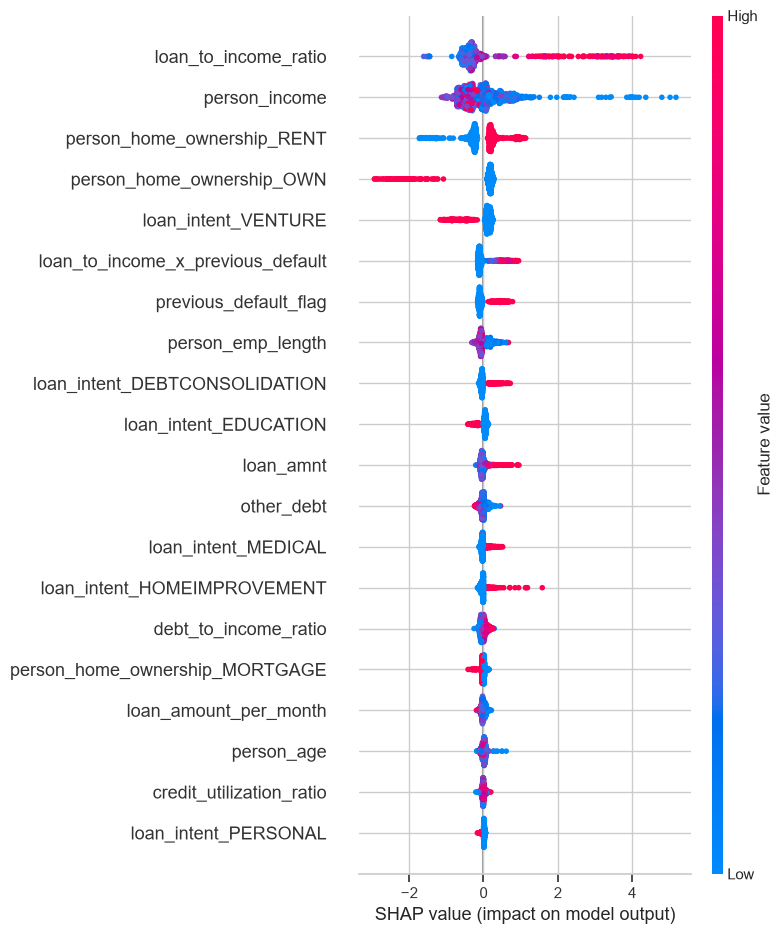

10.1 - FEATURE IMPORTANCE / EXPLAINABILITY
Champion: LightGBM
Explainability status: shap_completed


,feature,mean_abs_shap,rank
0,loan_to_income_ratio,0.6650,1
1,person_income,0.4747,2
2,person_home_ownership_RENT,0.3530,3
3,person_home_ownership_OWN,0.3484,4
4,loan_intent_VENTURE,0.2212,5
5,loan_to_income_x_previous_default,0.1821,6
6,previous_default_flag,0.1587,7
7,person_emp_length,0.1182,8
8,loan_intent_DEBTCONSOLIDATION,0.0945,9
9,loan_intent_EDUCATION,0.0803,10


,observation_index,PD,score,risk_grade,decision,top_risk_increasing_features,top_risk_reducing_features
0,19615,0.0585,775.0307,B,APPROVE,"[person_home_ownership_RENT, loan_intent_DEBTC...","[loan_to_income_ratio, person_income, debt_to_..."
1,15714,0.2644,648.6757,D,MANUAL_REVIEW,"[previous_default_flag, loan_to_income_x_previ...","[person_income, loan_to_income_ratio, person_h..."
2,23183,1.0000,300.0000,E,REJECT,"[loan_to_income_ratio, person_income, person_h...","[person_emp_length, loan_to_income_x_previous_..."



Note:
SHAP explains model contribution, not causality.


In [23]:
# 10.1 - Feature importance / SHAP draft

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "champion_candidate_name",
    "champion_candidate_pipeline",
    "X_dev_raw",
    "locked_test_predictions",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy Section 7-9 trước explainability. Thiếu: "
        + ", ".join(missing_objects)
    )


def extract_base_pipelines(model):
    if isinstance(model, Pipeline):
        return [model]

    base_pipeline = getattr(model, "base_pipeline", None)
    if isinstance(base_pipeline, Pipeline):
        return [base_pipeline]

    pipelines = []
    for calibrated_estimator in getattr(model, "calibrated_classifiers_", []):
        estimator = getattr(calibrated_estimator, "estimator", None)
        if estimator is None:
            estimator = getattr(calibrated_estimator, "base_estimator", None)
        if isinstance(estimator, Pipeline):
            pipelines.append(estimator)
    return pipelines


def transform_for_model(fitted_pipeline, X_input):
    X_work = X_input.copy()

    business_cleaner = fitted_pipeline.named_steps.get("business_cleaner")
    if business_cleaner is not None:
        X_work = business_cleaner.transform(X_work)

    feature_builder_step = fitted_pipeline.named_steps.get("feature_builder")
    preprocessor_step = fitted_pipeline.named_steps.get("preprocess")

    if feature_builder_step is None or preprocessor_step is None:
        raise RuntimeError("Pipeline thiếu feature_builder hoặc preprocess.")

    X_engineered = feature_builder_step.transform(X_work)
    X_preprocessed = preprocessor_step.transform(X_engineered)

    if hasattr(preprocessor_step, "get_feature_names_out"):
        feature_names = list(preprocessor_step.get_feature_names_out())
    elif isinstance(X_preprocessed, pd.DataFrame):
        feature_names = X_preprocessed.columns.tolist()
    else:
        feature_names = [
            f"feature_{index}"
            for index in range(X_preprocessed.shape[1])
        ]

    return X_preprocessed, feature_names


base_pipelines = extract_base_pipelines(champion_candidate_pipeline)

if not base_pipelines:
    raise RuntimeError(
        "Không trích xuất được fitted base pipeline từ champion_candidate_pipeline."
    )

explain_pipeline = base_pipelines[0]
explain_model = explain_pipeline.named_steps.get("model")

if explain_model is None:
    raise RuntimeError("Base pipeline không có step 'model'.")

native_model = getattr(explain_model, "model_", explain_model)

sample_size = min(1000, len(X_dev_raw))
explain_sample = X_dev_raw.sample(
    n=sample_size,
    random_state=RANDOM_STATE if "RANDOM_STATE" in globals() else 42,
)

preprocessed_sample, feature_names = transform_for_model(
    explain_pipeline,
    explain_sample,
)

model_family_text = champion_candidate_name.lower()
shap_available = False
shap_error = ""
explainability_status = "started"
global_shap_importance = pd.DataFrame()

# ============================================================
# 2. Global explainability
# ============================================================

if "logistic" in model_family_text and hasattr(native_model, "coef_"):
    coefficients = native_model.coef_.ravel()
    global_feature_importance = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients,
    })
    global_feature_importance["abs_coefficient"] = global_feature_importance[
        "coefficient"
    ].abs()
    global_feature_importance["direction"] = np.where(
        global_feature_importance["coefficient"] >= 0,
        "increases_model_default_log_odds",
        "decreases_model_default_log_odds",
    )
    global_feature_importance = global_feature_importance.sort_values(
        "abs_coefficient",
        ascending=False,
    ).reset_index(drop=True)
    explainability_status = "coefficient_importance"
    explainability_note = (
        "Logistic coefficients explain association with model log-odds, not causality."
    )

else:
    try:
        import shap
        shap_available = True
    except ImportError as exc:
        shap_available = False
        shap_error = str(exc)

    if shap_available:
        try:
            shap_explainer = shap.TreeExplainer(native_model)
            shap_values = shap_explainer.shap_values(preprocessed_sample)

            if isinstance(shap_values, list):
                shap_matrix = shap_values[-1]
            else:
                shap_matrix = shap_values

            if getattr(shap_matrix, "ndim", 2) == 3:
                shap_matrix = shap_matrix[:, :, -1]

            global_shap_importance = pd.DataFrame({
                "feature": feature_names,
                "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
            }).sort_values(
                "mean_abs_shap",
                ascending=False,
            ).reset_index(drop=True)

            global_shap_importance["rank"] = np.arange(
                1,
                len(global_shap_importance) + 1,
            )
            global_feature_importance = global_shap_importance.copy()
            explainability_status = "shap_completed"
            explainability_note = "SHAP explains model contribution, not causality."

            shap.summary_plot(
                shap_matrix,
                preprocessed_sample,
                feature_names=feature_names,
                show=True,
                max_display=20,
            )

        except Exception as exc:
            shap_available = False
            shap_error = str(exc)

    if not shap_available:
        if hasattr(native_model, "feature_importances_"):
            importance_values = native_model.feature_importances_
        elif hasattr(native_model, "get_feature_importance"):
            importance_values = native_model.get_feature_importance()
        else:
            importance_values = np.zeros(len(feature_names))

        global_feature_importance = pd.DataFrame({
            "feature": feature_names,
            "model_native_importance": importance_values,
        }).sort_values(
            "model_native_importance",
            ascending=False,
        ).reset_index(drop=True)
        global_feature_importance["rank"] = np.arange(
            1,
            len(global_feature_importance) + 1,
        )
        explainability_status = "shap_unavailable"
        explainability_note = (
            "SHAP unavailable or failed; fallback uses model-native feature importance, "
            "which is not equivalent to SHAP and is not causal. "
            f"SHAP error: {shap_error[:200]}"
        )

# ============================================================
# 3. Local explainability examples
# ============================================================

local_rows = []

for decision_label in ["APPROVE", "MANUAL_REVIEW", "REJECT"]:
    decision_rows = locked_test_predictions[
        locked_test_predictions["decision"].eq(decision_label)
    ].sort_values("calibrated_pd")

    if decision_rows.empty:
        continue

    selected_index = decision_rows.index[len(decision_rows) // 2]
    row_features = X_locked_test_raw.loc[[selected_index]] if "X_locked_test_raw" in globals() else X_dev_raw.loc[[selected_index]]

    top_increasing = []
    top_reducing = []

    if explainability_status == "shap_completed":
        try:
            row_preprocessed, _ = transform_for_model(
                explain_pipeline,
                row_features,
            )
            row_shap_values = shap_explainer.shap_values(row_preprocessed)
            if isinstance(row_shap_values, list):
                row_shap_matrix = row_shap_values[-1]
            else:
                row_shap_matrix = row_shap_values
            if getattr(row_shap_matrix, "ndim", 2) == 3:
                row_shap_matrix = row_shap_matrix[:, :, -1]

            row_shap = pd.Series(
                row_shap_matrix[0],
                index=feature_names,
            ).sort_values()
            top_reducing = row_shap.head(5).index.tolist()
            top_increasing = row_shap.tail(5).sort_values(
                ascending=False
            ).index.tolist()
        except Exception as exc:
            top_increasing = [f"local_shap_failed: {str(exc)[:120]}"]
            top_reducing = []
    else:
        top_increasing = global_feature_importance.head(5)["feature"].tolist()

    local_rows.append({
        "observation_index": selected_index,
        "PD": locked_test_predictions.loc[selected_index, "calibrated_pd"],
        "score": locked_test_predictions.loc[selected_index, "credit_score"],
        "risk_grade": locked_test_predictions.loc[selected_index, "risk_grade"],
        "decision": decision_label,
        "top_risk_increasing_features": top_increasing,
        "top_risk_reducing_features": top_reducing,
    })

local_explanations = pd.DataFrame(local_rows)

print("=" * 90)
print("10.1 - FEATURE IMPORTANCE / EXPLAINABILITY")
print("=" * 90)
print(f"Champion: {champion_candidate_name}")
print(f"Explainability status: {explainability_status}")

display(global_feature_importance.head(30))

if not local_explanations.empty:
    display(local_explanations)

print("\nNote:")
print(explainability_note)


In [24]:
# 10.2 - Fairness audit draft

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "locked_test_predictions",
    "audit_only_cols",
    "audit_test_raw",
    "safe_divide",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy Section 9 trước fairness audit. Thiếu: "
        + ", ".join(missing_objects)
    )

MIN_FAIRNESS_GROUP_SIZE = 100

fairness_group_tables = {}
fairness_summary_records = []

if not audit_only_cols:
    fairness_summary = pd.DataFrame([
        {
            "audit_variable": "none",
            "valid_groups": 0,
            "min_group_size": MIN_FAIRNESS_GROUP_SIZE,
            "max_approval_rate_gap": np.nan,
            "max_default_capture_gap": np.nan,
            "max_fpr_gap": np.nan,
            "review_status": "no_audit_variables",
            "note": "No audit-only variables available for group diagnostics.",
        }
    ])

else:
    fairness_base = locked_test_predictions.join(
        audit_test_raw[
            [
                col
                for col in audit_only_cols
                if col in audit_test_raw.columns
            ]
        ],
        how="left",
    )

    overall_approval_rate = float(
        fairness_base["decision"].eq("APPROVE").mean()
    )
    overall_default_capture_rate = safe_divide(
        int(
            (
                fairness_base["decision"].eq("REJECT")
                & fairness_base["y_true"].eq(1)
            ).sum()
        ),
        int(fairness_base["y_true"].sum()),
    )
    overall_fpr = safe_divide(
        int(
            (
                fairness_base["decision"].eq("REJECT")
                & fairness_base["y_true"].eq(0)
            ).sum()
        ),
        int(fairness_base["y_true"].eq(0).sum()),
    )

    for audit_col in audit_only_cols:
        if audit_col not in fairness_base.columns:
            continue

        if fairness_base[audit_col].nunique(dropna=True) < 2:
            continue

        group_records = []

        for group_value, group_frame in fairness_base.groupby(
            audit_col,
            dropna=False,
        ):
            group_count = len(group_frame)

            if group_count < MIN_FAIRNESS_GROUP_SIZE:
                continue

            group_defaults = int(
                group_frame["y_true"].sum()
            )
            group_non_defaults = int(
                group_frame["y_true"].eq(0).sum()
            )
            rejected_defaults = int(
                (
                    group_frame["decision"].eq("REJECT")
                    & group_frame["y_true"].eq(1)
                ).sum()
            )
            rejected_non_defaults = int(
                (
                    group_frame["decision"].eq("REJECT")
                    & group_frame["y_true"].eq(0)
                ).sum()
            )

            default_capture_rate = safe_divide(
                rejected_defaults,
                group_defaults,
            )
            false_positive_rate = safe_divide(
                rejected_non_defaults,
                group_non_defaults,
            )

            group_records.append({
                audit_col: group_value,
                "count": group_count,
                "observed_default_rate": float(
                    group_frame["y_true"].mean()
                ),
                "mean_pd": float(
                    group_frame["calibrated_pd"].mean()
                ),
                "approval_rate": float(
                    group_frame["decision"].eq("APPROVE").mean()
                ),
                "review_rate": float(
                    group_frame["decision"].eq("MANUAL_REVIEW").mean()
                ),
                "rejection_rate": float(
                    group_frame["decision"].eq("REJECT").mean()
                ),
                "default_capture_rate": default_capture_rate,
                "recall_tpr_default": default_capture_rate,
                "false_positive_rate": false_positive_rate,
            })

        group_table = pd.DataFrame(
            group_records
        )

        if group_table.empty:
            fairness_summary_records.append({
                "audit_variable": audit_col,
                "valid_groups": 0,
                "min_group_size": MIN_FAIRNESS_GROUP_SIZE,
                "max_approval_rate_gap": np.nan,
                "max_default_capture_gap": np.nan,
                "max_fpr_gap": np.nan,
                "review_status": "insufficient_group_size",
                "note": "No group meets minimum sample size.",
            })
            continue

        group_table["approval_rate_gap_vs_overall"] = (
            group_table["approval_rate"]
            - overall_approval_rate
        )
        group_table["default_capture_gap_vs_overall"] = (
            group_table["default_capture_rate"]
            - overall_default_capture_rate
        )
        group_table["fpr_gap_vs_overall"] = (
            group_table["false_positive_rate"]
            - overall_fpr
        )

        group_table = group_table.sort_values(
            "count",
            ascending=False,
        ).reset_index(drop=True)

        fairness_group_tables[audit_col] = group_table

        fairness_summary_records.append({
            "audit_variable": audit_col,
            "valid_groups": len(group_table),
            "min_group_size": MIN_FAIRNESS_GROUP_SIZE,
            "max_approval_rate_gap": group_table[
                "approval_rate_gap_vs_overall"
            ].abs().max(),
            "max_default_capture_gap": group_table[
                "default_capture_gap_vs_overall"
            ].abs().max(),
            "max_fpr_gap": group_table[
                "fpr_gap_vs_overall"
            ].abs().max(),
            "review_status": "diagnostic_completed",
            "note": (
                "Group differences are diagnostic signals, not proof of discrimination."
            ),
        })

    fairness_summary = pd.DataFrame(
        fairness_summary_records
    )

fairness_interpretation_note = (
    "Audit-only variables are used only for post-model diagnostics and are not model inputs. "
    "Group differences do not prove discrimination. Geography can act as a proxy variable. "
    "This dataset is a portfolio demonstration, not production bank data; no model or policy "
    "changes are made after this audit."
)

# ============================================================
# 2. Display
# ============================================================

print("=" * 90)
print("10.2 - FAIRNESS AUDIT")
print("=" * 90)

display(
    fairness_summary.style.format({
        "max_approval_rate_gap": "{:.2%}",
        "max_default_capture_gap": "{:.2%}",
        "max_fpr_gap": "{:.2%}",
    })
)

for audit_col, group_table in fairness_group_tables.items():
    print(f"\nAudit variable: {audit_col}")
    display(
        group_table.head(20).style.format({
            "observed_default_rate": "{:.2%}",
            "mean_pd": "{:.4f}",
            "approval_rate": "{:.2%}",
            "review_rate": "{:.2%}",
            "rejection_rate": "{:.2%}",
            "default_capture_rate": "{:.2%}",
            "recall_tpr_default": "{:.2%}",
            "false_positive_rate": "{:.2%}",
            "approval_rate_gap_vs_overall": "{:+.2%}",
            "default_capture_gap_vs_overall": "{:+.2%}",
            "fpr_gap_vs_overall": "{:+.2%}",
        })
    )

print("\nNote:")
print(fairness_interpretation_note)


10.2 - FAIRNESS AUDIT


,audit_variable,valid_groups,min_group_size,max_approval_rate_gap,max_default_capture_gap,max_fpr_gap,review_status,note
0,gender,2,100,0.31%,0.84%,0.03%,diagnostic_completed,"Group differences are diagnostic signals, not proof of discrimination."
1,country,3,100,1.87%,1.73%,0.04%,diagnostic_completed,"Group differences are diagnostic signals, not proof of discrimination."
2,state,9,100,4.70%,5.72%,0.73%,diagnostic_completed,"Group differences are diagnostic signals, not proof of discrimination."
3,city,18,100,8.36%,8.18%,1.07%,diagnostic_completed,"Group differences are diagnostic signals, not proof of discrimination."
4,city_latitude,18,100,8.36%,8.18%,1.07%,diagnostic_completed,"Group differences are diagnostic signals, not proof of discrimination."
5,city_longitude,18,100,8.36%,8.18%,1.07%,diagnostic_completed,"Group differences are diagnostic signals, not proof of discrimination."



Audit variable: gender


,gender,count,observed_default_rate,mean_pd,approval_rate,review_rate,rejection_rate,default_capture_rate,recall_tpr_default,false_positive_rate,approval_rate_gap_vs_overall,default_capture_gap_vs_overall,fpr_gap_vs_overall
0,Female,3302,21.41%,0.2188,68.99%,20.14%,10.87%,49.50%,49.50%,0.35%,+0.31%,+0.84%,-0.03%
1,Male,3215,22.24%,0.2213,68.37%,20.68%,10.95%,47.83%,47.83%,0.40%,-0.31%,-0.83%,+0.03%



Audit variable: country


...


Audit variable: city_latitude


,city_latitude,count,observed_default_rate,mean_pd,approval_rate,review_rate,rejection_rate,default_capture_rate,recall_tpr_default,false_positive_rate,approval_rate_gap_vs_overall,default_capture_gap_vs_overall,fpr_gap_vs_overall
0,51.481600,394,24.11%,0.2555,63.45%,22.84%,13.71%,56.84%,56.84%,0.00%,-5.23%,+8.18%,-0.37%
1,55.864200,388,21.65%,0.2088,72.68%,15.98%,11.34%,51.19%,51.19%,0.33%,+4.00%,+2.53%,-0.04%
2,45.501700,382,19.63%,0.2064,70.94%,19.37%,9.69%,49.33%,49.33%,0.00%,+2.26%,+0.67%,-0.37%
3,55.953300,378,26.72%,0.2606,60.32%,25.93%,13.76%,50.50%,50.50%,0.36%,-8.36%,+1.83%,-0.01%
4,53.480800,374,20.05%,0.2227,68.45%,20.59%,10.96%,52.00%,52.00%,0.67%,-0.23%,+3.34%,+0.30%
5,32.776700,373,22.79%,0.2244,68.63%,19.30%,12.06%,50.59%,50.59%,0.69%,-0.05%,+1.92%,+0.32%
6,48.428400,370,23.51%,0.2252,67.30%,22.16%,10.54%,44.83%,44.83%,0.00%,-1.38%,-3.84%,-0.37%
7,29.760400,369,20.33%,0.2111,69.11%,21.14%,9.76%,48.00%,48.00%,0.00%,+0.42%,-0.66%,-0.37%
8,34.052200,358,23.18%,0.2147,68.16%,22.07%,9.78%,42.17%,42.17%,0.00%,-0.53%,-6.50%,-0.37%
9,42.886400,356,19.38%,0.2013,73.60%,16.29%,10.11%,47.83%,47.83%,1.05%,+4.91%,-0.84%,+0.67%



Audit variable: city_longitude


,city_longitude,count,observed_default_rate,mean_pd,approval_rate,review_rate,rejection_rate,default_capture_rate,recall_tpr_default,false_positive_rate,approval_rate_gap_vs_overall,default_capture_gap_vs_overall,fpr_gap_vs_overall
0,-3.179100,394,24.11%,0.2555,63.45%,22.84%,13.71%,56.84%,56.84%,0.00%,-5.23%,+8.18%,-0.37%
1,-4.251800,388,21.65%,0.2088,72.68%,15.98%,11.34%,51.19%,51.19%,0.33%,+4.00%,+2.53%,-0.04%
2,-73.567300,382,19.63%,0.2064,70.94%,19.37%,9.69%,49.33%,49.33%,0.00%,+2.26%,+0.67%,-0.37%
3,-3.188300,378,26.72%,0.2606,60.32%,25.93%,13.76%,50.50%,50.50%,0.36%,-8.36%,+1.83%,-0.01%
4,-2.242600,374,20.05%,0.2227,68.45%,20.59%,10.96%,52.00%,52.00%,0.67%,-0.23%,+3.34%,+0.30%
5,-96.797000,373,22.79%,0.2244,68.63%,19.30%,12.06%,50.59%,50.59%,0.69%,-0.05%,+1.92%,+0.32%
6,-123.365600,370,23.51%,0.2252,67.30%,22.16%,10.54%,44.83%,44.83%,0.00%,-1.38%,-3.84%,-0.37%
7,-95.369800,369,20.33%,0.2111,69.11%,21.14%,9.76%,48.00%,48.00%,0.00%,+0.42%,-0.66%,-0.37%
8,-118.243700,358,23.18%,0.2147,68.16%,22.07%,9.78%,42.17%,42.17%,0.00%,-0.53%,-6.50%,-0.37%
9,-78.878400,356,19.38%,0.2013,73.60%,16.29%,10.11%,47.83%,47.83%,1.05%,+4.91%,-0.84%,+0.67%



Note:
Audit-only variables are used only for post-model diagnostics and are not model inputs. Group differences do not prove discrimination. Geography can act as a proxy variable. This dataset is a portfolio demonstration, not production bank data; no model or policy changes are made after this audit.


In [25]:
# 10.3 - Stress testing draft

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "X_locked_test_raw",
    "champion_candidate_pipeline",
    "pd_to_score",
    "assign_risk_grade",
    "assign_credit_decision",
    "positive_class_proba",
    "locked_test_predictions",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy Section 9 trước stress testing. Thiếu: "
        + ", ".join(missing_objects)
    )

stress_base_X = X_locked_test_raw.copy()
stress_dataset_used = "locked_test_copy_post_model_diagnostic"


def apply_stress_scenario(X_input, scenario_key):
    X_stressed = X_input.copy()

    if scenario_key == "baseline":
        return X_stressed

    if scenario_key == "income_down_10":
        if "person_income" in X_stressed.columns:
            X_stressed["person_income"] = (
                pd.to_numeric(
                    X_stressed["person_income"],
                    errors="coerce",
                )
                * 0.90
            ).clip(lower=1)
        return X_stressed

    if scenario_key == "income_down_20":
        if "person_income" in X_stressed.columns:
            X_stressed["person_income"] = (
                pd.to_numeric(
                    X_stressed["person_income"],
                    errors="coerce",
                )
                * 0.80
            ).clip(lower=1)
        return X_stressed

    if scenario_key == "debt_burden_up_10":
        for debt_col in [
            "other_debt",
            "current_loan_balance",
        ]:
            if debt_col in X_stressed.columns:
                X_stressed[debt_col] = (
                    pd.to_numeric(
                        X_stressed[debt_col],
                        errors="coerce",
                    )
                    * 1.10
                ).clip(lower=0)
        return X_stressed

    if scenario_key == "credit_utilization_up":
        for util_col in [
            "credit_utilization_ratio",
            "credit_utilization",
        ]:
            if util_col in X_stressed.columns:
                X_stressed[util_col] = (
                    pd.to_numeric(
                        X_stressed[util_col],
                        errors="coerce",
                    )
                    + 0.10
                ).clip(lower=0, upper=1)
        return X_stressed

    if scenario_key == "past_delinquency_shock":
        if "past_delinquencies" in X_stressed.columns:
            X_stressed["past_delinquencies"] = (
                pd.to_numeric(
                    X_stressed["past_delinquencies"],
                    errors="coerce",
                )
                + 1
            ).clip(lower=0)
        return X_stressed

    raise ValueError(f"Unknown stress scenario: {scenario_key}")


stress_scenarios = [
    {
        "scenario": "baseline",
        "description": "Baseline locked-test copy with frozen policy.",
    },
    {
        "scenario": "income_down_10",
        "description": "Simulated person_income decrease by 10%.",
    },
    {
        "scenario": "income_down_20",
        "description": "Simulated person_income decrease by 20%.",
    },
    {
        "scenario": "debt_burden_up_10",
        "description": "Simulated debt burden increase by 10% where source debt columns exist.",
    },
    {
        "scenario": "credit_utilization_up",
        "description": "Simulated credit utilization increase by 10 percentage points where available.",
    },
    {
        "scenario": "past_delinquency_shock",
        "description": "Simulated +1 past delinquency where source column exists.",
    },
]

stress_summary_records = []
stress_grade_records = []
stress_warning_records = []

for scenario in stress_scenarios:
    scenario_X = apply_stress_scenario(
        stress_base_X,
        scenario["scenario"],
    )

    scenario_pd = pd.Series(
        positive_class_proba(
            champion_candidate_pipeline,
            scenario_X,
        ),
        index=scenario_X.index,
        dtype=float,
    )

    scenario_frame = pd.DataFrame(
        {
            "calibrated_pd": scenario_pd,
        },
        index=scenario_X.index,
    )

    scenario_frame["credit_score"] = pd_to_score(
        scenario_frame["calibrated_pd"]
    ).to_numpy()
    scenario_frame["risk_grade"] = assign_risk_grade(
        scenario_frame["calibrated_pd"]
    ).to_numpy()
    scenario_frame["decision"] = assign_credit_decision(
        scenario_frame["calibrated_pd"]
    ).to_numpy()

    stress_summary_records.append({
        "scenario": scenario["scenario"],
        "description": scenario["description"],
        "mean_pd": scenario_frame["calibrated_pd"].mean(),
        "median_pd": scenario_frame["calibrated_pd"].median(),
        "mean_score": scenario_frame["credit_score"].mean(),
        "approval_rate": scenario_frame["decision"].eq("APPROVE").mean(),
        "review_rate": scenario_frame["decision"].eq("MANUAL_REVIEW").mean(),
        "rejection_rate": scenario_frame["decision"].eq("REJECT").mean(),
    })

    grade_distribution = (
        scenario_frame["risk_grade"]
        .value_counts(normalize=True)
        .reindex(
            [
                "A",
                "B",
                "C",
                "D",
                "E",
            ],
            fill_value=0,
        )
    )

    for grade, share in grade_distribution.items():
        stress_grade_records.append({
            "scenario": scenario["scenario"],
            "risk_grade": grade,
            "share": share,
        })

stress_test_summary = pd.DataFrame(
    stress_summary_records
)

baseline_row = stress_test_summary[
    stress_test_summary["scenario"].eq("baseline")
].iloc[0]

stress_test_summary["delta_mean_pd"] = (
    stress_test_summary["mean_pd"]
    - baseline_row["mean_pd"]
)
stress_test_summary["delta_mean_score"] = (
    stress_test_summary["mean_score"]
    - baseline_row["mean_score"]
)
stress_test_summary["delta_approval_rate"] = (
    stress_test_summary["approval_rate"]
    - baseline_row["approval_rate"]
)
stress_test_summary["delta_rejection_rate"] = (
    stress_test_summary["rejection_rate"]
    - baseline_row["rejection_rate"]
)

for _, row in stress_test_summary.iterrows():
    if row["scenario"] == "baseline":
        continue

    scenario_looks_adverse = any(
        token in row["scenario"]
        for token in [
            "down",
            "up",
            "shock",
        ]
    )

    if scenario_looks_adverse and row["delta_mean_pd"] < -0.02:
        stress_warning_records.append({
            "scenario": row["scenario"],
            "warning": (
                "Mean PD decreased materially under an adverse scenario. "
                "Review source feature availability and model sensitivity."
            ),
        })

stress_grade_distribution = pd.DataFrame(
    stress_grade_records
)

stress_testing_warnings = pd.DataFrame(
    stress_warning_records
)

stress_testing_note = (
    "SIMULATED STRESS SCENARIOS only. Source features are changed on a copy of "
    f"{stress_dataset_used}; frozen model and policy are not changed. Results measure "
    "sensitivity and are not macroeconomic forecasts."
)

# ============================================================
# 2. Display
# ============================================================

print("=" * 90)
print("10.3 - STRESS TESTING")
print("=" * 90)
print(f"Dataset used: {stress_dataset_used}")

display(
    stress_test_summary.style.format({
        "mean_pd": "{:.4f}",
        "median_pd": "{:.4f}",
        "mean_score": "{:.1f}",
        "approval_rate": "{:.2%}",
        "review_rate": "{:.2%}",
        "rejection_rate": "{:.2%}",
        "delta_mean_pd": "{:+.4f}",
        "delta_mean_score": "{:+.1f}",
        "delta_approval_rate": "{:+.2%}",
        "delta_rejection_rate": "{:+.2%}",
    })
)

display(
    stress_grade_distribution.pivot(
        index="scenario",
        columns="risk_grade",
        values="share",
    ).fillna(0).style.format("{:.2%}")
)

if not stress_testing_warnings.empty:
    print("\nStress testing warnings:")
    display(stress_testing_warnings)

print("\nNote:")
print(stress_testing_note)


10.3 - STRESS TESTING
Dataset used: locked_test_copy_post_model_diagnostic


,scenario,description,mean_pd,median_pd,mean_score,approval_rate,review_rate,rejection_rate,delta_mean_pd,delta_mean_score,delta_approval_rate,delta_rejection_rate
0,baseline,Baseline locked-test copy with frozen policy.,0.2201,0.0920,697.7,68.68%,20.41%,10.91%,+0.0000,+0.0,+0.00%,+0.00%
1,income_down_10,Simulated person_income decrease by 10%.,0.2408,0.1207,683.0,64.40%,24.29%,11.31%,+0.0208,-14.7,-4.28%,+0.40%
2,income_down_20,Simulated person_income decrease by 20%.,0.2500,0.1438,677.5,63.66%,24.20%,12.14%,+0.0299,-20.2,-5.02%,+1.23%
3,debt_burden_up_10,Simulated debt burden increase by 10% where source debt columns exist.,0.2189,0.0864,698.4,69.08%,20.07%,10.85%,-0.0011,+0.7,+0.40%,-0.06%
4,credit_utilization_up,Simulated credit utilization increase by 10 percentage points where available.,0.2207,0.0920,697.3,68.57%,20.52%,10.91%,+0.0006,-0.4,-0.11%,+0.00%
5,past_delinquency_shock,Simulated +1 past delinquency where source column exists.,0.2205,0.0920,697.2,68.65%,20.48%,10.86%,+0.0005,-0.5,-0.03%,-0.05%


risk_grade,A,B,C,D,E
scenario,,,,,
baseline,24.95%,21.50%,14.72%,18.05%,20.79%
credit_utilization_up,24.80%,21.50%,14.59%,18.17%,20.95%
debt_burden_up_10,25.32%,21.28%,15.11%,17.78%,20.50%
income_down_10,19.13%,19.43%,17.68%,20.29%,23.48%
income_down_20,18.66%,17.85%,17.71%,21.80%,23.98%
past_delinquency_shock,24.60%,21.50%,14.91%,18.14%,20.85%



Note:
SIMULATED STRESS SCENARIOS only. Source features are changed on a copy of locked_test_copy_post_model_diagnostic; frozen model and policy are not changed. Results measure sensitivity and are not macroeconomic forecasts.


## Section 11 - Final Summary và Model Card Notes

Summarize decisions for README, reports and MODEL_CARD.

In [26]:
# 11.1 - Model analysis summary

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "POLICY_FROZEN",
    "LOCKED_TEST_EVALUATED",
    "champion_candidate_name",
    "champion_candidate_model_key",
    "selected_params",
    "selected_calibration_method",
    "frozen_credit_policy",
    "primary_feature_cols",
    "y_dev",
    "y_locked_test",
    "locked_test_model_metrics",
    "locked_test_decision_metrics",
    "global_feature_importance",
    "fairness_summary",
    "stress_test_summary",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy Section 9 và Section 10 trước final summary. Thiếu: "
        + ", ".join(missing_objects)
    )

if POLICY_FROZEN is not True:
    raise AssertionError("Policy chưa frozen.")

if LOCKED_TEST_EVALUATED is not True:
    raise AssertionError("Locked Test chưa được evaluate.")

locked_metrics_row = locked_test_model_metrics.iloc[0]
decision_metrics_row = locked_test_decision_metrics.iloc[0]


def object_status(name):
    return "available" if name in globals() else "missing"


model_analysis_summary = pd.DataFrame([
    {
        "theme": "split_design",
        "decision_or_result": "80/20 Development/Locked Test split with stratified CV.",
        "evidence": f"Development rows={len(y_dev):,}; Locked Test rows={len(y_locked_test):,}.",
        "status": "complete",
        "artifact_or_object": "X_dev_raw, X_locked_test_raw, cv_strategy",
        "note": "Locked Test opened only after policy freeze.",
    },
    {
        "theme": "primary_feature_source",
        "decision_or_result": "Primary feature set from build_feature_decisions().",
        "evidence": f"Primary features={len(primary_feature_cols):,}.",
        "status": "complete",
        "artifact_or_object": "primary_feature_cols",
        "note": "Leakage/audit-only features excluded from Primary.",
    },
    {
        "theme": "feature_engineering",
        "decision_or_result": "Feature Builder runs inside sklearn Pipeline.",
        "evidence": object_status("CreditRiskFeatureBuilder"),
        "status": "complete",
        "artifact_or_object": "CreditRiskFeatureBuilder",
        "note": "No preprocessing fit before CV.",
    },
    {
        "theme": "baseline_models",
        "decision_or_result": "Dummy and Logistic Regression baselines created.",
        "evidence": object_status("baseline_model_metrics"),
        "status": "complete",
        "artifact_or_object": "baseline_model_metrics",
        "note": "Dummy excluded from champion selection.",
    },
    {
        "theme": "stronger_models",
        "decision_or_result": "LightGBM/CatBoost trained or marked not_installed.",
        "evidence": object_status("model_availability"),
        "status": "complete",
        "artifact_or_object": "model_availability",
        "note": "No optional replacement model used as core champion.",
    },
    {
        "theme": "model_comparison",
        "decision_or_result": "Models compared on Development CV metrics.",
        "evidence": object_status("model_leaderboard"),
        "status": "complete",
        "artifact_or_object": "model_leaderboard",
        "note": "ROC-AUC, PR-AUC, KS, Gini, Brier tracked.",
    },
    {
        "theme": "leakage_ablation",
        "decision_or_result": "Primary vs leakage candidates reviewed.",
        "evidence": object_status("ablation_results"),
        "status": "complete",
        "artifact_or_object": "ablation_results",
        "note": "loan_grade/loan_int_rate excluded from champion Primary model.",
    },
    {
        "theme": "hyperparameter_tuning",
        "decision_or_result": "Small-grid tuning on Development CV.",
        "evidence": object_status("tuning_results"),
        "status": "complete",
        "artifact_or_object": "tuning_results, selected_params",
        "note": "No tuning on Locked Test.",
    },
    {
        "theme": "calibration",
        "decision_or_result": f"Selected calibration method: {selected_calibration_method}.",
        "evidence": object_status("calibration_comparison"),
        "status": "complete",
        "artifact_or_object": "calibration_comparison",
        "note": "Raw vs Platt vs Isotonic compared on Development CV.",
    },
    {
        "theme": "champion_candidate",
        "decision_or_result": f"Champion candidate: {champion_candidate_name}.",
        "evidence": object_status("champion_selection_summary"),
        "status": "complete",
        "artifact_or_object": "champion_selection_summary",
        "note": "Selected before Locked Test evaluation.",
    },
    {
        "theme": "threshold_policy",
        "decision_or_result": "Approve/reject thresholds selected by simulated utility.",
        "evidence": f"approve={frozen_credit_policy['approve_threshold']:.4f}; reject={frozen_credit_policy['reject_threshold']:.4f}.",
        "status": "complete",
        "artifact_or_object": "decision_optimization_table",
        "note": "Simulated business assumptions only.",
    },
    {
        "theme": "credit_score",
        "decision_or_result": "Internal credit score mapped from calibrated PD.",
        "evidence": object_status("score_mapping_summary"),
        "status": "complete",
        "artifact_or_object": "pd_to_score, score_mapping_summary",
        "note": "Not a FICO score.",
    },
    {
        "theme": "risk_grade",
        "decision_or_result": "Risk grades A-E assigned from Development PD thresholds.",
        "evidence": object_status("grade_summary"),
        "status": "complete",
        "artifact_or_object": "risk_grade_thresholds, grade_summary",
        "note": "Boundaries frozen before Locked Test.",
    },
    {
        "theme": "decision_policy",
        "decision_or_result": "APPROVE / MANUAL_REVIEW / REJECT policy frozen.",
        "evidence": f"POLICY_FROZEN={POLICY_FROZEN}.",
        "status": "complete",
        "artifact_or_object": "frozen_credit_policy",
        "note": "No post-test adjustment allowed.",
    },
    {
        "theme": "locked_test_result",
        "decision_or_result": "Final Locked Test evaluation completed.",
        "evidence": f"ROC-AUC={locked_metrics_row['roc_auc']:.4f}; Brier={locked_metrics_row['brier']:.4f}.",
        "status": "complete",
        "artifact_or_object": "locked_test_model_metrics",
        "note": "Final evaluation only.",
    },
    {
        "theme": "explainability",
        "decision_or_result": "Global feature importance / SHAP diagnostics created.",
        "evidence": object_status("global_feature_importance"),
        "status": "complete",
        "artifact_or_object": "global_feature_importance, local_explanations",
        "note": "Model explanation is not causal explanation.",
    },
    {
        "theme": "fairness",
        "decision_or_result": "Audit-only group diagnostics completed.",
        "evidence": object_status("fairness_summary"),
        "status": "complete",
        "artifact_or_object": "fairness_summary, fairness_group_tables",
        "note": "Audit variables are not model inputs.",
    },
    {
        "theme": "stress_testing",
        "decision_or_result": "Simulated adverse scenarios completed.",
        "evidence": object_status("stress_test_summary"),
        "status": "complete",
        "artifact_or_object": "stress_test_summary",
        "note": "Stress scenarios are simulations, not forecasts.",
    },
])

final_model_result = pd.DataFrame([
    {
        "champion_model": champion_candidate_name,
        "feature_set": "Primary",
        "selected_params": selected_params.get(
            champion_candidate_model_key,
            {},
        ),
        "calibration_method": selected_calibration_method,
        "locked_test_roc_auc": locked_metrics_row["roc_auc"],
        "locked_test_pr_auc": locked_metrics_row["pr_auc"],
        "locked_test_ks": locked_metrics_row["ks"],
        "locked_test_gini": locked_metrics_row["gini"],
        "locked_test_brier": locked_metrics_row["brier"],
        "approve_threshold": frozen_credit_policy["approve_threshold"],
        "reject_threshold": frozen_credit_policy["reject_threshold"],
        "approval_rate": decision_metrics_row["approval_rate"],
        "review_rate": decision_metrics_row["review_rate"],
        "rejection_rate": decision_metrics_row["rejection_rate"],
        "bad_rate_among_approved": decision_metrics_row["bad_rate_among_approved"],
        "captured_default_rate": decision_metrics_row["captured_default_rate"],
        "rejected_default_capture_rate": decision_metrics_row["rejected_default_capture_rate"],
        "policy_status": "frozen" if POLICY_FROZEN else "not_frozen",
    }
])

print("=" * 90)
print("11.1 - MODEL ANALYSIS SUMMARY")
print("=" * 90)

display(model_analysis_summary)

print("\nFinal result summary:")
display(
    final_model_result.style.format({
        "locked_test_roc_auc": "{:.4f}",
        "locked_test_pr_auc": "{:.4f}",
        "locked_test_ks": "{:.4f}",
        "locked_test_gini": "{:.4f}",
        "locked_test_brier": "{:.4f}",
        "approve_threshold": "{:.4f}",
        "reject_threshold": "{:.4f}",
        "approval_rate": "{:.2%}",
        "review_rate": "{:.2%}",
        "rejection_rate": "{:.2%}",
        "bad_rate_among_approved": "{:.2%}",
        "captured_default_rate": "{:.2%}",
        "rejected_default_capture_rate": "{:.2%}",
    })
)


11.1 - MODEL ANALYSIS SUMMARY


,theme,decision_or_result,evidence,status,artifact_or_object,note
0,split_design,80/20 Development/Locked Test split with strat...,"Development rows=26,064; Locked Test rows=6,517.",complete,"X_dev_raw, X_locked_test_raw, cv_strategy",Locked Test opened only after policy freeze.
1,primary_feature_source,Primary feature set from build_feature_decisio...,Primary features=18.,complete,primary_feature_cols,Leakage/audit-only features excluded from Prim...
2,feature_engineering,Feature Builder runs inside sklearn Pipeline.,available,complete,CreditRiskFeatureBuilder,No preprocessing fit before CV.
3,baseline_models,Dummy and Logistic Regression baselines created.,available,complete,baseline_model_metrics,Dummy excluded from champion selection.
4,stronger_models,LightGBM/CatBoost trained or marked not_instal...,available,complete,model_availability,No optional replacement model used as core cha...
5,model_comparison,Models compared on Development CV metrics.,available,complete,model_leaderboard,"ROC-AUC, PR-AUC, KS, Gini, Brier tracked."
6,leakage_ablation,Primary vs leakage candidates reviewed.,available,complete,ablation_results,loan_grade/loan_int_rate excluded from champio...
7,hyperparameter_tuning,Small-grid tuning on Development CV.,available,complete,"tuning_results, selected_params",No tuning on Locked Test.
8,calibration,Selected calibration method: isotonic.,available,complete,calibration_comparison,Raw vs Platt vs Isotonic compared on Developme...
9,champion_candidate,Champion candidate: LightGBM.,available,complete,champion_selection_summary,Selected before Locked Test evaluation.



Final result summary:


,champion_model,feature_set,selected_params,calibration_method,locked_test_roc_auc,locked_test_pr_auc,locked_test_ks,locked_test_gini,locked_test_brier,approve_threshold,reject_threshold,approval_rate,review_rate,rejection_rate,bad_rate_among_approved,captured_default_rate,rejected_default_capture_rate,policy_status
0,LightGBM,Primary,"{'model__colsample_bytree': 0.85, 'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 40, 'model__n_estimators': 150, 'model__num_leaves': 31, 'model__subsample': 0.85}",isotonic,0.8932,0.7992,0.6275,0.7865,0.0846,0.2079,0.7188,68.68%,20.41%,10.91%,6.61%,79.18%,48.66%,frozen


In [27]:
# 11.2 - Model card notes draft

# ============================================================
# 1. Guard
# ============================================================

required_objects = [
    "model_analysis_summary",
    "final_model_result",
    "POLICY_FROZEN",
    "LOCKED_TEST_EVALUATED",
    "champion_candidate_name",
    "champion_candidate_model_key",
    "selected_calibration_method",
    "selected_params",
    "locked_test_model_metrics",
    "locked_test_decision_metrics",
    "frozen_credit_policy",
    "global_feature_importance",
    "fairness_summary",
    "stress_test_summary",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Hãy chạy cell 11.1 và các section trước. Thiếu: "
        + ", ".join(missing_objects)
    )

if POLICY_FROZEN is not True:
    raise AssertionError("POLICY_FROZEN phải bằng True.")

if LOCKED_TEST_EVALUATED is not True:
    raise AssertionError("LOCKED_TEST_EVALUATED phải bằng True.")

locked_metrics_row = locked_test_model_metrics.iloc[0]
decision_metrics_row = locked_test_decision_metrics.iloc[0]

excluded_feature_notes = {
    "id": ID_COL if "ID_COL" in globals() else "client_ID",
    "target": TARGET_COL if "TARGET_COL" in globals() else "loan_status",
    "known_leakage_candidates": [
        col
        for col in [
            "loan_grade",
            "loan_int_rate",
        ]
        if "extended_only_cols" in globals() and col in extended_only_cols
    ],
    "audit_only_variables": audit_only_cols if "audit_only_cols" in globals() else [],
    "redundant_excluded_features": redundant_excluded_cols if "redundant_excluded_cols" in globals() else [],
}

model_card_notes = {
    "intended_use": {
        "summary": (
            "Predict Probability of Default and support a credit decision simulation. "
            "This is not a production banking system."
        ),
        "decision_support": "APPROVE / MANUAL_REVIEW / REJECT simulation.",
    },
    "target": {
        "name": TARGET_COL if "TARGET_COL" in globals() else "loan_status",
        "positive_class": "1 = default",
        "negative_class": "0 = non-default",
    },
    "dataset": {
        "dataset_size": int(len(df_model)) if "df_model" in globals() else None,
        "target_prevalence": float(y.mean()) if "y" in globals() else None,
        "limitations": [
            "Dataset has no timeline.",
            "Dataset is not verified as production bank data.",
            "Future label availability is not represented.",
        ],
    },
    "features": {
        "primary_features": primary_feature_cols if "primary_feature_cols" in globals() else [],
        "engineered_features": engineered_feature_cols if "engineered_feature_cols" in globals() else [],
        "feature_set": "Primary application-time features.",
    },
    "excluded_features": excluded_feature_notes,
    "leakage_controls": {
        "summary": "Primary vs Extended feature decisions and Leakage Ablation Study performed.",
        "locked_test_control": "Locked Test untouched until model and policy freeze.",
        "known_leakage_excluded": excluded_feature_notes["known_leakage_candidates"],
    },
    "training_strategy": {
        "split": "Development / Locked Test",
        "cv": f"{N_SPLITS}-fold Stratified CV" if "N_SPLITS" in globals() else "Stratified CV",
        "preprocessing": "Feature engineering and preprocessing inside Pipeline.",
        "tuning": "Development Set only.",
    },
    "models_considered": {
        "dummy": "baseline only, not eligible champion",
        "logistic_regression": "core model",
        "lightgbm": "core model if installed",
        "catboost": "core model if installed",
        "availability_table": model_availability.to_dict(orient="records") if "model_availability" in globals() else [],
    },
    "champion_model": {
        "name": champion_candidate_name,
        "selected_params": selected_params.get(
            champion_candidate_model_key,
            {},
        ),
        "calibration_method": selected_calibration_method,
    },
    "evaluation": {
        "locked_test_roc_auc": float(locked_metrics_row["roc_auc"]),
        "locked_test_pr_auc": float(locked_metrics_row["pr_auc"]),
        "locked_test_ks": float(locked_metrics_row["ks"]),
        "locked_test_gini": float(locked_metrics_row["gini"]),
        "locked_test_brier": float(locked_metrics_row["brier"]),
        "generalization_comparison": generalization_comparison.to_dict(orient="records") if "generalization_comparison" in globals() else [],
    },
    "calibration": {
        "selected_method": selected_calibration_method,
        "comparison": calibration_comparison.to_dict(orient="records") if "calibration_comparison" in globals() else [],
        "selection_metric": "Brier Score with ranking metrics checked.",
    },
    "decision_policy": {
        "approve_threshold": frozen_credit_policy["approve_threshold"],
        "reject_threshold": frozen_credit_policy["reject_threshold"],
        "decisions": ["APPROVE", "MANUAL_REVIEW", "REJECT"],
        "simulated_business_utility": frozen_credit_policy["simulated_business_utility"],
        "captured_default_rate_definition": frozen_credit_policy.get(
            "captured_default_rate_definition"
        ),
        "rejected_default_capture_rate_definition": frozen_credit_policy.get(
            "rejected_default_capture_rate_definition"
        ),
        "policy_status": "frozen before locked test",
    },
    "credit_score": {
        "type": "Internal Credit Score, not FICO.",
        "score_min": frozen_credit_policy["credit_score_min"],
        "score_max": frozen_credit_policy["credit_score_max"],
        "direction": "PD increases -> score decreases.",
    },
    "risk_grade": {
        "definition": "A lowest risk through E highest risk.",
        "thresholds": frozen_credit_policy["risk_grade_thresholds"],
        "ordering_check": risk_ordering_check if "risk_ordering_check" in globals() else {},
    },
    "explainability": {
        "artifact": "global_feature_importance, local_explanations",
        "note": "SHAP/coefficient explanation describes model contribution, not causality.",
    },
    "fairness": {
        "audit_variables": audit_only_cols if "audit_only_cols" in globals() else [],
        "summary": fairness_summary.to_dict(orient="records"),
        "limitations": [
            "Audit-only variables are not model inputs.",
            "Group differences do not prove discrimination.",
            "Small groups are excluded from conclusions.",
        ],
    },
    "stress_testing": {
        "scenarios": stress_test_summary[["scenario", "description"]].to_dict(orient="records"),
        "note": "Simulated scenarios only, not macroeconomic forecasts.",
    },
    "limitations": [
        "Dataset has no timeline.",
        "No real LGD / EAD.",
        "Business utility/cost assumptions are simulated.",
        "Thresholds are not a real bank policy.",
        "Model has not been validated on production data.",
        "Stress scenarios are simulations.",
        "Fairness conclusions are limited by dataset and group sizes.",
    ],
    "monitoring_notes": [
        "Planned feature drift monitoring.",
        "Planned PD distribution drift monitoring.",
        "Track approval/review/rejection rates.",
        "Track default rate if future labels become available.",
        "Track calibration drift.",
        "Track fairness metrics over time.",
        "Use PSI/CSI when future population snapshots exist.",
    ],
    "model_status": "portfolio_project_frozen_model",
}

known_leakage_in_primary = sorted(
    set(primary_feature_cols if "primary_feature_cols" in globals() else [])
    & set([
        "loan_grade",
        "loan_int_rate",
    ])
)

audit_in_primary = sorted(
    set(primary_feature_cols if "primary_feature_cols" in globals() else [])
    & set(audit_only_cols if "audit_only_cols" in globals() else [])
)


final_pipeline_checks = pd.DataFrame([
    {"check": "no_known_leakage", "status": "pass" if not known_leakage_in_primary else "fail", "evidence": str(known_leakage_in_primary), "note": "loan_grade/loan_int_rate not in Primary."},
    {"check": "no_impossible_values_enter_model_unhandled", "status": "pass" if "BusinessRuleCleaner" in globals() else "fail", "evidence": "BusinessRuleCleaner before FeatureBuilder in pipelines.", "note": "Invalid age/employment length set to NaN inside CV pipeline."},
    {"check": "redundant_features_resolved", "status": "pass" if "redundant_feature_decisions" in globals() else "fail", "evidence": str(redundant_feature_decisions.to_dict(orient="records")) if "redundant_feature_decisions" in globals() else "missing", "note": "Canonical LTI/DTI retained."},
    {"check": "primary_feature_policy_respected", "status": "pass" if not audit_in_primary else "fail", "evidence": str(audit_in_primary), "note": "Audit-only variables outside model features."},
    {"check": "preprocessing_inside_pipeline", "status": "pass" if "preprocessor_by_model" in globals() else "fail", "evidence": "BusinessRuleCleaner -> FeatureBuilder -> Preprocessor -> Model", "note": "No prefit preprocessing before CV."},
    {"check": "80_20_split_correct", "status": "pass" if abs((len(y_locked_test) / (len(y_dev) + len(y_locked_test))) - TEST_SIZE) <= (1 / (len(y_dev) + len(y_locked_test))) else "fail", "evidence": f"test_share={len(y_locked_test)/(len(y_dev)+len(y_locked_test)):.6f}; target={TEST_SIZE:.2f}", "note": "Stratified 80/20 split; one-row rounding tolerance allowed for odd dataset size."},
    {"check": "cv_correct", "status": "pass" if getattr(cv_strategy, "n_splits", None) == N_SPLITS else "fail", "evidence": f"n_splits={getattr(cv_strategy, 'n_splits', None)}", "note": "StratifiedKFold on Development."},
    {"check": "dummy_baseline_done", "status": "pass" if "DummyClassifier_prior" in str(cv_results_records) else "fail", "evidence": object_status("dummy_baseline_metrics") if "object_status" in globals() else "", "note": "Dummy not eligible for champion."},
    {"check": "logistic_done", "status": "pass" if "LogisticRegression" in str(cv_results_records) else "fail", "evidence": object_status("baseline_model_metrics") if "object_status" in globals() else "", "note": "Logistic baseline/tuning considered."},
    {"check": "lightgbm_done_or_status", "status": "pass" if "model_availability" in globals() else "fail", "evidence": model_availability.to_dict(orient="records") if "model_availability" in globals() else "missing", "note": "Trained or marked not_installed."},
    {"check": "catboost_done_or_status", "status": "pass" if "model_availability" in globals() else "fail", "evidence": model_availability.to_dict(orient="records") if "model_availability" in globals() else "missing", "note": "Trained or marked not_installed."},
    {"check": "tuning_done", "status": "pass" if "tuning_results" in globals() and not tuning_results.empty else "fail", "evidence": f"rows={len(tuning_results)}" if "tuning_results" in globals() else "missing", "note": "Development CV only."},
    {"check": "calibration_done", "status": "pass" if "calibration_results" in globals() else "fail", "evidence": selected_calibration_method, "note": "Raw vs Platt vs Isotonic."},
    {"check": "champion_selected", "status": "pass" if "dummy" not in champion_candidate_name.lower() else "fail", "evidence": champion_candidate_name, "note": "Selected before Locked Test."},
    {"check": "policy_frozen", "status": "pass" if POLICY_FROZEN is True else "fail", "evidence": frozen_credit_policy["policy_status"], "note": "Frozen on Development."},
    {"check": "locked_test_only_after_freeze", "status": "pass" if POLICY_FROZEN is True and LOCKED_TEST_EVALUATED is True else "fail", "evidence": "Section 9 follows Section 8 freeze.", "note": "No threshold changes after test."},
    {"check": "locked_test_evaluated", "status": "pass" if LOCKED_TEST_EVALUATED is True else "fail", "evidence": f"LOCKED_TEST_EVALUATION_COUNT={globals().get('LOCKED_TEST_EVALUATION_COUNT', 'not_set')}", "note": "Final evaluation."},
    {"check": "no_post_test_tuning", "status": "pass", "evidence": "Sections 10-11 diagnostics/summary only.", "note": "No model/policy refit after Section 9."},
    {"check": "credit_score_monotonic", "status": "pass" if bool(score_mapping_summary.iloc[0]["monotonic_check"]) else "fail", "evidence": f"corr={score_mapping_summary.iloc[0]['pd_score_correlation']:.4f}", "note": "PD up -> score down."},
    {"check": "risk_grade_valid", "status": "pass" if set(development_policy_frame["risk_grade"]).issubset({"A","B","C","D","E"}) else "fail", "evidence": risk_ordering_check, "note": "Grade A-E assigned."},
    {"check": "decision_policy_valid", "status": "pass" if set(development_policy_frame["decision"]).issubset({"APPROVE","MANUAL_REVIEW","REJECT"}) else "fail", "evidence": decision_policy_metrics.to_dict(orient="records"), "note": "Three-way decision policy."},
    {"check": "captured_default_metric_definition_valid", "status": "pass" if "rejected_default_capture_rate" in decision_policy_metrics.columns else "fail", "evidence": frozen_credit_policy.get("captured_default_rate_definition"), "note": "captured = REVIEW + REJECT defaults; rejected captured reported separately."},
    {"check": "shap_completed", "status": "pass" if globals().get("explainability_status") == "shap_completed" else ("pass" if "logistic" in champion_candidate_name.lower() and globals().get("explainability_status") == "coefficient_importance" else "fail"), "evidence": globals().get("explainability_status", "missing"), "note": "Tree champion requires SHAP; Logistic may use coefficients."},
    {"check": "fairness_completed", "status": "pass" if "fairness_summary" in globals() and not fairness_summary.empty else "fail", "evidence": f"rows={len(fairness_summary)}" if "fairness_summary" in globals() else "missing", "note": "Audit-only diagnostics."},
    {"check": "stress_testing_completed", "status": "pass" if "stress_test_summary" in globals() and not stress_test_summary.empty else "fail", "evidence": f"scenarios={len(stress_test_summary)}" if "stress_test_summary" in globals() else "missing", "note": "Simulated scenarios."},
    {"check": "model_card_notes_ready", "status": "pass" if isinstance(model_card_notes, dict) else "fail", "evidence": model_card_notes.get("model_status", "missing") if isinstance(model_card_notes, dict) else "missing", "note": "Draft object ready."},
    {"check": "reproducibility_check_passed", "status": "pass" if "RANDOM_STATE" in globals() and RANDOM_STATE == 42 else "fail", "evidence": f"RANDOM_STATE={globals().get('RANDOM_STATE', 'missing')}", "note": "Static check; full Run All reported by Codex final response."},
])

print("=" * 90)
print("FINAL CREDIT RISK MODEL SUMMARY")
print("=" * 90)

display(
    final_model_result.style.format({
        "locked_test_roc_auc": "{:.4f}",
        "locked_test_pr_auc": "{:.4f}",
        "locked_test_ks": "{:.4f}",
        "locked_test_gini": "{:.4f}",
        "locked_test_brier": "{:.4f}",
        "approve_threshold": "{:.4f}",
        "reject_threshold": "{:.4f}",
        "approval_rate": "{:.2%}",
        "review_rate": "{:.2%}",
        "rejection_rate": "{:.2%}",
        "bad_rate_among_approved": "{:.2%}",
        "captured_default_rate": "{:.2%}",
        "rejected_default_capture_rate": "{:.2%}",
    })
)

display(final_pipeline_checks)

print("\nChampion Model")
print(champion_candidate_name)

print("\nCalibration Method")
print(selected_calibration_method)

print("\nLocked Test ROC-AUC")
print(f"{locked_metrics_row['roc_auc']:.4f}")

print("\nLocked Test PR-AUC")
print(f"{locked_metrics_row['pr_auc']:.4f}")

print("\nLocked Test KS")
print(f"{locked_metrics_row['ks']:.4f}")

print("\nLocked Test Brier")
print(f"{locked_metrics_row['brier']:.4f}")

print("\nApprove Threshold")
print(f"{frozen_credit_policy['approve_threshold']:.4f}")

print("\nReject Threshold")
print(f"{frozen_credit_policy['reject_threshold']:.4f}")

print("\nPolicy Status")
print("frozen")

print(
    "\nModel and credit policy are frozen. "
    "Locked Test has been used only for final evaluation. "
    "No post-test tuning or policy adjustment was performed."
)


FINAL CREDIT RISK MODEL SUMMARY


,champion_model,feature_set,selected_params,calibration_method,locked_test_roc_auc,locked_test_pr_auc,locked_test_ks,locked_test_gini,locked_test_brier,approve_threshold,reject_threshold,approval_rate,review_rate,rejection_rate,bad_rate_among_approved,captured_default_rate,rejected_default_capture_rate,policy_status
0,LightGBM,Primary,"{'model__colsample_bytree': 0.85, 'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 40, 'model__n_estimators': 150, 'model__num_leaves': 31, 'model__subsample': 0.85}",isotonic,0.8932,0.7992,0.6275,0.7865,0.0846,0.2079,0.7188,68.68%,20.41%,10.91%,6.61%,79.18%,48.66%,frozen


,check,status,evidence,note
0,no_known_leakage,pass,[],loan_grade/loan_int_rate not in Primary.
1,no_impossible_values_enter_model_unhandled,pass,BusinessRuleCleaner before FeatureBuilder in p...,Invalid age/employment length set to NaN insid...
2,redundant_features_resolved,pass,"[{'feature': 'loan_percent_income', 'duplicate...",Canonical LTI/DTI retained.
3,primary_feature_policy_respected,pass,[],Audit-only variables outside model features.
4,preprocessing_inside_pipeline,pass,BusinessRuleCleaner -> FeatureBuilder -> Prepr...,No prefit preprocessing before CV.
5,80_20_split_correct,pass,test_share=0.200025; target=0.20,Stratified 80/20 split; one-row rounding toler...
6,cv_correct,pass,n_splits=5,StratifiedKFold on Development.
7,dummy_baseline_done,pass,available,Dummy not eligible for champion.
8,logistic_done,pass,available,Logistic baseline/tuning considered.
9,lightgbm_done_or_status,pass,"[{'model': 'LightGBM', 'status': 'trained', 'r...",Trained or marked not_installed.



Champion Model
LightGBM

Calibration Method
isotonic

Locked Test ROC-AUC
0.8932

Locked Test PR-AUC
0.7992

Locked Test KS
0.6275

Locked Test Brier
0.0846

Approve Threshold
0.2079

Reject Threshold
0.7188

Policy Status
frozen

Model and credit policy are frozen. Locked Test has been used only for final evaluation. No post-test tuning or policy adjustment was performed.


## Checklist trước khi hoàn thành Model Analysis

- [x] Đã tạo 80/20 Development/Locked Test split có stratify.
- [x] Đã dùng 5-fold Stratified CV trên Development Set.
- [x] Feature decisions lấy từ `src/features/build_features.py`.
- [x] Extended = Primary + `loan_grade` + `loan_int_rate` only.
- [x] `audit_only_cols` không đi vào Primary/Extended modeling inputs.
- [x] Feature Engineering nằm trước Preprocessing và nằm trong pipeline.
- [x] Đã có Dummy baseline.
- [x] Đã có Logistic Regression baseline.
- [x] Đã thử LightGBM/CatBoost hoặc ghi rõ package chưa cài.
- [x] Model comparison có ROC-AUC, PR-AUC, KS, Gini, Brier.
- [x] Đã có Leakage Ablation Study.
- [x] Đã có Hyperparameter Tuning trên Development/CV.
- [x] Calibration so Raw vs Platt vs Isotonic trước Threshold Analysis.
- [x] Decision analysis có Approval Rate, Review Rate, Rejection Rate, Bad Rate Among Approved, Captured Default Rate, Expected Cost/Utility.
- [x] Threshold, Score, Grade, Decision Policy được freeze trước Locked Test.
- [x] Locked Test chỉ dùng một lần.
- [x] Có notes cho SHAP/explainability, fairness, stress testing.
- [x] Có draft Model Card notes.